# Target Detection via Denoising Score Matching

Reproduces every experiment in the paper on Pavia-University:
1. **IID single-class** (Fig. 2) — AMF, GMM-Levin, L-DART, **DART**, L-LRao, LRao
2. **IID multi-class** (Fig. 3)
3. **Spatial / correlated** (Table 1) — adds DART-CFAR, **DARTS**, DARTS-CFAR (AMF here uses a local k×k covariance)

Runs on Colab or locally. Edit the **Algorithm hyperparameters** cell to tune
detector behaviour (the values shown are the paper settings). These are the
**full** paper runs (5 seeds, full training budgets) — use a GPU runtime.

## Setup (Colab or local)

In [3]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
GIT_URL    = 'https://github.com/michaelpiro/final-paper-experiment.git'                  # e.g. 'https://github.com/<user>/<repo>.git'  ('' = files already present)
GIT_BRANCH = 'reviewer-release'  # branch holding this clean release

def have_repo():
    return os.path.isfile('src/iid.py') and os.path.isfile('data/pavia-u.mat')

if not have_repo():
    if GIT_URL:
        subprocess.run(['git','clone','--depth','1','-b',GIT_BRANCH,GIT_URL,'repo'], check=True)
        os.chdir('repo')
    for cand in ('SDSM','repo','final-paper-experiment'):
        if not have_repo() and os.path.isdir(cand):
            os.chdir(cand)
assert have_repo(), ('Project files not found. Set GIT_URL above (clone uses branch '
                     f'{GIT_BRANCH!r}), or upload the project folder/.zip in Colab, then re-run.')
if IN_COLAB:
    subprocess.run([sys.executable,'-m','pip','install','-q','-r','requirements.txt'], check=True)
sys.path.insert(0, os.getcwd())
print('OK | cwd =', os.getcwd())

OK | cwd = /content/repo


In [4]:
import yaml, glob
import torch
from IPython.display import Image, display

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', DEVICE)

# src.iid sets the matplotlib 'Agg' (headless) backend on import, so we display
# the saved PNGs with IPython.display (backend-independent), not plt.show().
_IID_FIGS = ['roc_at_nmax.png','auc_vs_n.png','pauc_vs_n.png','pd_at_fa_vs_n.png',
             'auc_vs_rho.png','pdet_at_pfa_vs_rho.png','roc_auc_bar_nmax.png']

def show_figs(run_dir, names=None):
    fdir = os.path.join(run_dir,'figures'); names = names or _IID_FIGS; shown=0
    for nm in names:
        p=os.path.join(fdir,nm)
        if os.path.exists(p): display(Image(filename=p)); shown+=1
    for lp in sorted(glob.glob(os.path.join(fdir,'loss_curves_*.png'))):
        display(Image(filename=lp)); shown+=1
    if shown==0: print('(no figures in',fdir,')')

device = cuda


## Algorithm hyperparameters — edit these

Detection-algorithm knobs only (they change *what each detector computes*). The
values are the paper settings; some IID knobs differ between single and multi
(e.g. `lfi_sigma_cutoff`, `lrao_whiten_eig_floor`), so they live in the
per-experiment dicts. Training settings (optimizer, `*_epochs`, early stopping,
architecture, `batch_size`) stay in `configs/*.yaml`.

In [6]:
# ---- IID: shared knobs (same for single + multi) ----
ALG_IID = dict(
    dsm_sigma_rho    = 0.1,      # DART / L-DART score-matching noise level rho
    whiten_eig_floor = 0.0,      # ZCA floor for DART/L-DART (0 -> auto 1e-5*lambda_max)
    lfi_delta_theta  = 0.01,     # LRao / L-LRao finite-difference step (Jacobian)
    lfi_detach_sigma = True,     # LRao / L-LRao: detach Sigma in the objective (stable)
)
# per-experiment knobs (these DIFFER between single and multi in the paper)
ALG_IID_SINGLE = dict(ALG_IID, gmm_K=2, lfi_sigma_cutoff=1e-6, lrao_whiten_eig_floor=1e-10)
ALG_IID_MULTI  = dict(ALG_IID, gmm_K=9, lfi_sigma_cutoff=1e-3, lrao_whiten_eig_floor=1e-5)

# ---- Spatial / correlated background (paper Table 1 run) ----
ALG_SPATIAL = dict(
    n_budget             = 4000,      # contiguous side-crop of the train box (None = full box)
    k                    = 7,         # k x k spatial window (DARTS / DARTS-CFAR neighbourhood)
    nmlp_K               = 7,         # latent-nearest neighbours pooled
    dsm_sigma_rho        = 0.1,
    whiten_eig_floor     = 1e-5,
    pfa_target           = 0.05,      # CFAR threshold target false-alarm rate
    cfar_lam             = 0.1,       # local -> global Fisher shrinkage (headline value)
    cfar_fisher_use_topk = False,
    sdsm_cfar_window     = None,      # DARTS-CFAR Fisher window (None = model's k=7)
    sdsm_cfar_guard      = 1,
    dsm_cfar_window      = 5,         # DART-CFAR local window
    dsm_cfar_guard       = 1,         # DART-CFAR guard block side
    amf_local_window     = 15,        # AMF local-SCM window (>= D samples)
    local_scm_loading    = 0.0,
    baseline_eig_floor   = 0,
    gmm_K                = 9,
    gmm_steps            = 50,
    scenario_index       = 4,         # 0-3 manual boxes; 4+ random boxes
    foreign_class        = 7,         # planted foreign-target class (bitumen)
    amplitude            = 0.15,
    target_fraction      = 0.10,
)
print('algorithm knobs ready')

algorithm knobs ready


## 1. IID — single-class background (Fig. 2)


MULTI-SEED run  mode=single  seeds=[42, 43, 44, 45, 46]


--- seed 42 ---
Run dir: results/iid_single/iid_single_agg_20260617_090938/seed_42/iid_single_20260617_090938
device = cuda
n_train_list = [20, 40, 60, 100, 200, 500, 1000, 2000]
rho_list     = [1e-05, 0.001, 0.005, 0.01, 0.07, 0.1, 0.3, 0.5, 1.0, 3.0, 10.0]  (vs-ρ at n=400)
Pfa=0.1  pAUC FPR<0.1  (ADDITIVE only)
Image 610x340x103  (RAW band space, no PCA)
  class  0: 164624 px
  class  1:   6631 px
  class  2:  18649 px
  class  3:   2099 px
  class  4:   3064 px
  class  5:   1345 px
  class  6:   5029 px
  class  7:   1330 px
  class  8:   3682 px
  class  9:    947 px
bkg pool:  18649 | tgt pool:   3064 | ||s_raw|| = 20031.7148
planted 200 targets in test (amp=0.15)


=== SWEEP vs n  (ρ=0.1) ===


LRao n20:   9%|▉         | 176/2000 [00:03<00:33, 53.70it/s, bad=2, skip=0, trJ=6.12, val=0.01]

      [early-stop] LRao n20 at epoch 177/2000 (no >0.5% val gain for 3 checks; best tr(J*)=0.007)


LRao mlp_n20:   7%|▋         | 138/2000 [00:02<00:36, 51.29it/s, bad=2, skip=0, trJ=7.11, val=0.24]

      [early-stop] LRao mlp_n20 at epoch 141/2000 (no >0.5% val gain for 3 checks; best tr(J*)=0.239)


...

  ρ=0.3     (13s)  L-DART=0.890  DART=0.890


  ρ=0.5     (14s)  L-DART=0.891  DART=0.897


  ρ=1.0     (13s)  L-DART=0.891  DART=0.900


  ρ=3.0     (14s)  L-DART=0.891  DART=0.893


  ρ=10.0    (13s)  L-DART=0.893  DART=0.892
  [fig] roc_at_nfixed.pdf

DONE in 5.6 min. Results -> results/iid_single/iid_single_agg_20260617_090938/seed_46/iid_single_20260617_093115

MULTI-SEED DONE  27.3 min  →  results/iid_single/iid_single_agg_20260617_090938


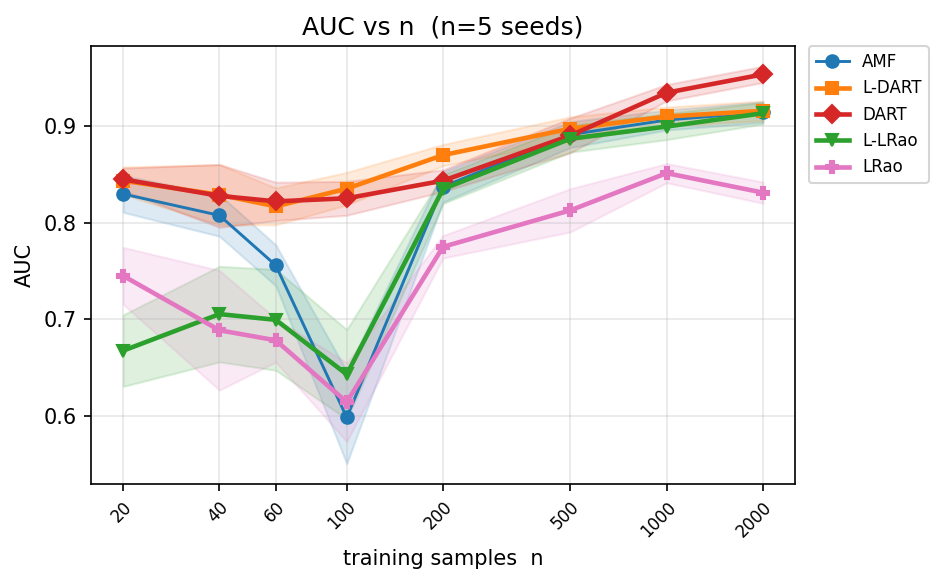

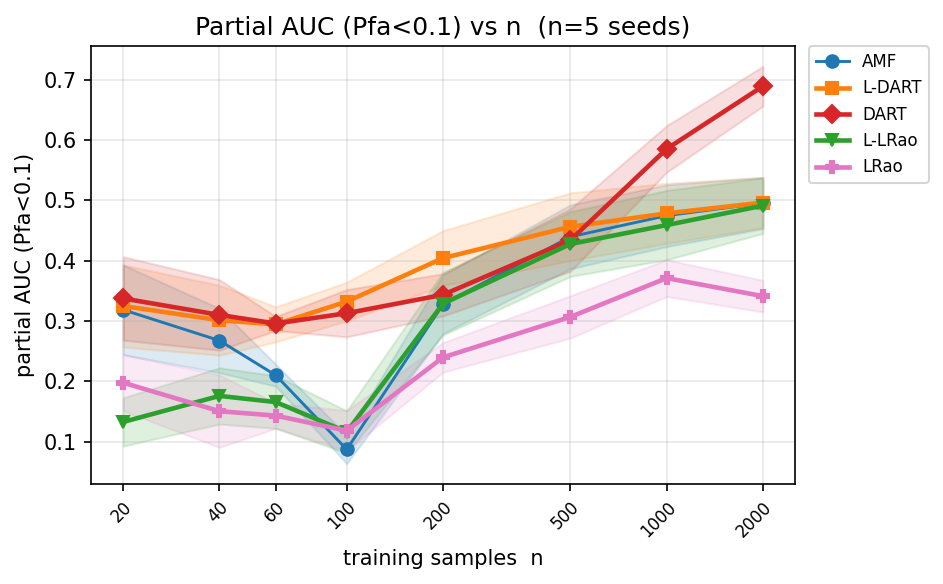

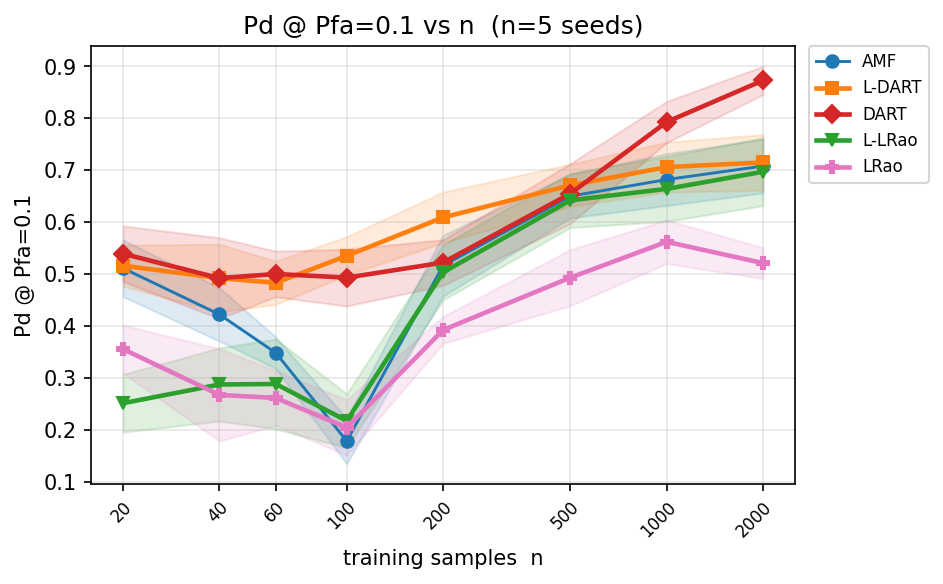

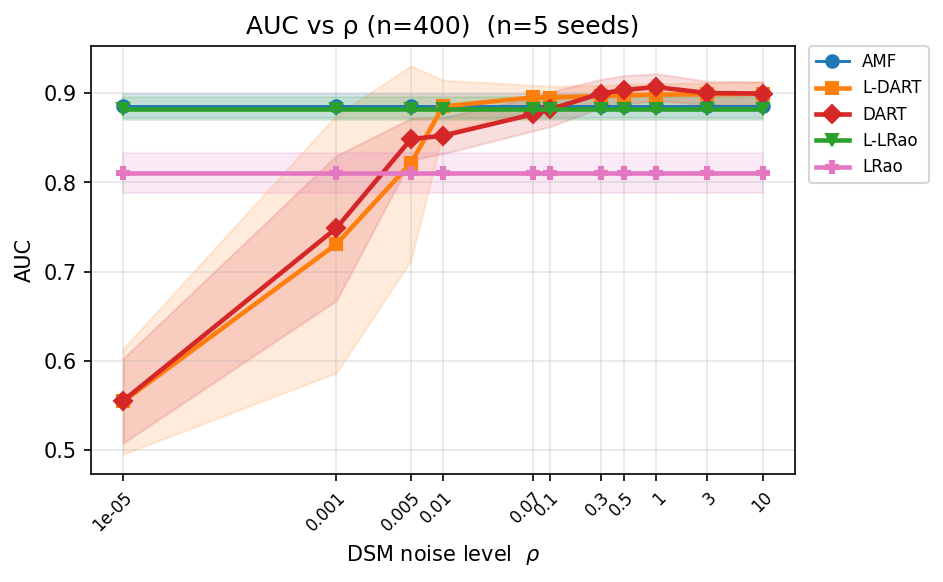

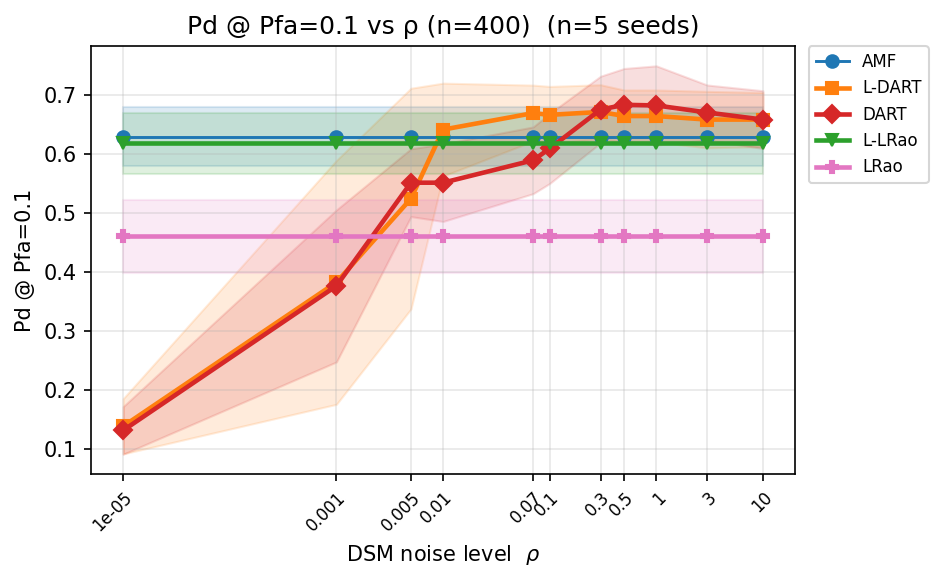

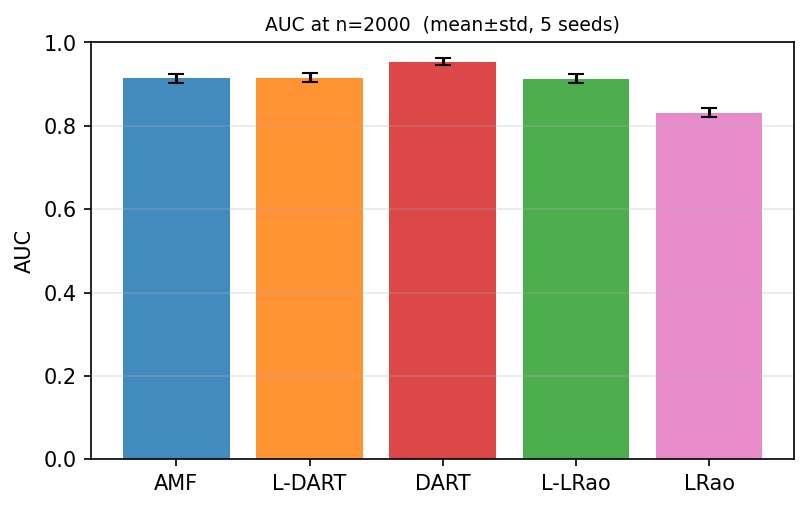

In [11]:
import src.iid as iid
cfg = yaml.safe_load(open('configs/iid_single.yaml')); cfg['device']=DEVICE
cfg.update(ALG_IID_SINGLE)
run_dir_single, _ = iid.run_iid(cfg, mode='single')
show_figs(run_dir_single)

## 2. IID — multi-class background (Fig. 3)


MULTI-SEED run  mode=multi  seeds=[42, 43, 44, 45, 46]


--- seed 42 ---
Run dir: results/iid_multi/iid_multi_agg_20260617_074218/seed_42/iid_multi_20260617_074218
device = cuda
n_train_list = [20, 40, 60, 100, 200, 500, 1000, 2000]
rho_list     = [1e-05, 0.001, 0.005, 0.01, 0.07, 0.1, 0.3, 0.5, 1.0, 3.0, 10.0]  (vs-ρ at n=1000)
Pfa=0.1  pAUC FPR<0.1  (ADDITIVE only)
Image 610x340x103  (RAW band space, no PCA)
  class  0: 164624 px
  class  1:   6631 px
  class  2:  18649 px
  class  3:   2099 px
  class  4:   3064 px
  class  5:   1345 px
  class  6:   5029 px
  class  7:   1330 px
  class  8:   3682 px
  class  9:    947 px
bkg pool:  18151 | tgt pool:   5029 | ||s_raw|| = 16257.2109
planted 200 targets in test (amp=0.15)


=== SWEEP vs n  (ρ=0.1) ===


LRao n20:   6%|▋         | 129/2000 [00:03<00:43, 43.16it/s, bad=2, skip=0, trJ=0.17, val=0.01]

      [early-stop] LRao n20 at epoch 131/2000 (no >0.5% val gain for 3 checks; best tr(J*)=0.013)


LRao mlp_n20:   6%|▋         | 128/2000 [00:03<00:40, 46.36it/s, bad=2, skip=0, trJ=0.17, val=0.01]

      [early-stop] LRao mlp_n20 at epoch 131/2000 (no >0.5% val gain for 3 checks; best tr(J*)=0.013)


...

  ρ=0.3     (22s)  DART=0.838  L-DART=0.819


  ρ=0.5     (22s)  DART=0.834  L-DART=0.819


  ρ=1.0     (23s)  DART=0.829  L-DART=0.817


  ρ=3.0     (22s)  DART=0.817  L-DART=0.817


  ρ=10.0    (22s)  DART=0.816  L-DART=0.816
  [fig] roc_at_nfixed.pdf

DONE in 7.7 min. Results -> results/iid_multi/iid_multi_agg_20260617_074218/seed_46/iid_multi_20260617_081230

MULTI-SEED DONE  37.9 min  →  results/iid_multi/iid_multi_agg_20260617_074218


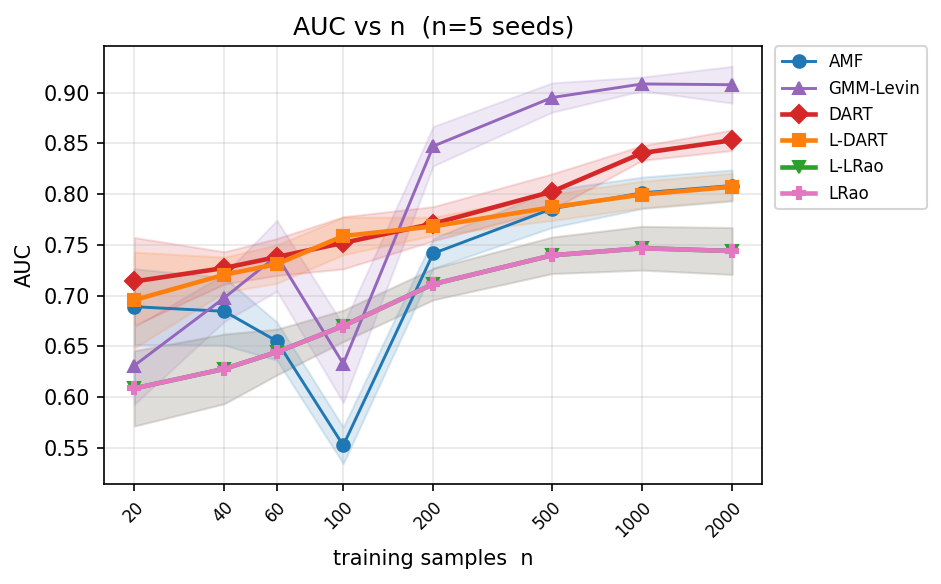

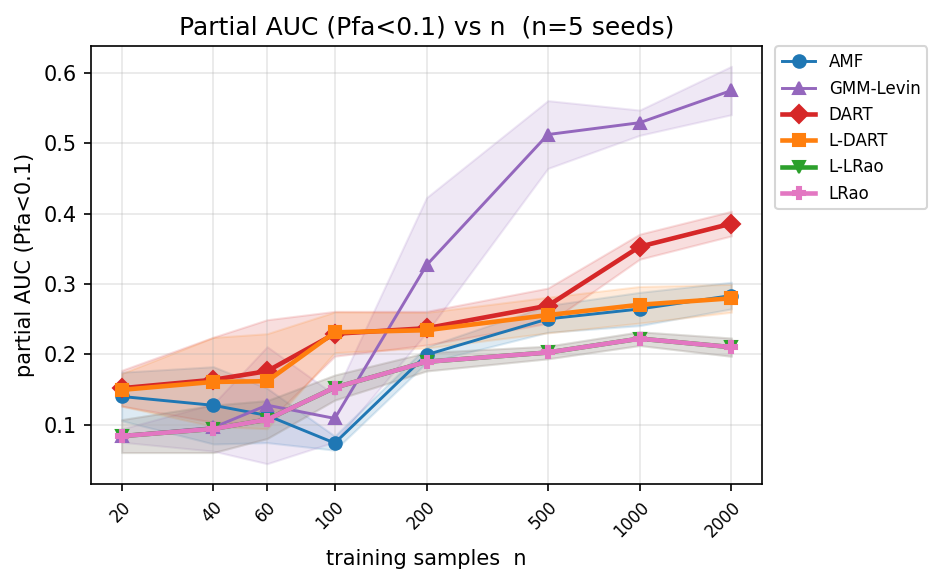

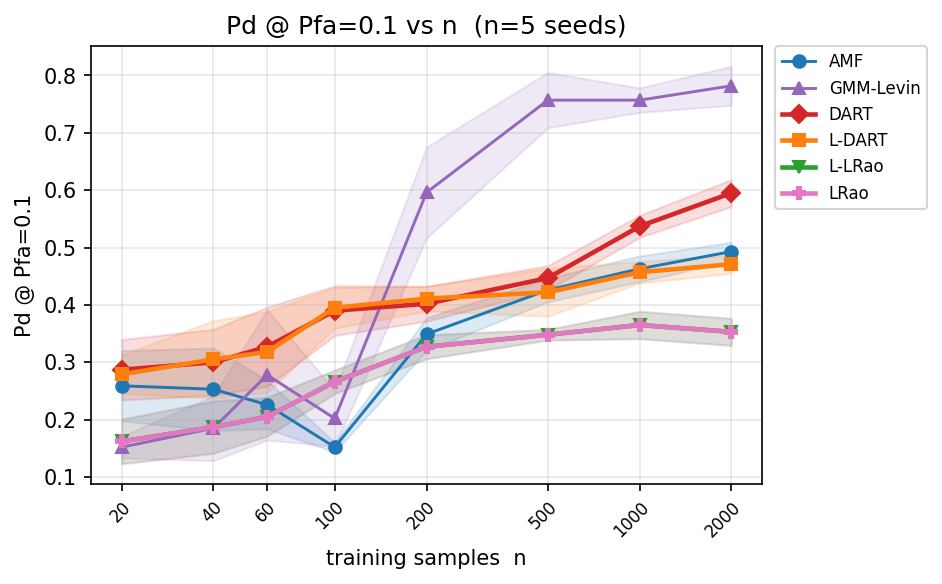

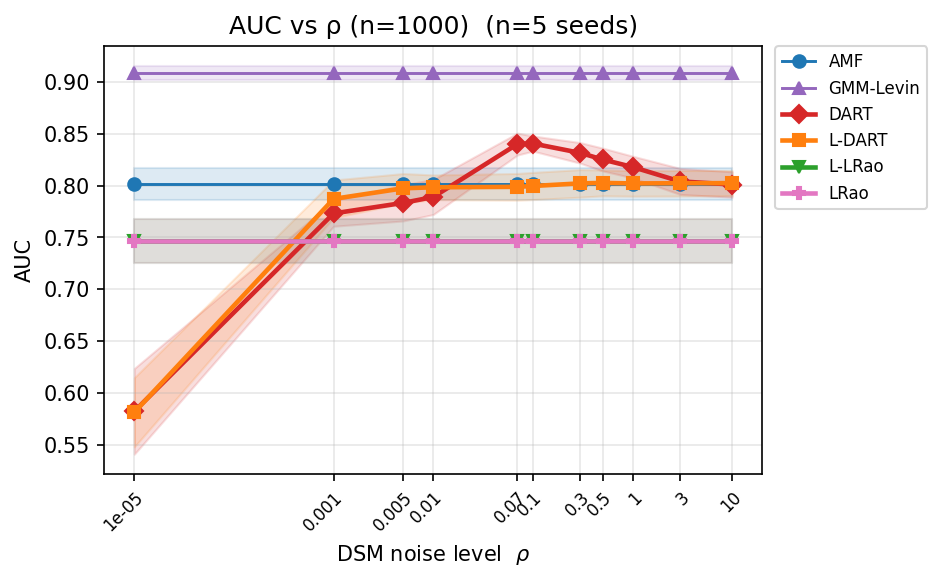

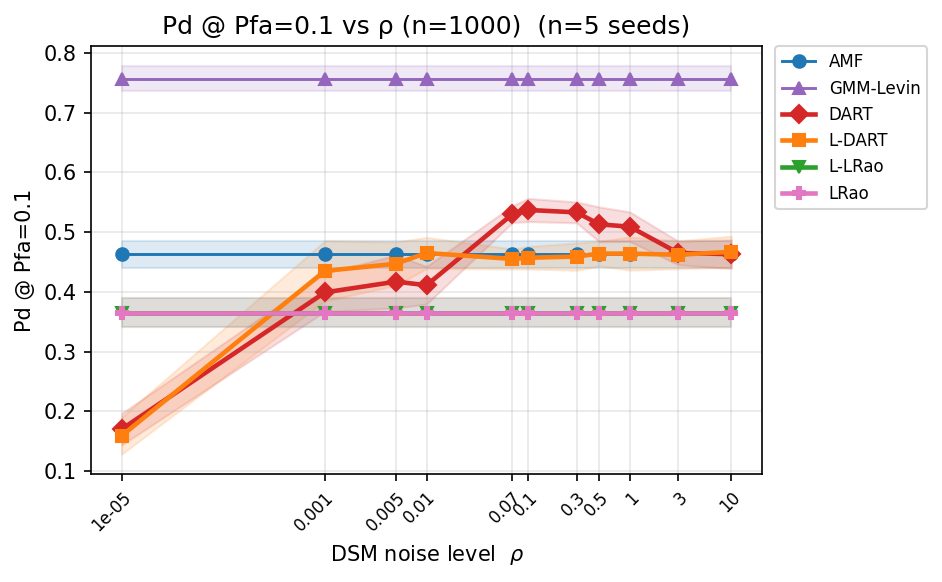

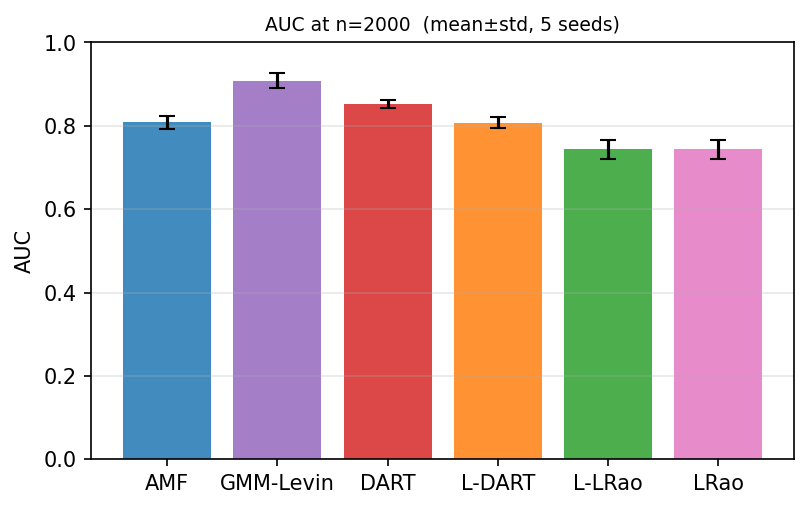

In [8]:
cfg = yaml.safe_load(open('configs/iid_multi.yaml')); cfg['device']=DEVICE
cfg.update(ALG_IID_MULTI)
run_dir_multi, _ = iid.run_iid(cfg, mode='multi')
show_figs(run_dir_multi)

## 3. Spatial — correlated background (Table 1)

Full paper run: trains the global DART and the spatially adapted DARTS on
disjoint train/test boxes (`n_budget` secondary pixels) for each of 5 seeds,
compares all detectors, and prints the **mean ± std** summary table — these are
the Table 1 numbers (CFAR shrinkage `cfar_lam = 0.1`).


########## MULTI-SEED  seeds=[42, 43, 44, 45, 46]  -> results/spatial/multiseed_20260617_082015

===== seed 42  (1/5) =====
Device: cuda
Loading data ...
Image 610×340×103
Scenario 4: train_box=[85, 193, 207, 306]  test_box=[419, 508, 250, 334]
train=4026 px  (box [106, 172, 226, 287])
test=7476 px  (89×84)
AMF window=15×15 (independent of k=7)
in-patch signature: dominant=asphalt  ||s||=1.373e+04
foreign signature: class=bitumen  scaled ||s||=1.436e+04
Training DSM ...


DART:   0%|          | 0/1000 [00:00<?, ?it/s, loss=1031.3433]

    [DSM] epoch 1/1000  loss=1031.3433  best=1031.3433


DART:  10%|▉         | 98/1000 [00:02<00:24, 36.97it/s, loss=807.3580]

    [DSM] epoch 100/1000  loss=807.3580  best=806.2043


...

    [NeighborMLP] epoch 900/1000  loss=788.1914  best=783.5277


DARTS: 100%|█████████▉| 996/1000 [00:29<00:00, 36.54it/s, loss=790.8054]

    [NeighborMLP] epoch 1000/1000  loss=790.8054  best=783.5277


  NeighborMLP done (30s)  best loss=783.5277
  saved models -> results/spatial/multiseed_20260617_082015/seeds/compare_20260617_082611/models.pt

########## DETECTION RUN: foreign-bitumen ##########


[foreign-bitumen] planted 647 targets  ||s||=1.436e+04
Scoring detectors (test) ...
Scoring detectors (train, for CFAR thresholds) ...
Active detectors: ['DART', 'DART-CFAR', 'DARTS', 'DARTS-CFAR', 'AMF', 'GMM-Levin']

=== Summary [foreign-bitumen] ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[asphalt] | Pfa[trees] |
|---|---|---|---|---|---|---|---|---|---|
| DART | 0.161 | 0.796 | 0.275 | 0.287 | 0.131 | 0.247 | 0.044 | 0.104 | 0.247 |
| DART-CFAR | 0.327 | 0.882 | 0.474 | 0.331 | 0.033 | 0.039 | 0.021 | 0.039 | 0.039 |
| DARTS | 0.337 | 0.907 | 0.564 | 0.631 | 0.117 | 0.240 | 0.061 | 0.050 | 0.240 |
| DARTS-CFAR | 0.466 | 0.928 | 0.677 | 0.450 | 0.029 | 0.039 | 0.020 | 0.029 | 0.039 |
| AMF | 0.326 | 0.845 | 0.459 | 0.447 | 0.043 | 0.046 | 0.046 | 0.043 | 0.039 |
| GMM-Levin | 0.156 | 0.803 | 0.323 | 0.406 | 0.134 | 0.195 | 0.058 | 0.150 | 0.195 |

Saving figures ...
  [fig] results/spatial/multiseed_20260617_082015/seeds/compare

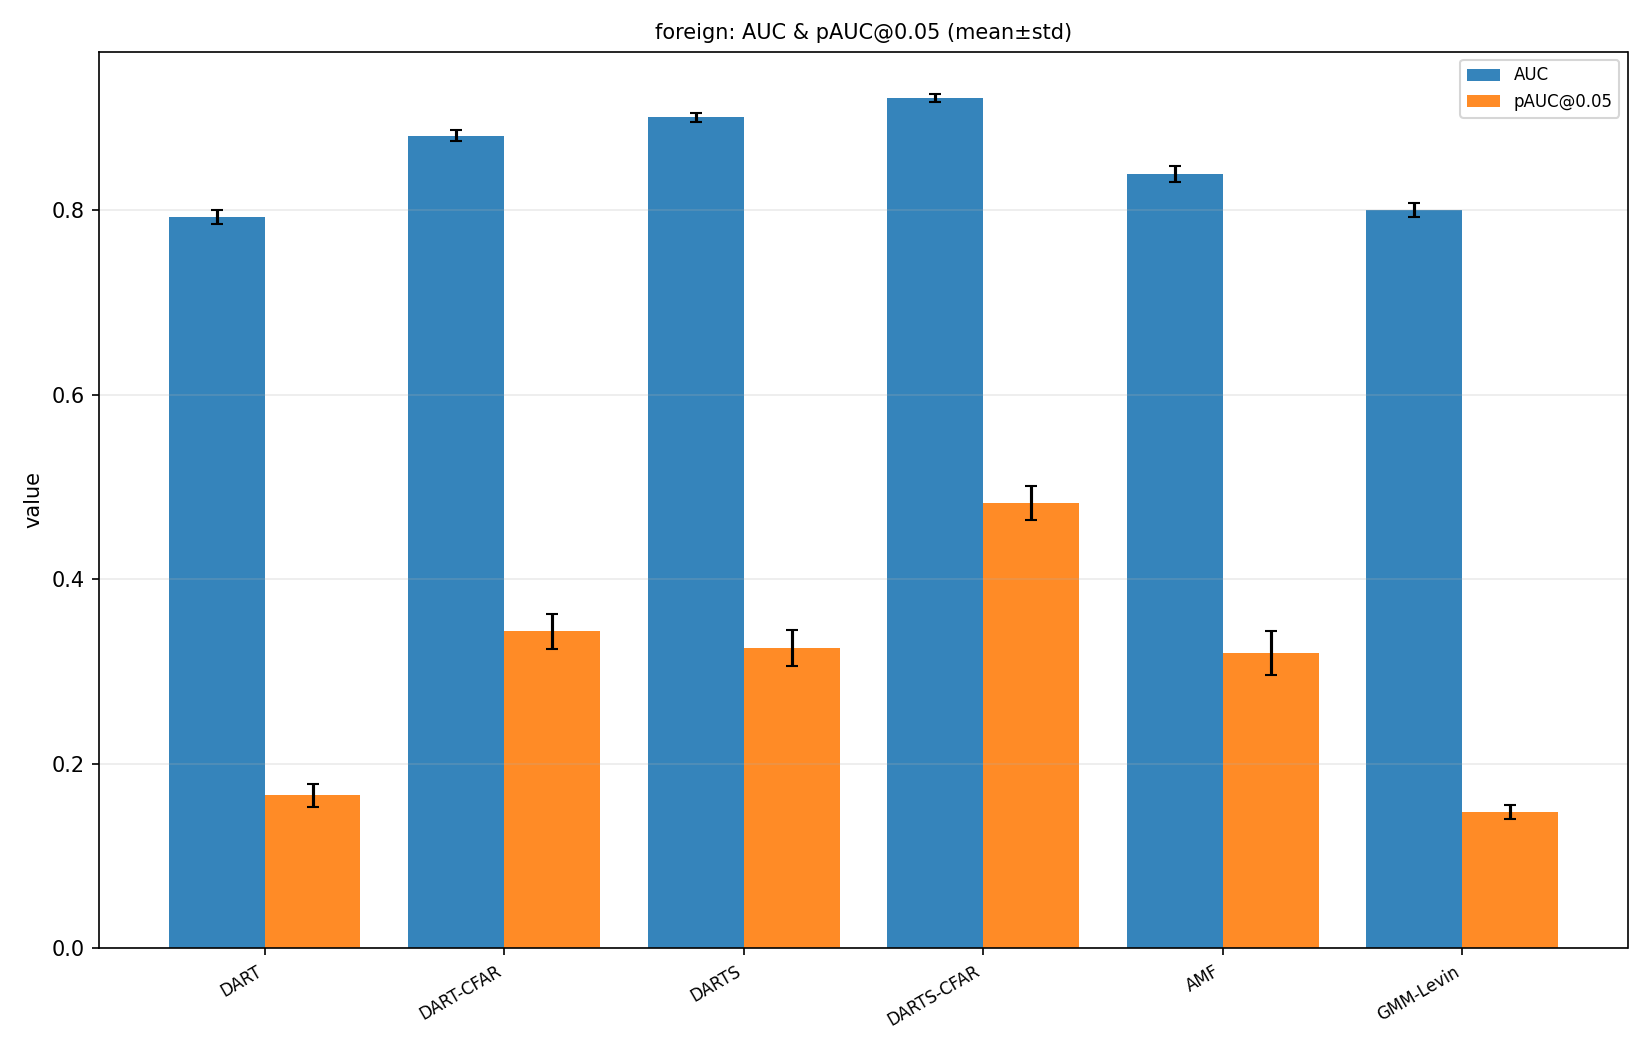

── foreign_pd_bar.png ──


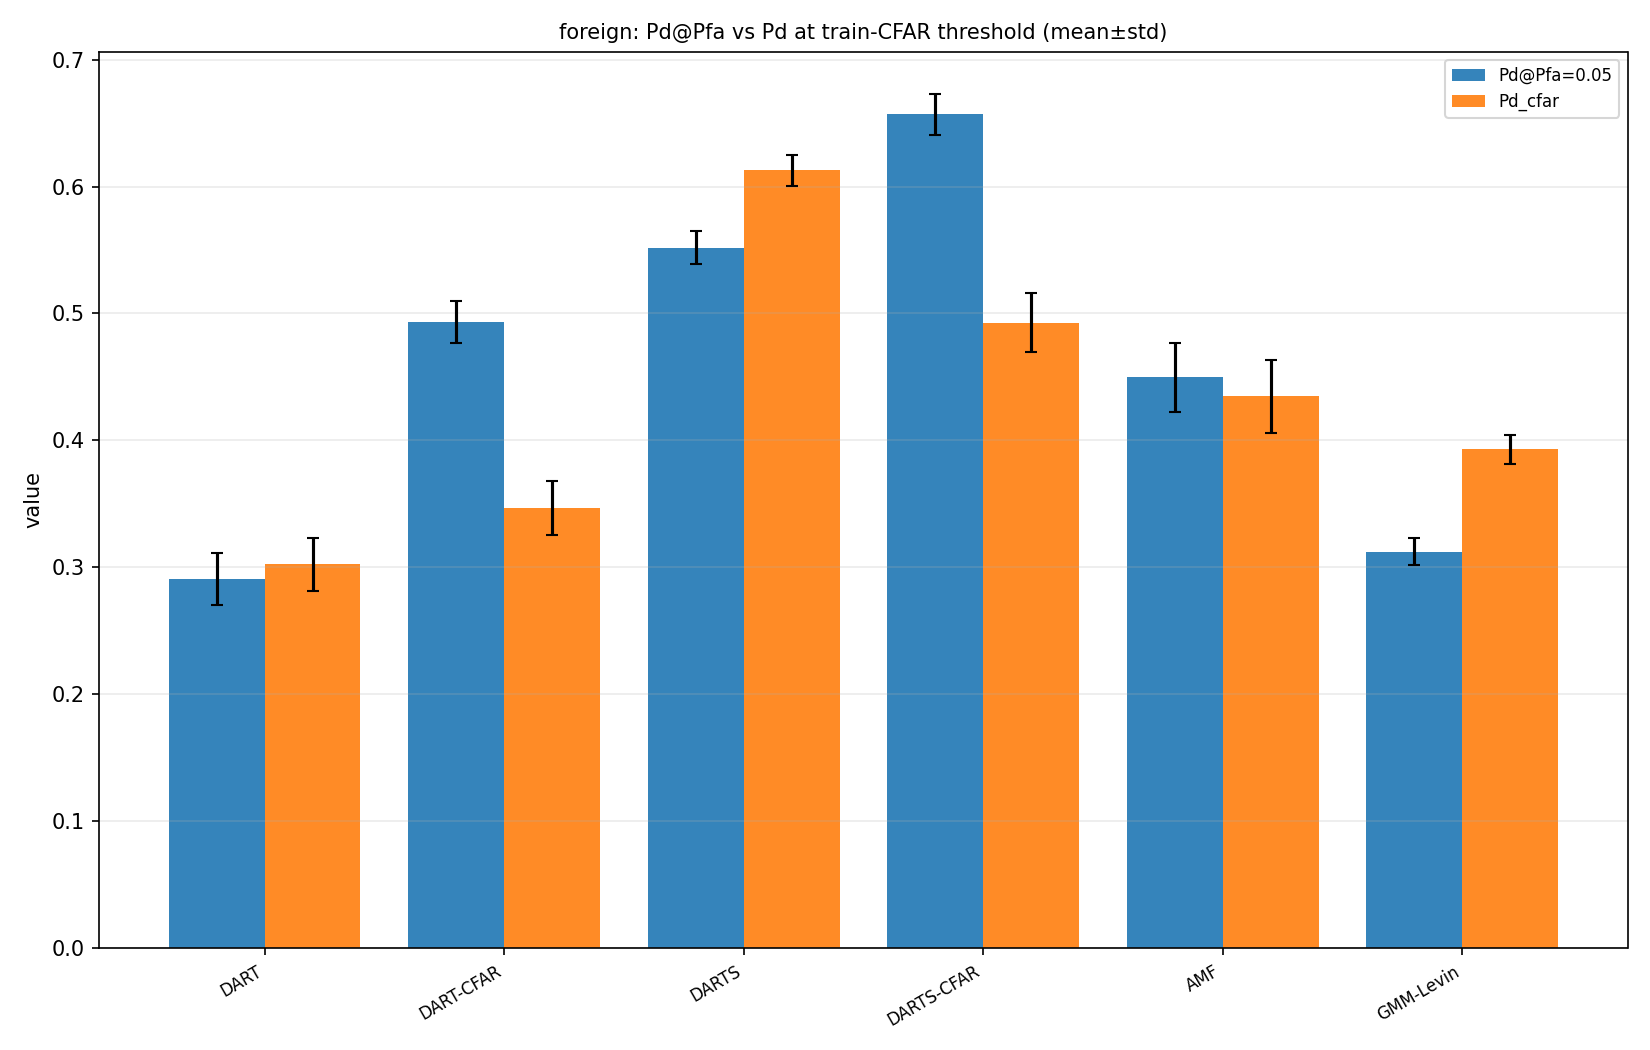

── foreign_pfa_bar.png ──


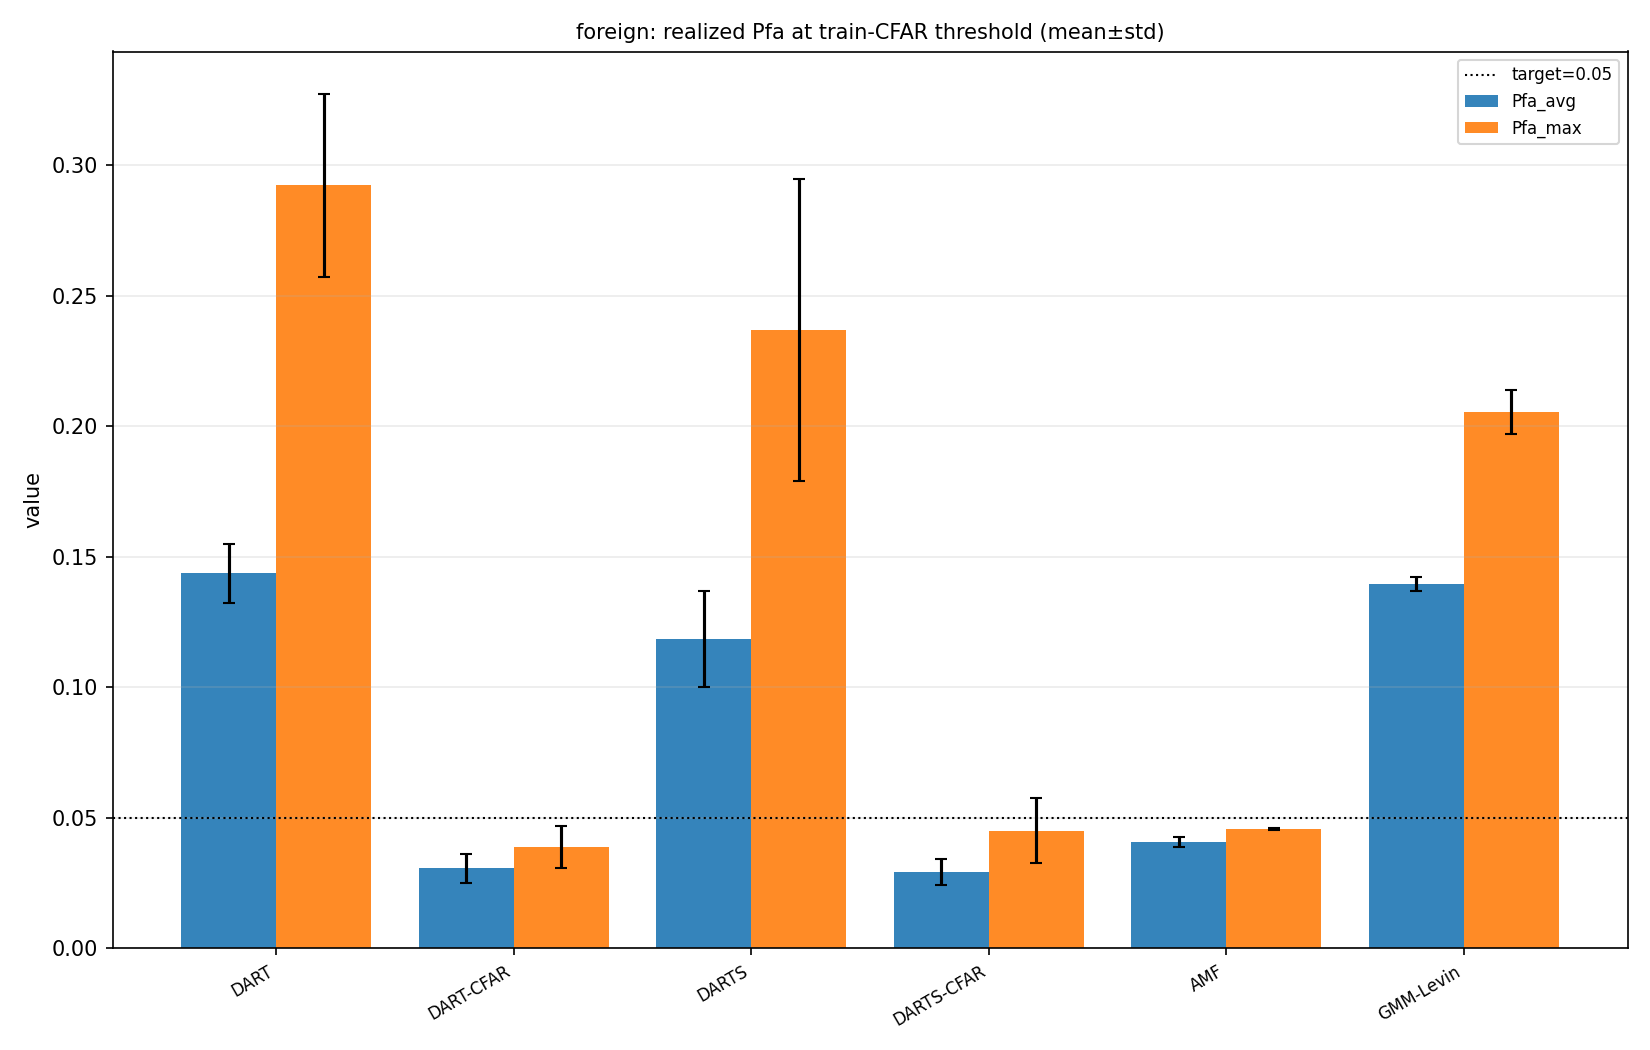


=== Representative qualitative figures (seed 42) ===
── false_color.png ──


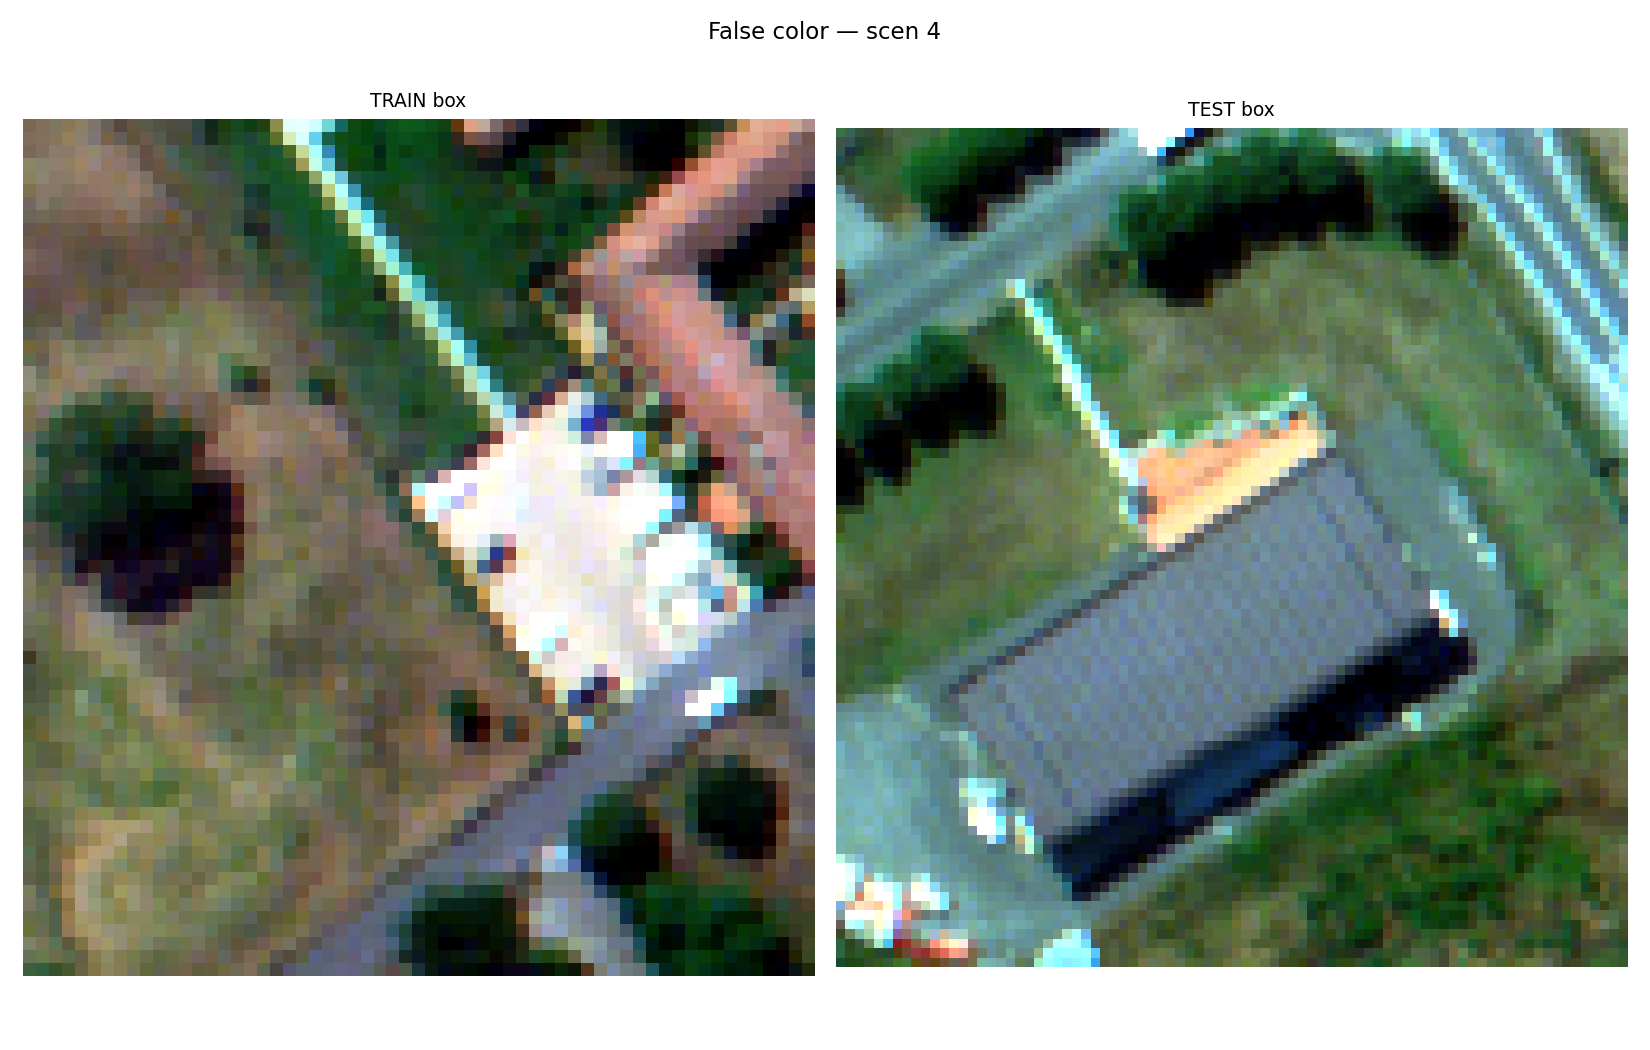

── label_map_targets.png ──


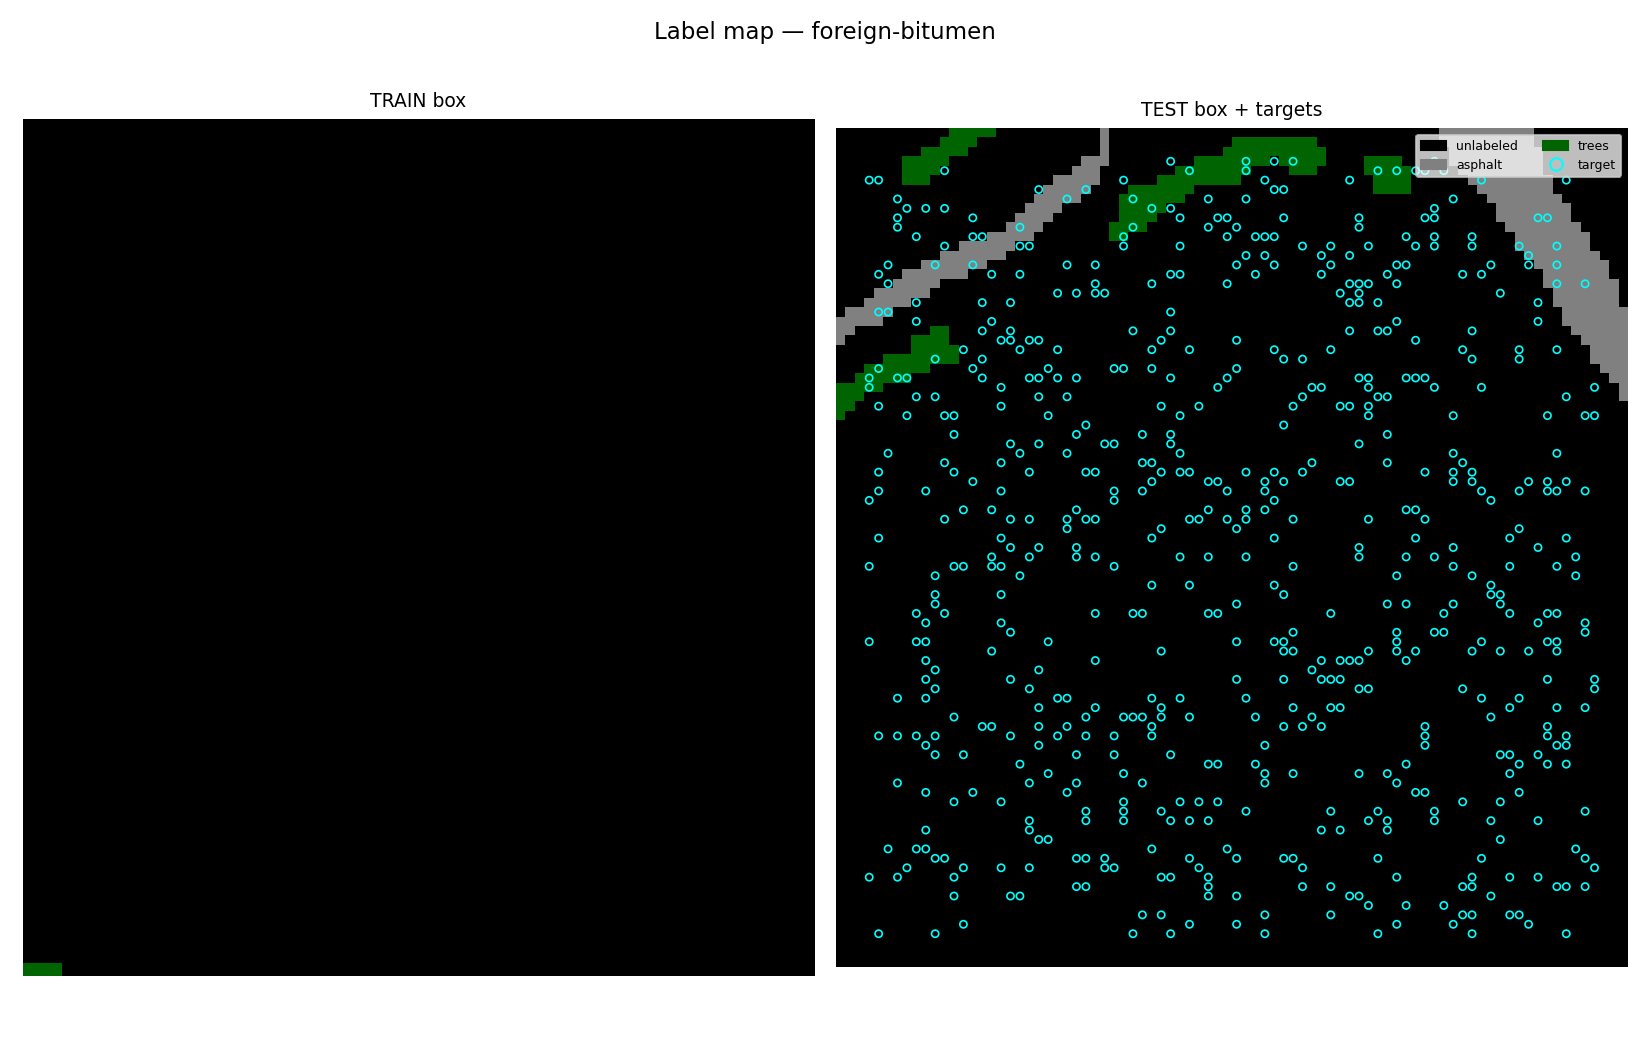

── signatures.png ──


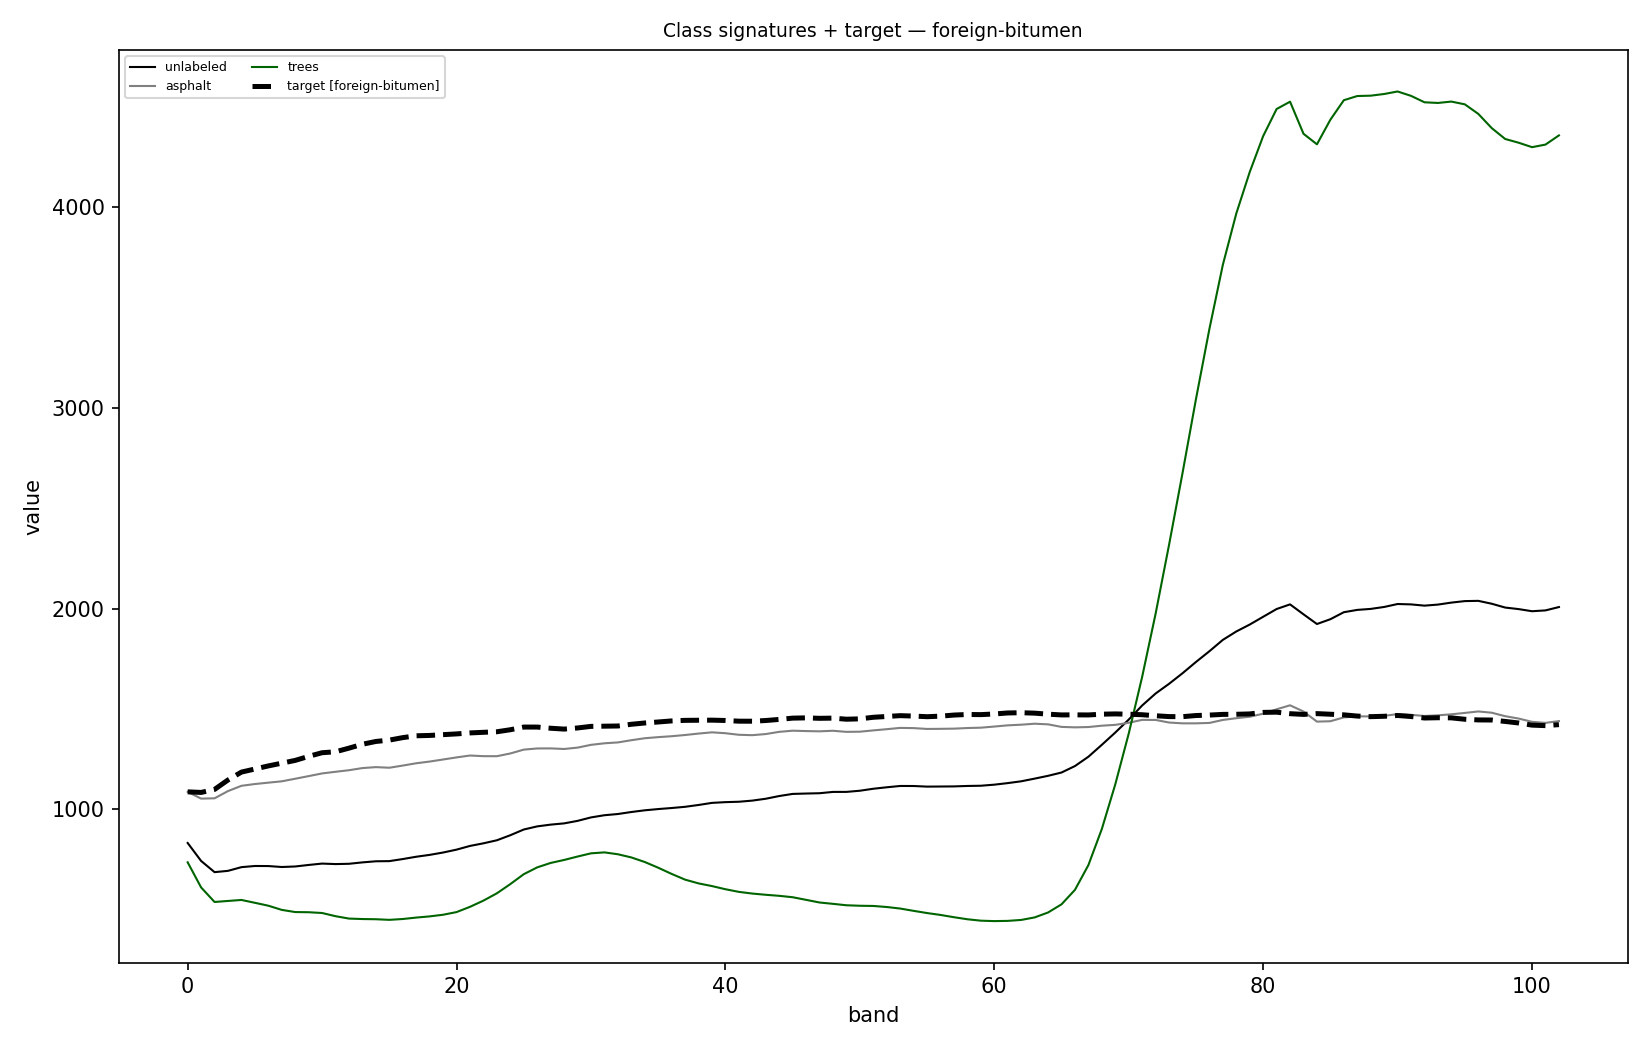

── detection_maps.png ──


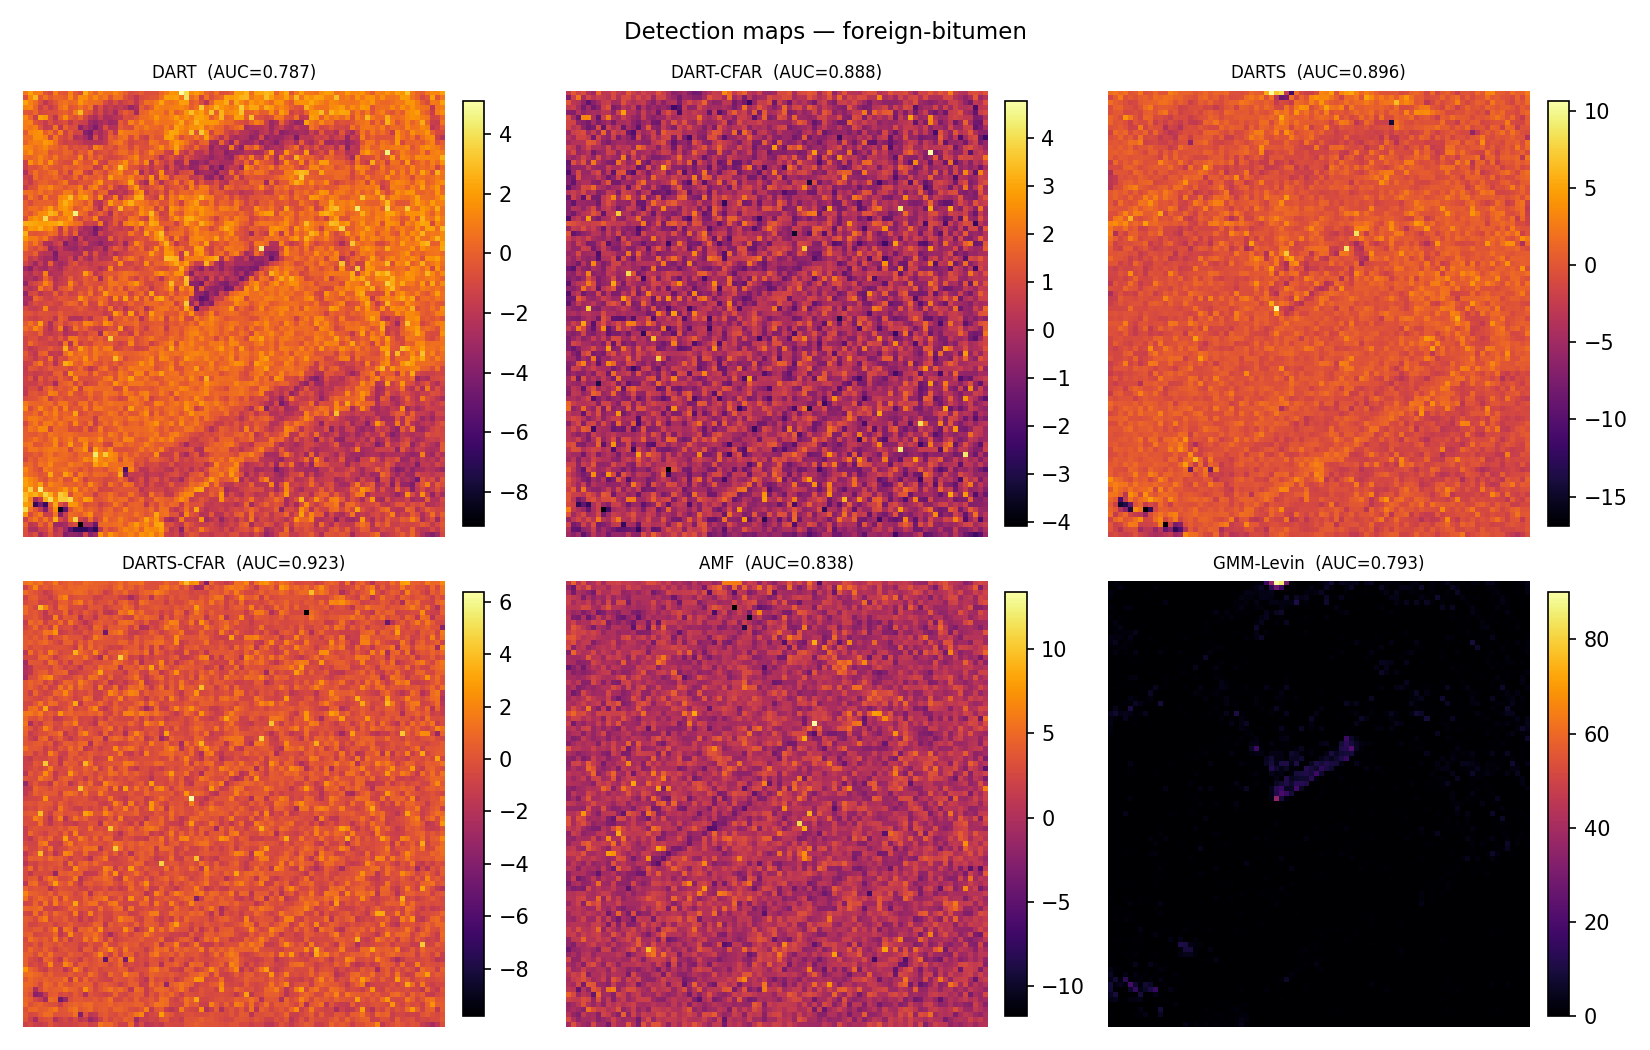

── detected_pfa.png ──


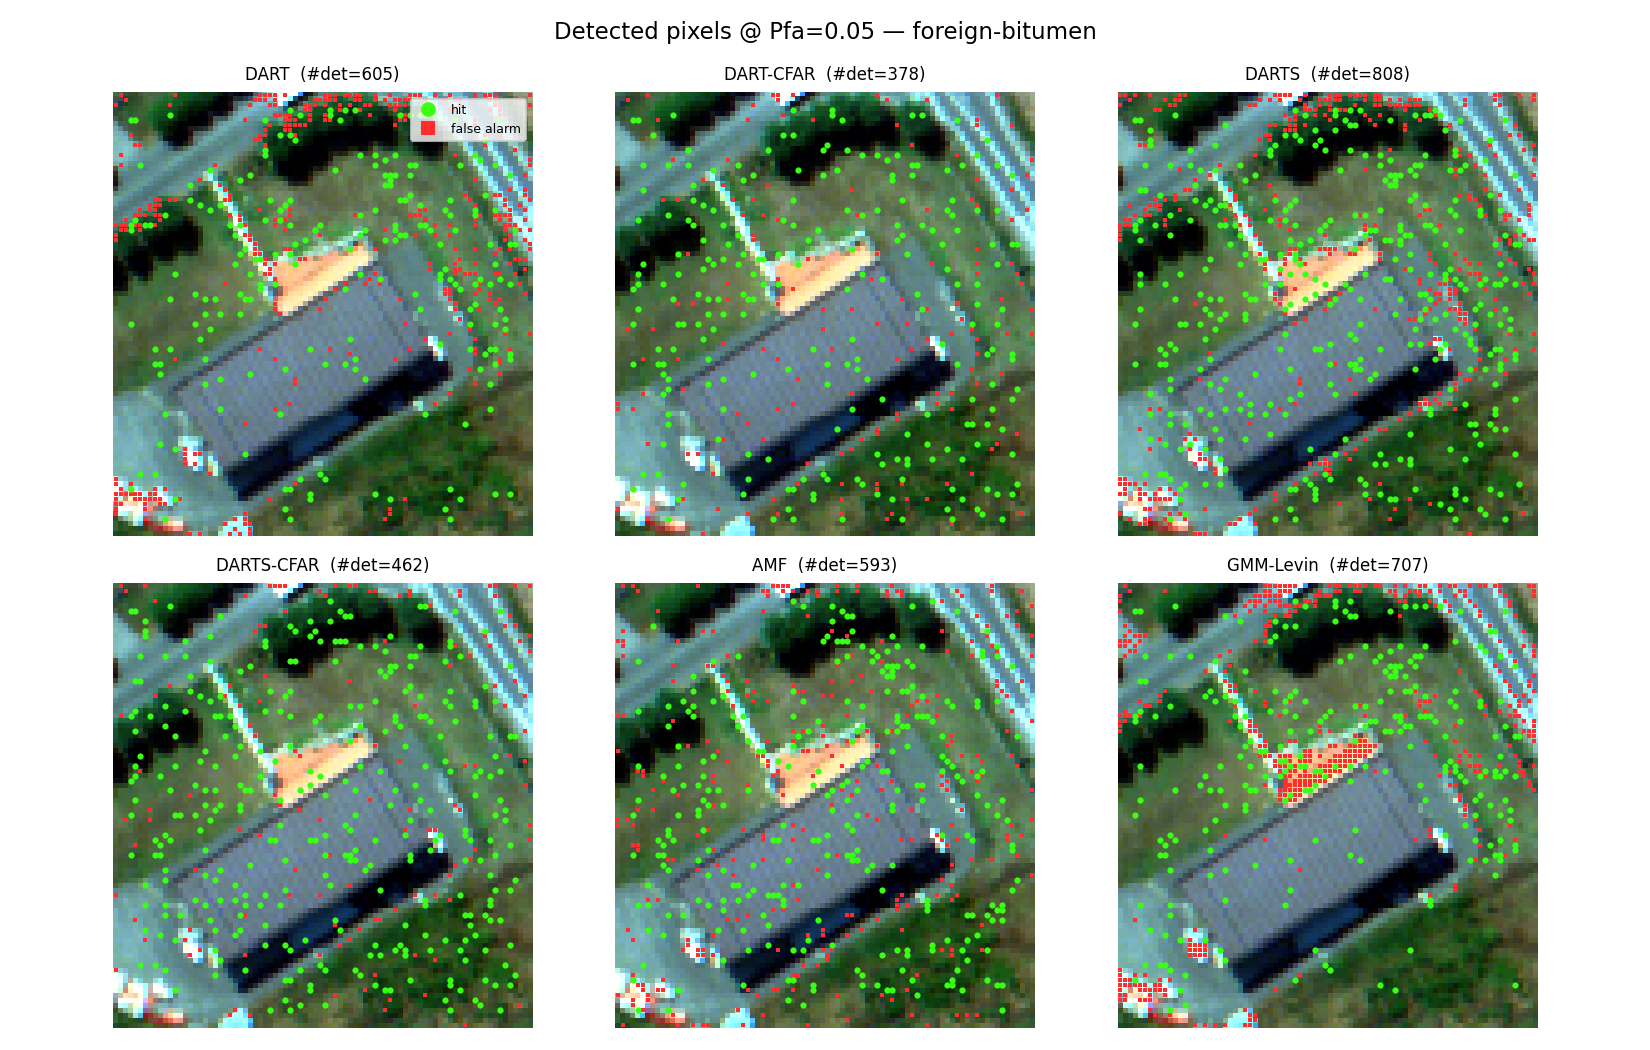

── roc.png ──


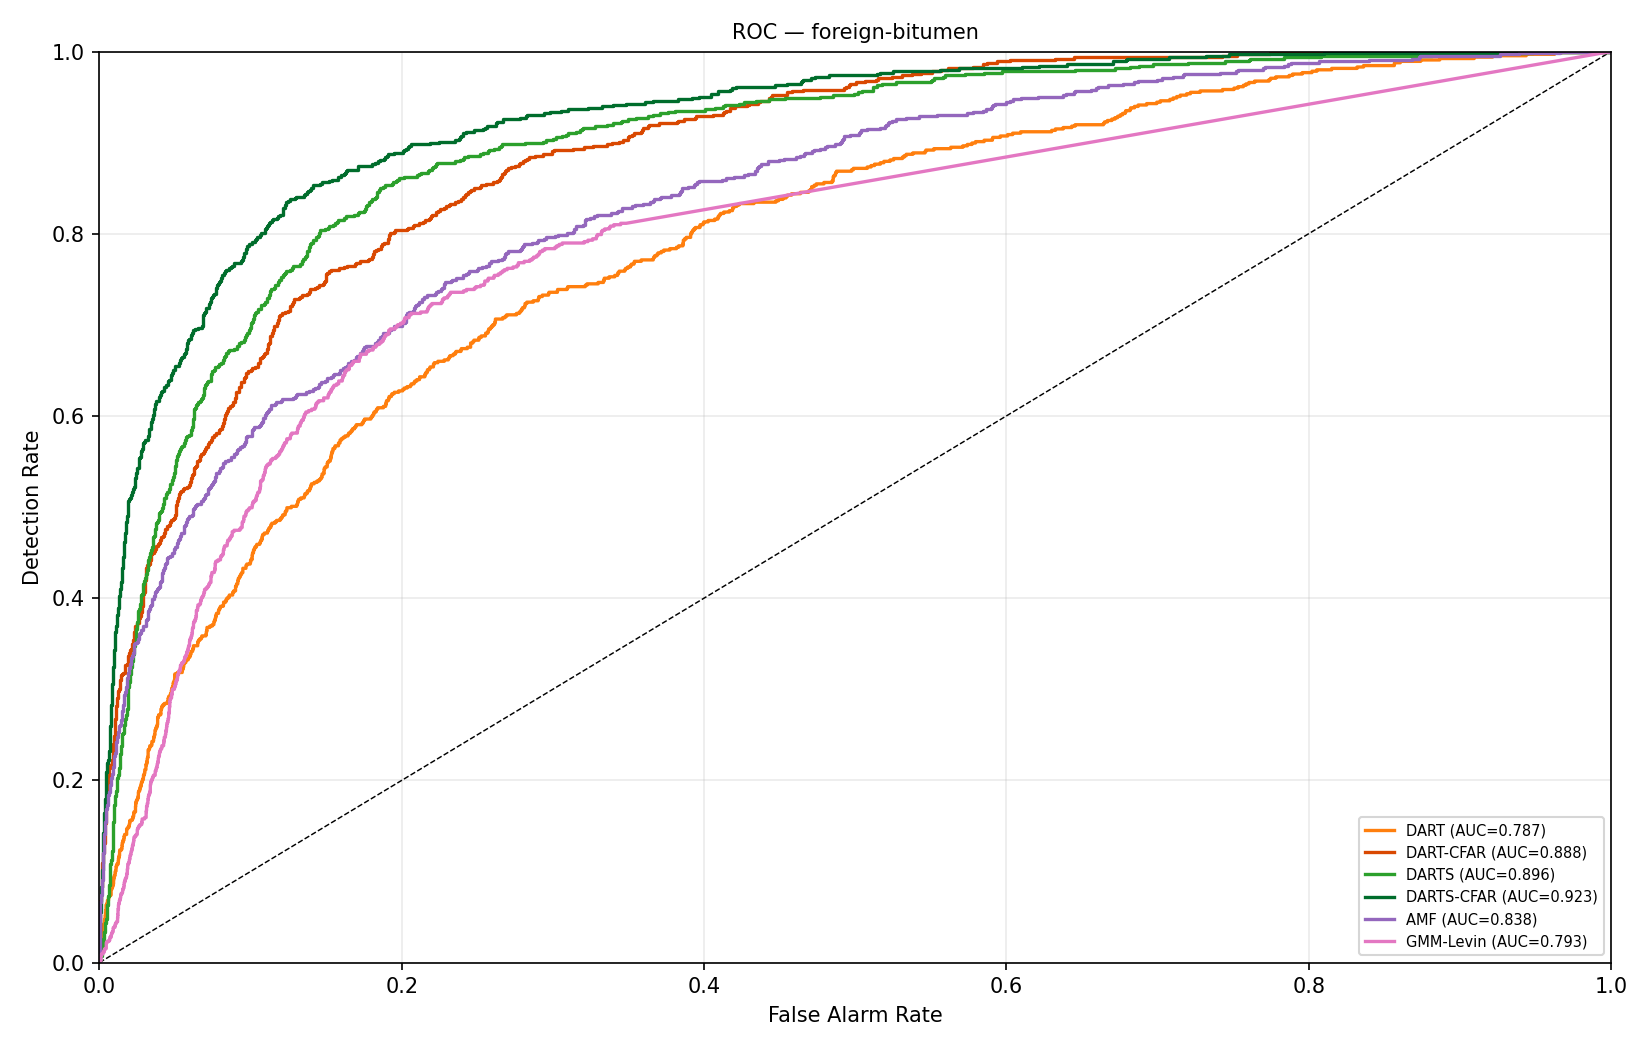

── pfa_per_class.png ──


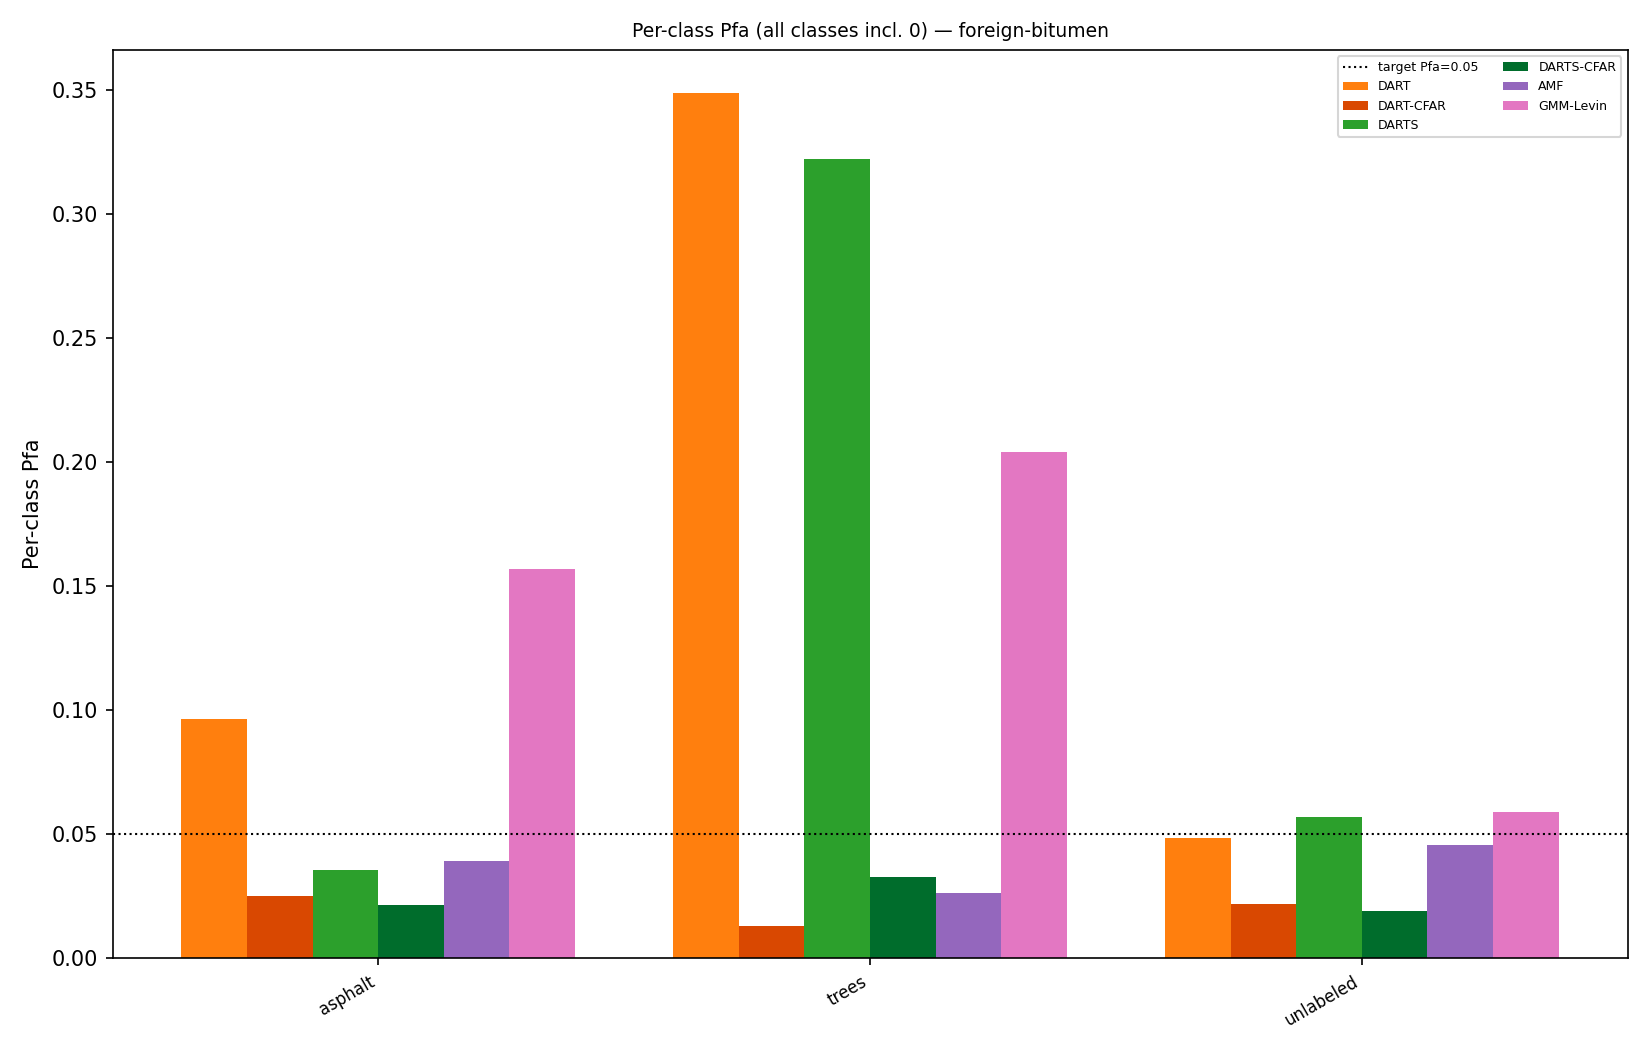

── false_alarms_falsecolor.png ──


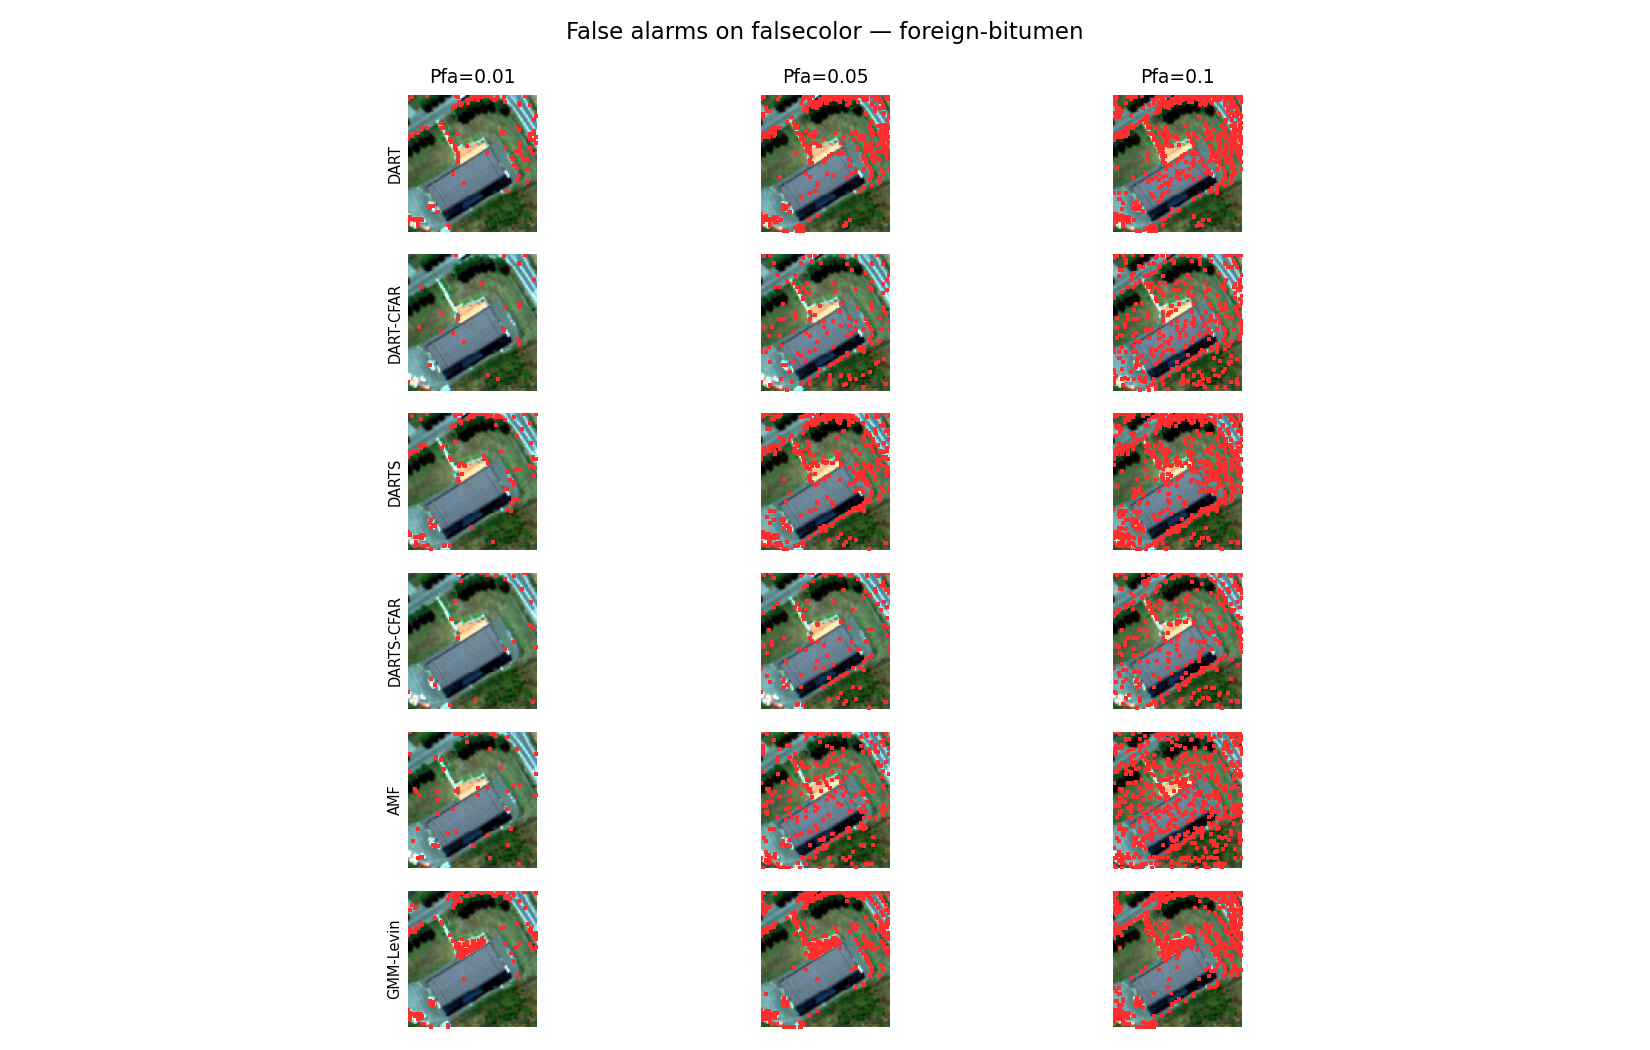

── false_alarms_labelmap.png ──


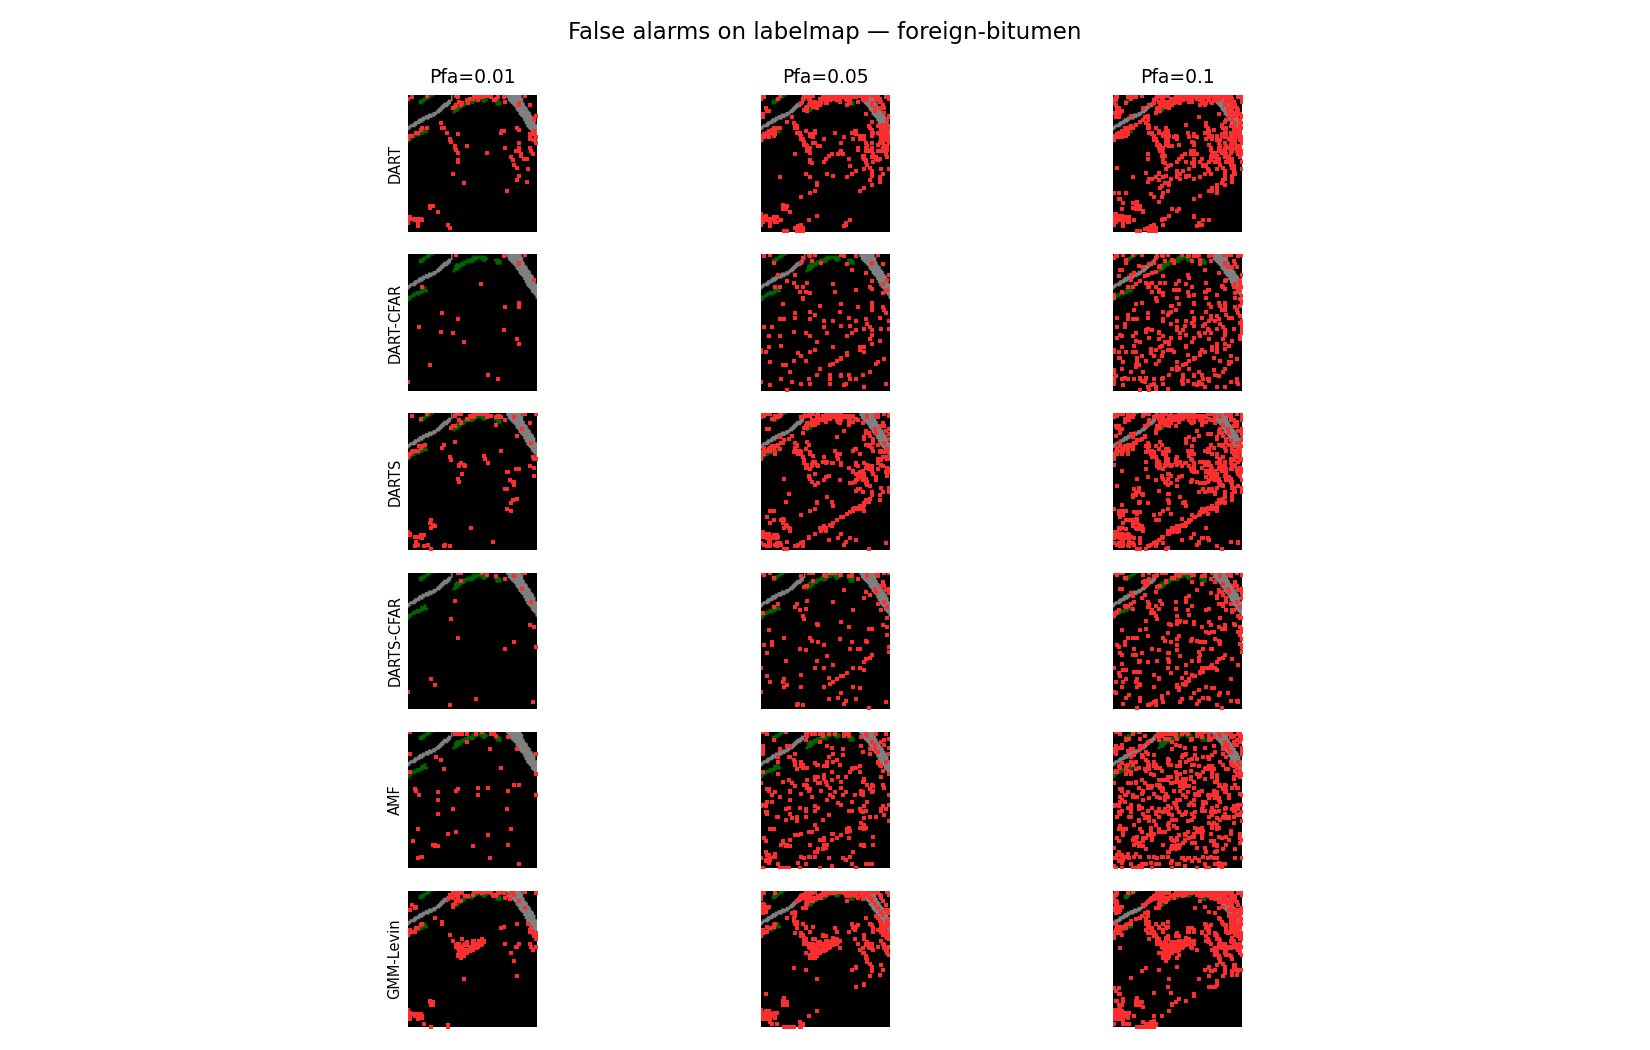


=== Summary Table ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[asphalt] | Pfa[trees] |
|---|---|---|---|---|---|---|---|---|---|
| DART | 0.179 | 0.787 | 0.317 | 0.331 | 0.165 | 0.349 | 0.049 | 0.096 | 0.349 |
| DART-CFAR | 0.354 | 0.888 | 0.491 | 0.352 | 0.020 | 0.025 | 0.022 | 0.025 | 0.013 |
| DARTS | 0.329 | 0.896 | 0.541 | 0.594 | 0.138 | 0.322 | 0.057 | 0.036 | 0.322 |
| DARTS-CFAR | 0.480 | 0.923 | 0.655 | 0.507 | 0.025 | 0.033 | 0.019 | 0.021 | 0.033 |
| AMF | 0.323 | 0.838 | 0.456 | 0.442 | 0.037 | 0.046 | 0.046 | 0.039 | 0.026 |
| GMM-Levin | 0.140 | 0.793 | 0.303 | 0.393 | 0.140 | 0.204 | 0.059 | 0.157 | 0.204 |

spatial results -> results/spatial/multiseed_20260617_082015


In [9]:
import src.spatial as spatial
cfg = yaml.safe_load(open('configs/spatial.yaml')); cfg['device']=DEVICE
cfg.update(ALG_SPATIAL)
parent = spatial.run_multiseed(cfg, seeds=(42,43,44,45,46))
spatial.show_multiseed(parent, inline=True)
print('spatial results ->', parent)

## CFAR-λ ablation (Table 1, lower block)

Re-runs the 5-seed spatial experiment at the two paper CFAR shrinkage values
`cfar_lam ∈ {0.1, 0.9}` and prints each mean ± std table (training is repeated
per λ). `0.1` reproduces the headline rows above; `0.9` is the shrinkage point.


########## MULTI-SEED  seeds=[42, 43, 44, 45, 46]  -> results/spatial/multiseed_20260617_082742

===== seed 42  (1/5) =====
Device: cuda
Loading data ...
Image 610×340×103
Scenario 4: train_box=[85, 193, 207, 306]  test_box=[419, 508, 250, 334]
train=4026 px  (box [106, 172, 226, 287])
test=7476 px  (89×84)
AMF window=15×15 (independent of k=7)
in-patch signature: dominant=asphalt  ||s||=1.373e+04
foreign signature: class=bitumen  scaled ||s||=1.436e+04
Training DSM ...


DART:   0%|          | 0/1000 [00:00<?, ?it/s, loss=1031.3433]

    [DSM] epoch 1/1000  loss=1031.3433  best=1031.3433


DART:  10%|▉         | 96/1000 [00:02<00:27, 32.86it/s, loss=807.3580]

    [DSM] epoch 100/1000  loss=807.3580  best=806.2043


...

    [NeighborMLP] epoch 900/1000  loss=788.1914  best=783.5277


DARTS: 100%|█████████▉| 998/1000 [00:29<00:00, 34.60it/s, loss=790.8054]

    [NeighborMLP] epoch 1000/1000  loss=790.8054  best=783.5277


  NeighborMLP done (29s)  best loss=783.5277
  saved models -> results/spatial/multiseed_20260617_082742/seeds/compare_20260617_083337/models.pt

########## DETECTION RUN: foreign-bitumen ##########
[foreign-bitumen] planted 647 targets  ||s||=1.436e+04
Scoring detectors (test) ...


Scoring detectors (train, for CFAR thresholds) ...
Active detectors: ['DART', 'DART-CFAR', 'DARTS', 'DARTS-CFAR', 'AMF', 'GMM-Levin']

=== Summary [foreign-bitumen] ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[asphalt] | Pfa[trees] |
|---|---|---|---|---|---|---|---|---|---|
| DART | 0.161 | 0.796 | 0.275 | 0.287 | 0.131 | 0.247 | 0.044 | 0.104 | 0.247 |
| DART-CFAR | 0.327 | 0.882 | 0.474 | 0.331 | 0.033 | 0.039 | 0.021 | 0.039 | 0.039 |
| DARTS | 0.337 | 0.907 | 0.564 | 0.631 | 0.117 | 0.240 | 0.061 | 0.050 | 0.240 |
| DARTS-CFAR | 0.466 | 0.928 | 0.677 | 0.450 | 0.029 | 0.039 | 0.020 | 0.029 | 0.039 |
| AMF | 0.326 | 0.845 | 0.459 | 0.447 | 0.043 | 0.046 | 0.046 | 0.043 | 0.039 |
| GMM-Levin | 0.156 | 0.803 | 0.323 | 0.406 | 0.134 | 0.195 | 0.058 | 0.150 | 0.195 |

Saving figures ...
  [fig] results/spatial/multiseed_20260617_082742/seeds/compare_20260617_083337/foreign/false_color.pdf
  [fig] results/spatial/multiseed_20260617_

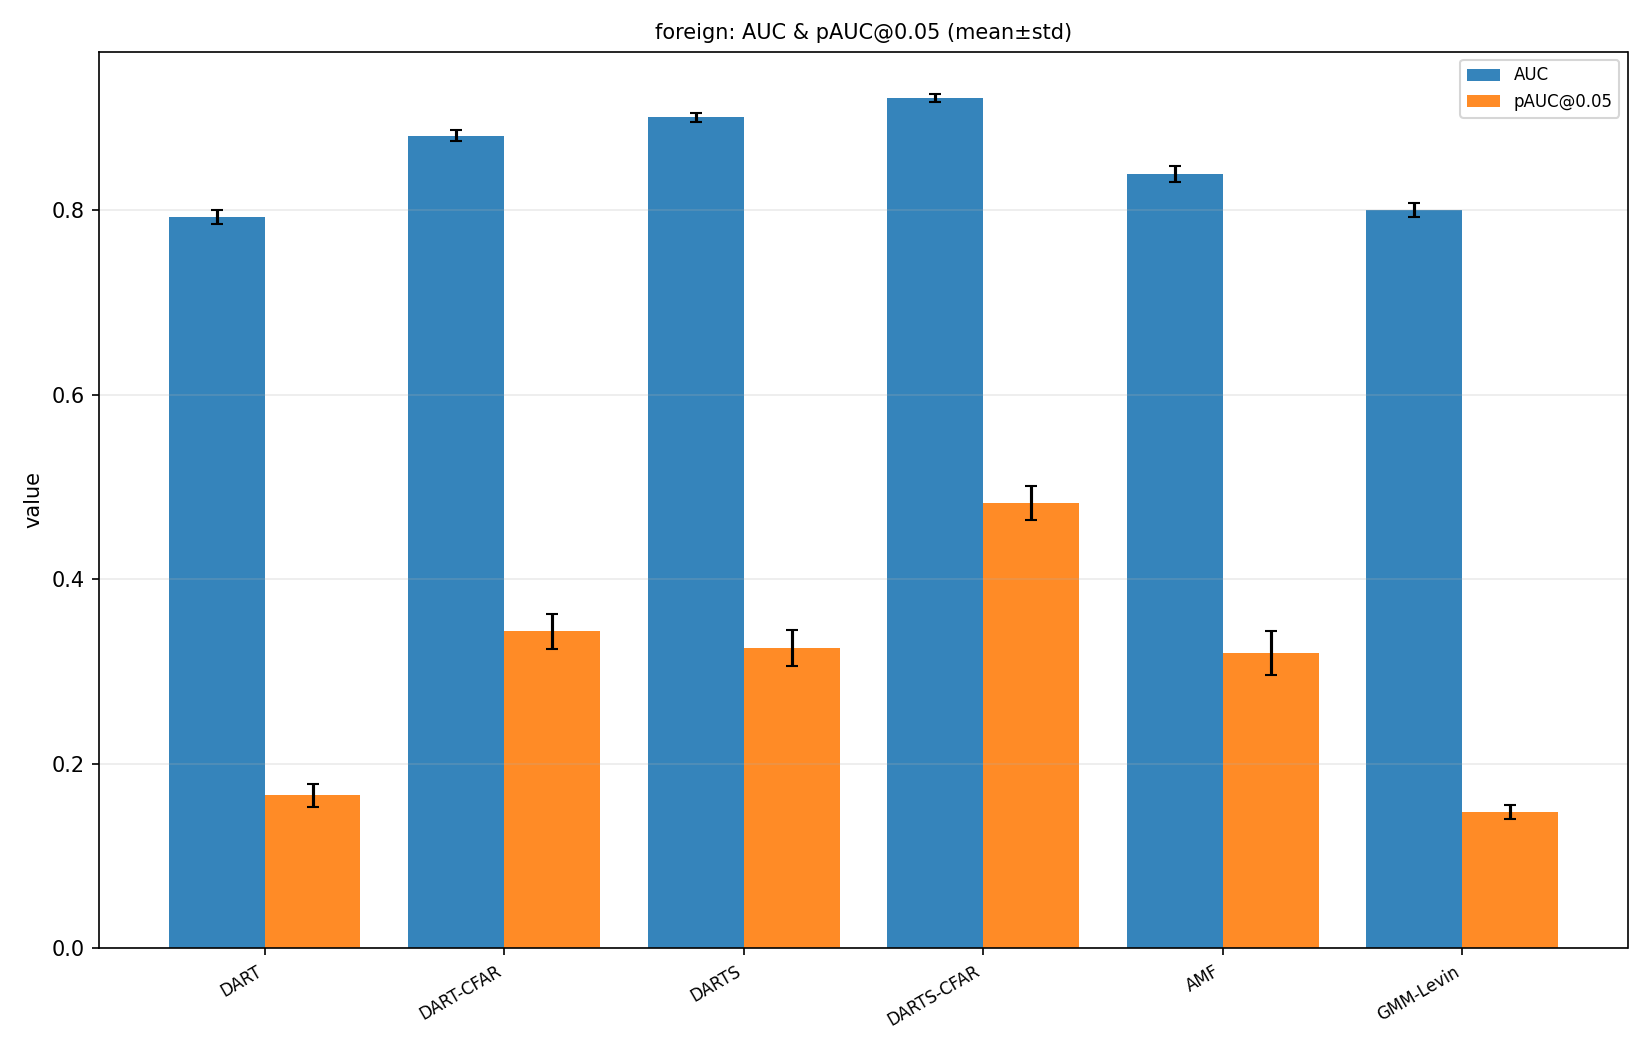

── foreign_pd_bar.png ──


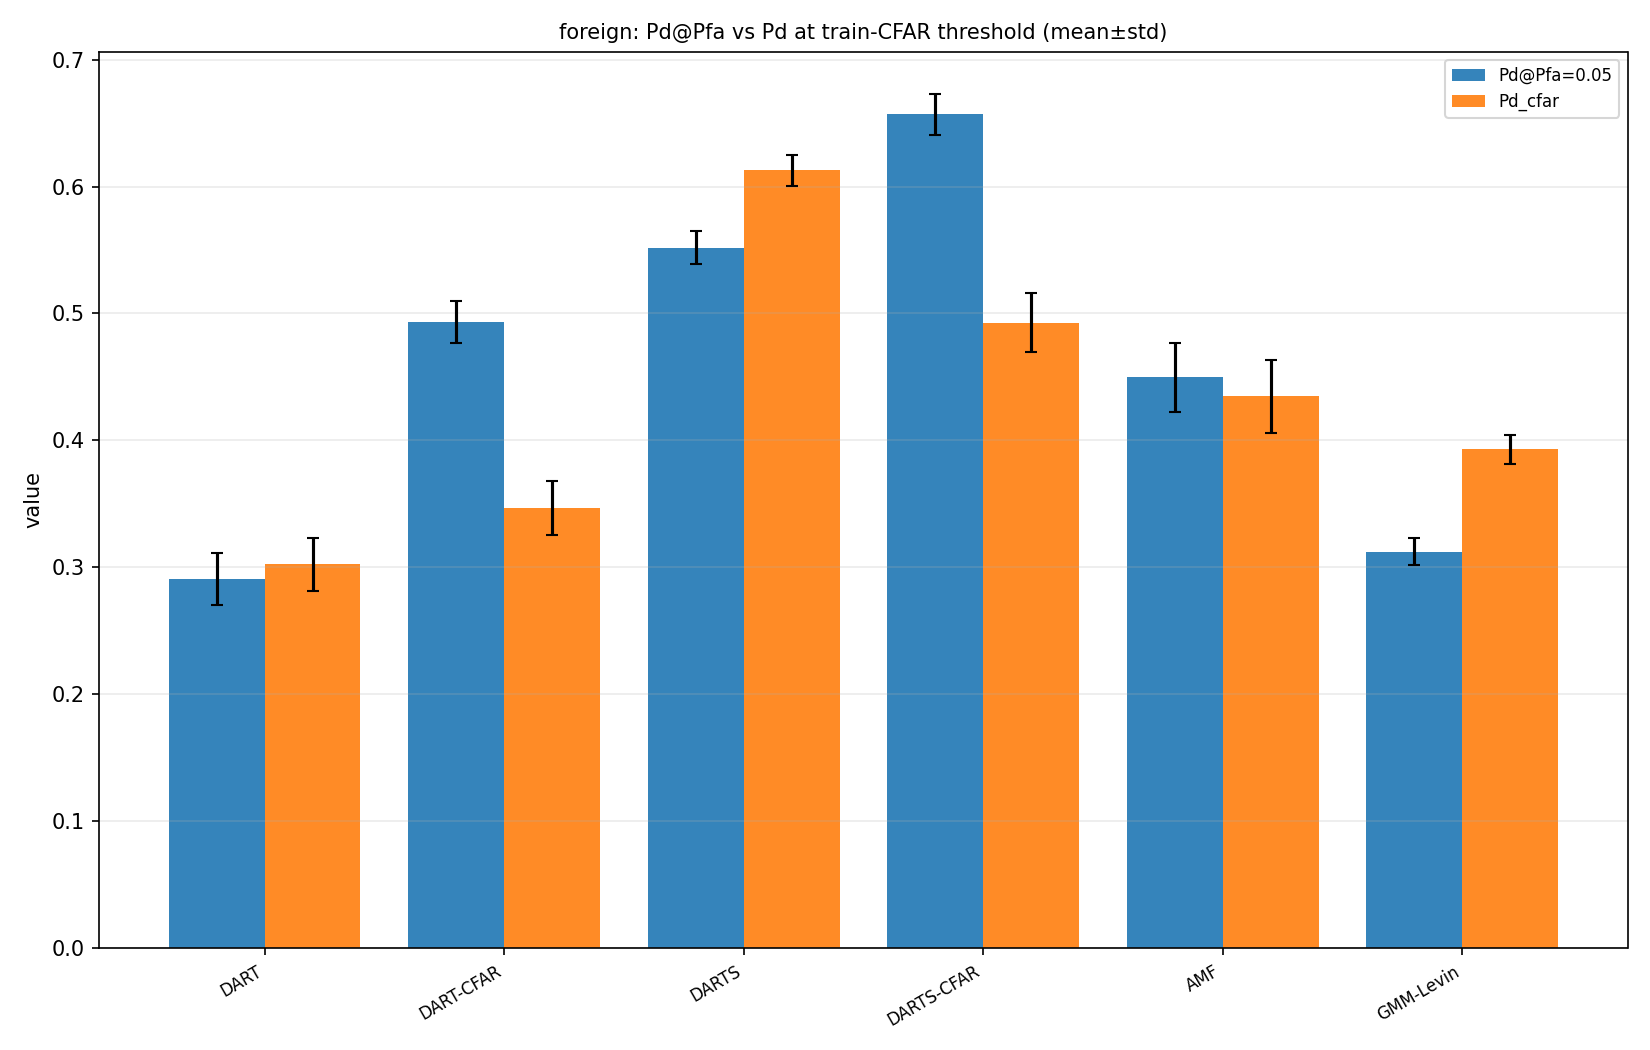

── foreign_pfa_bar.png ──


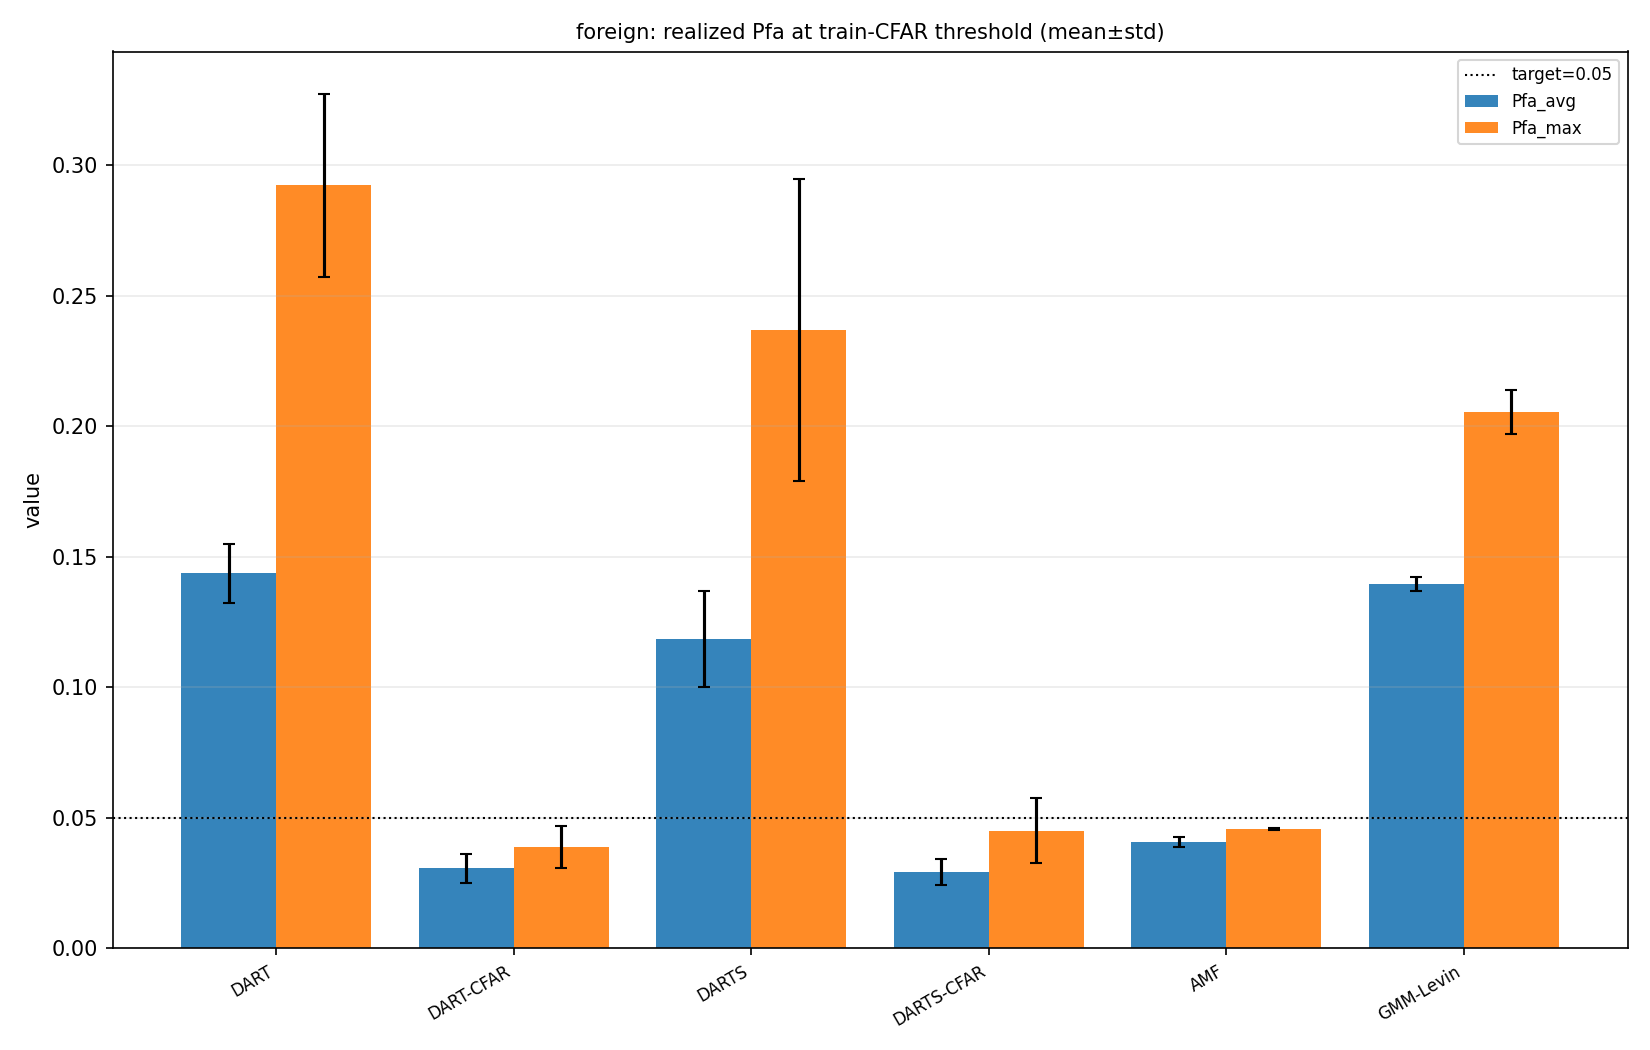


=== Representative qualitative figures (seed 42) ===
── false_color.png ──


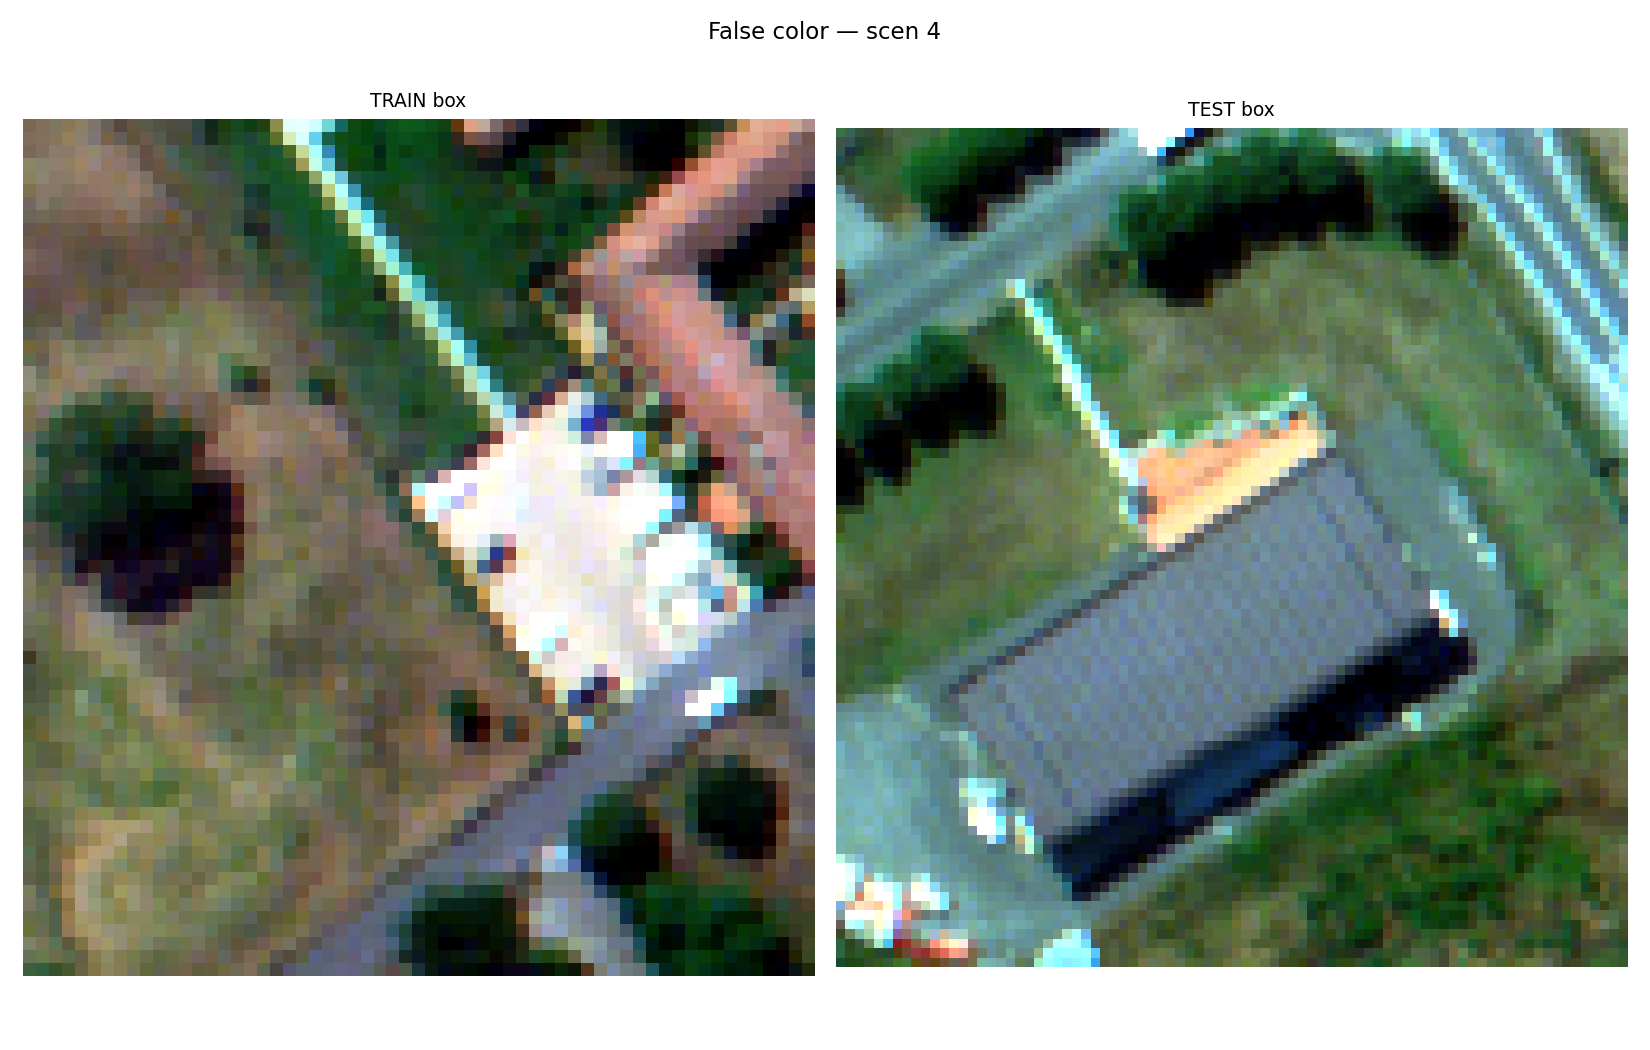

── label_map_targets.png ──


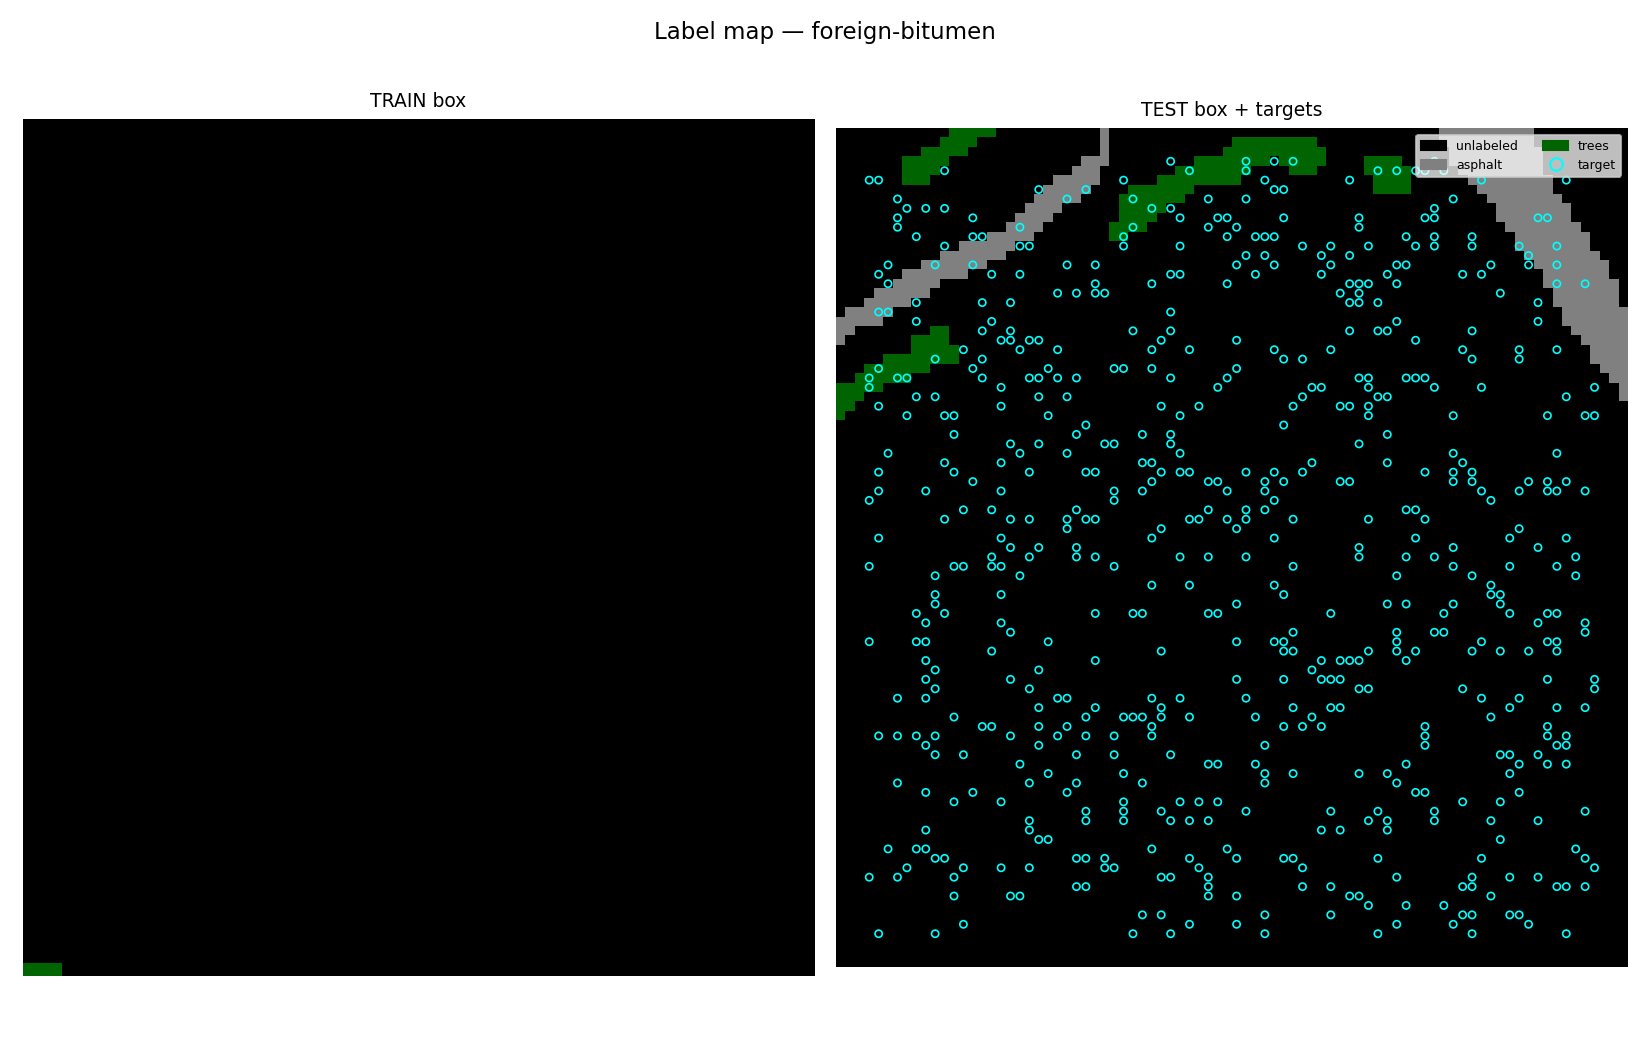

── signatures.png ──


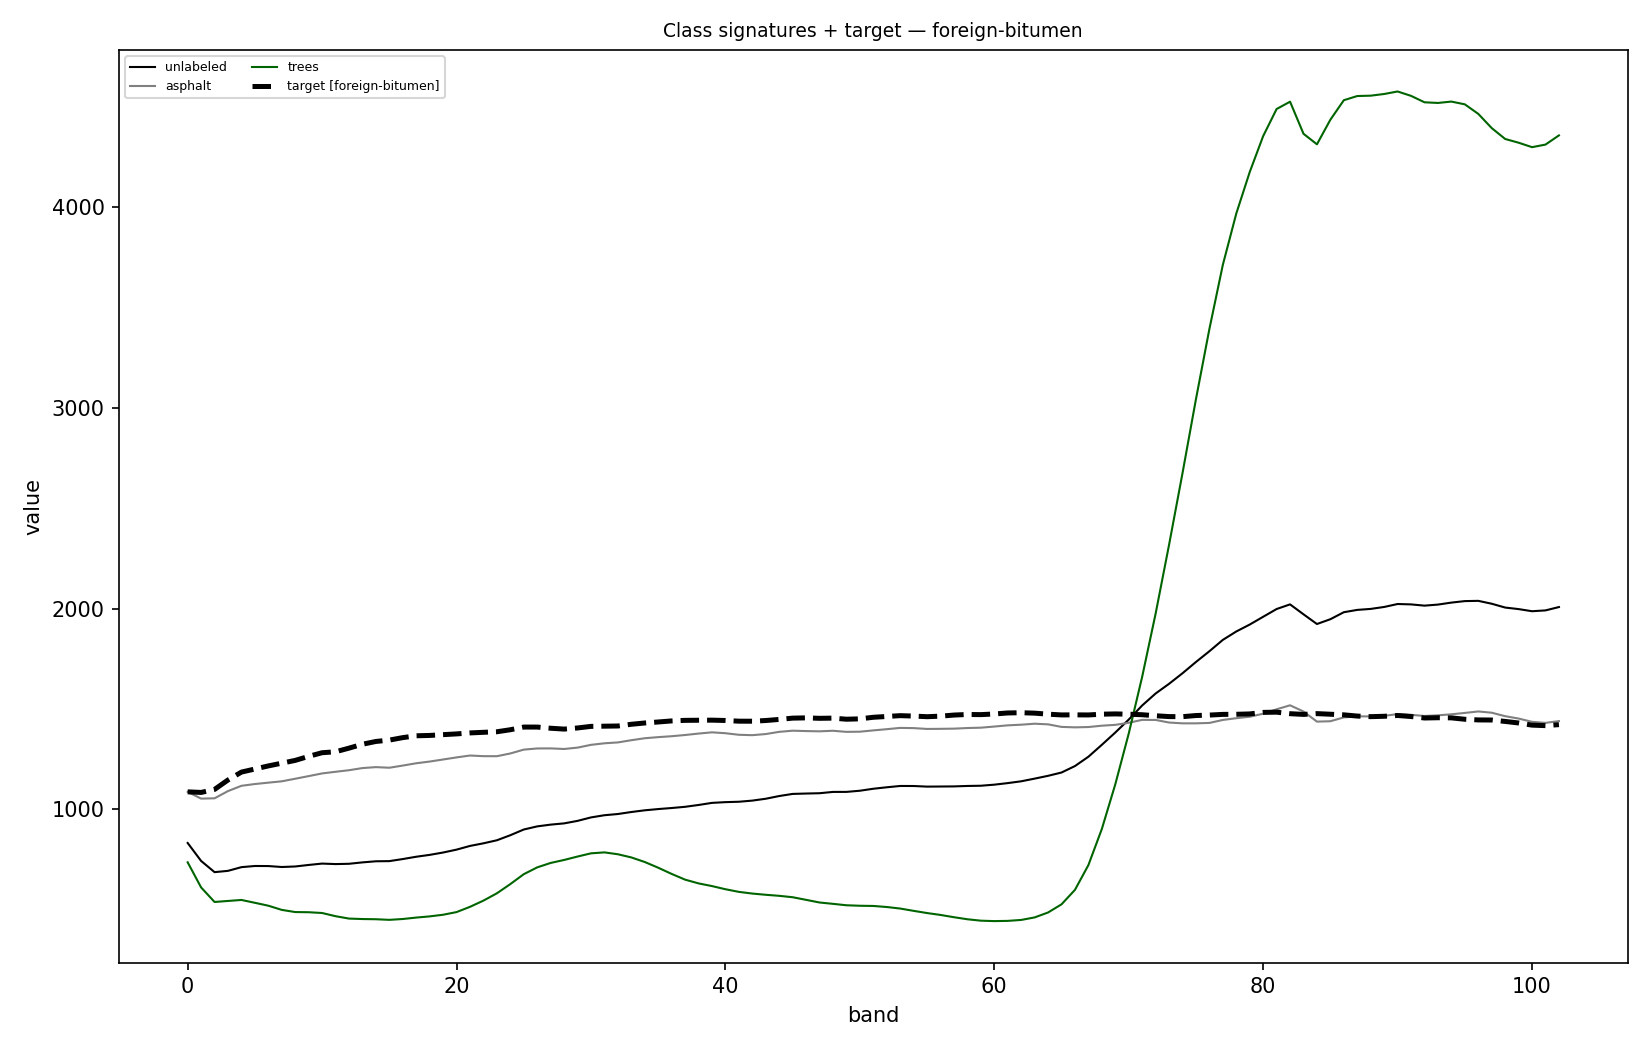

── detection_maps.png ──


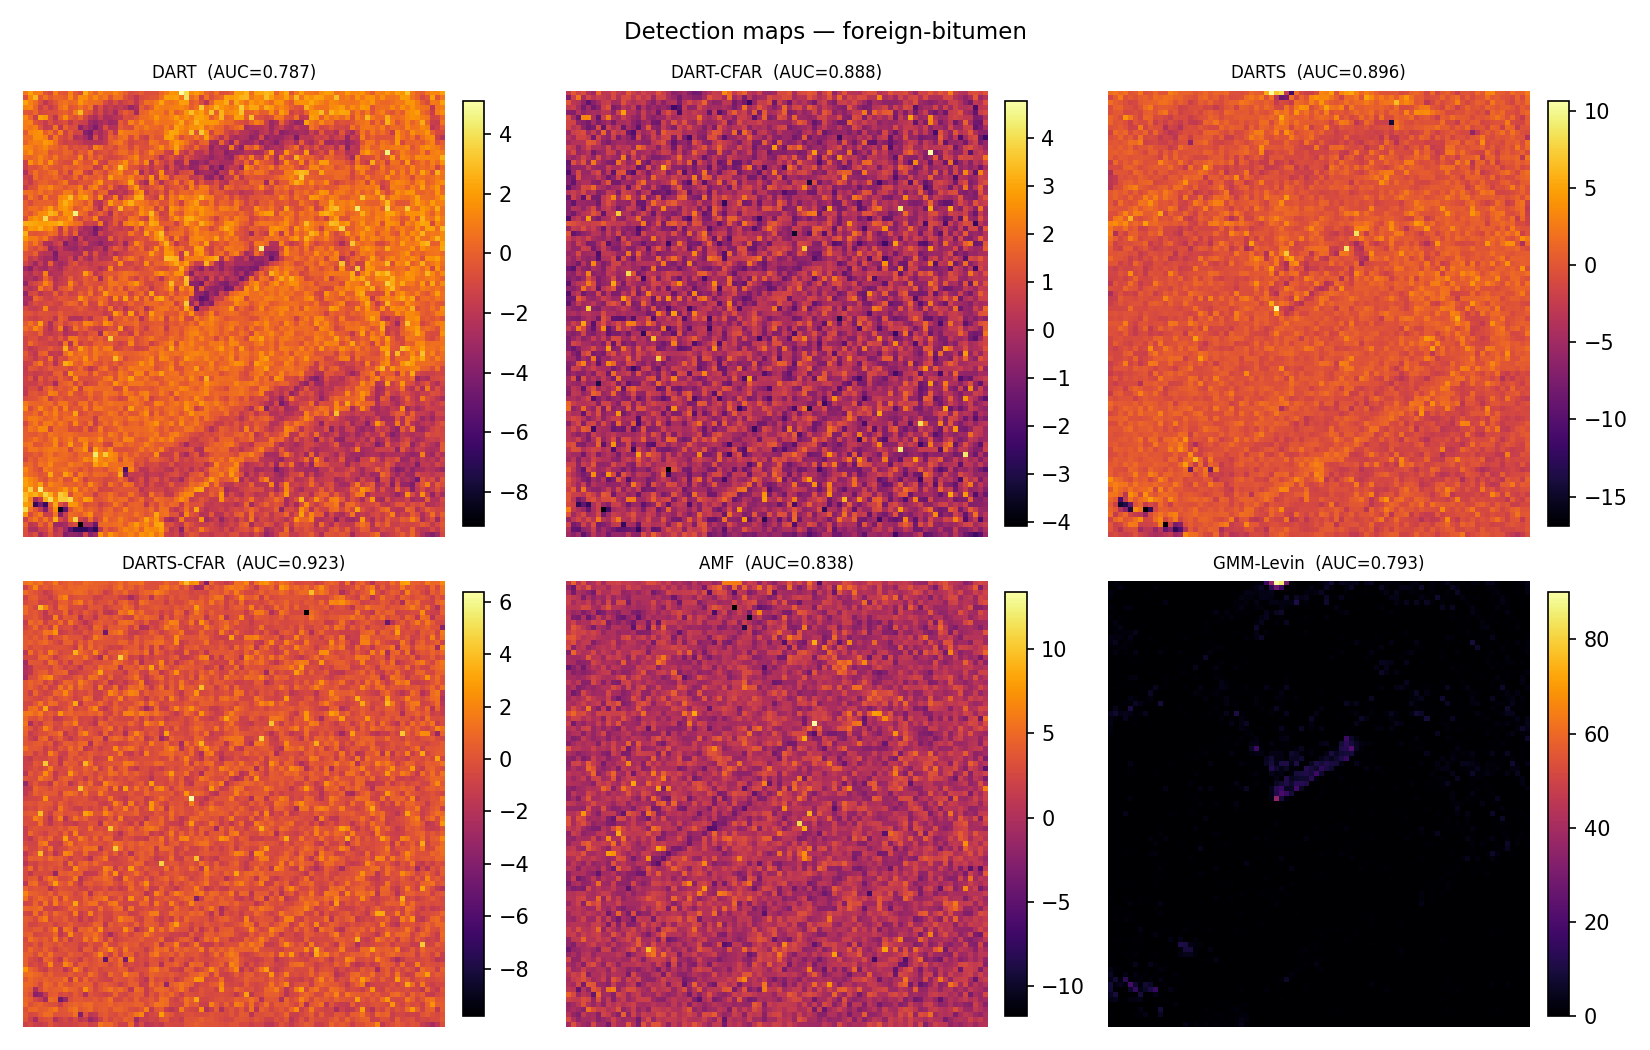

── detected_pfa.png ──


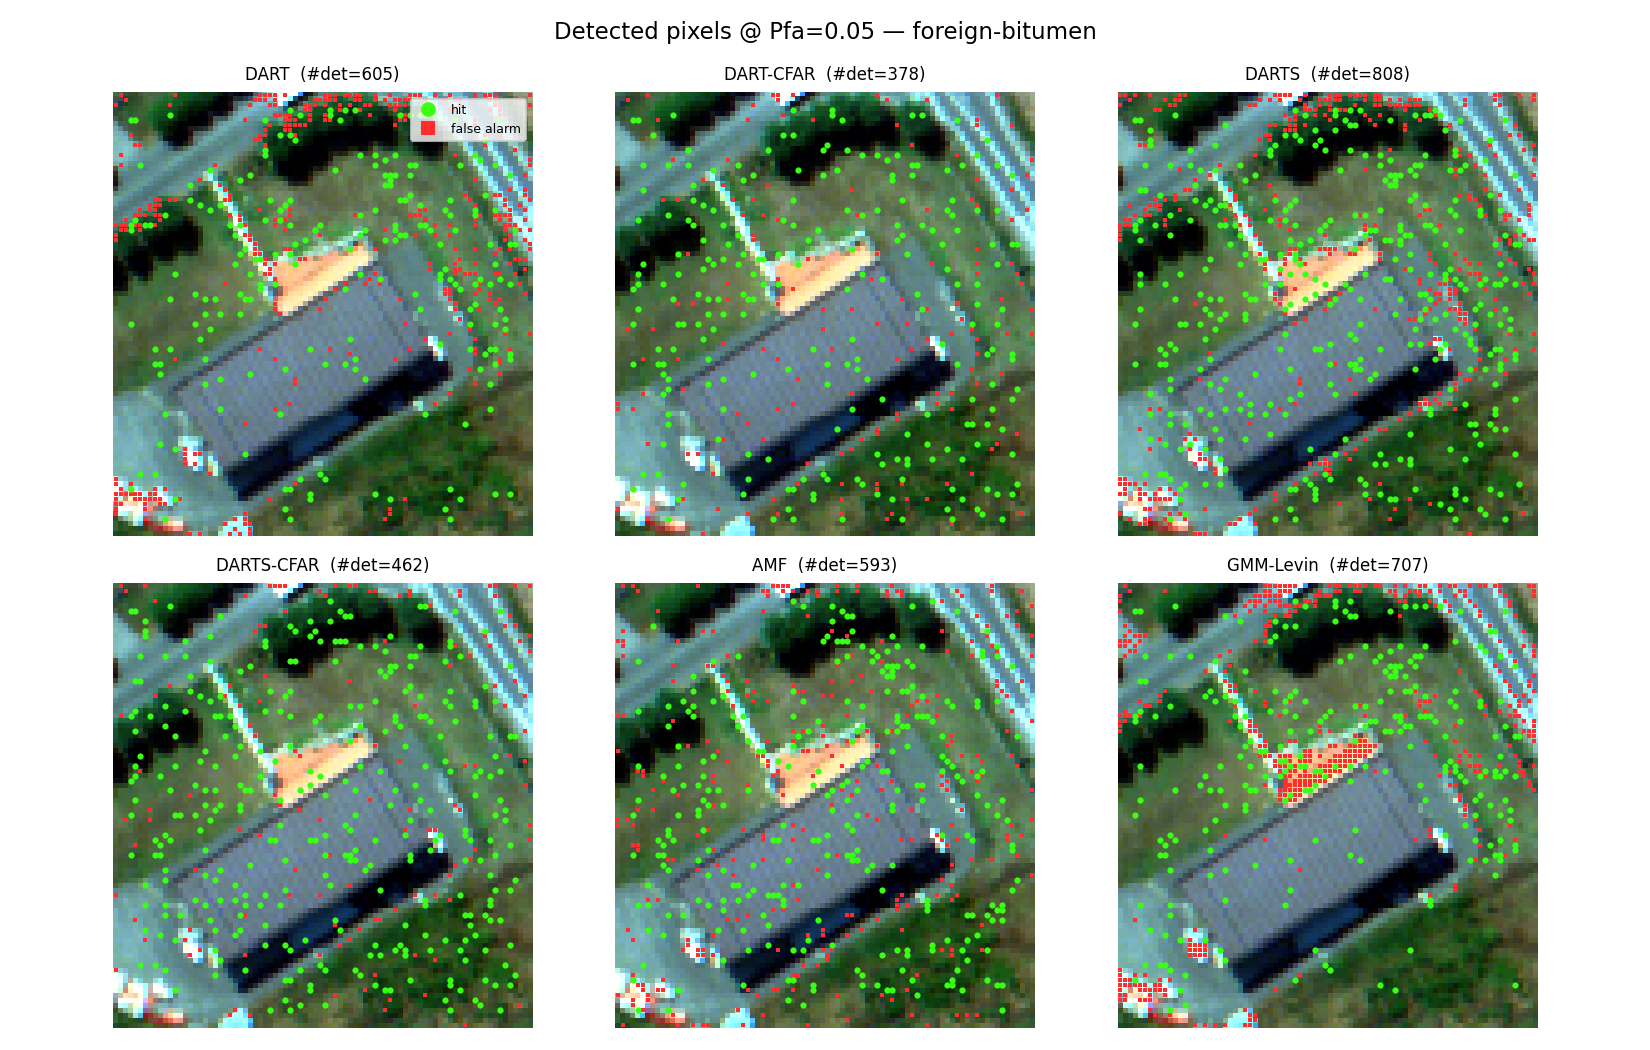

── roc.png ──


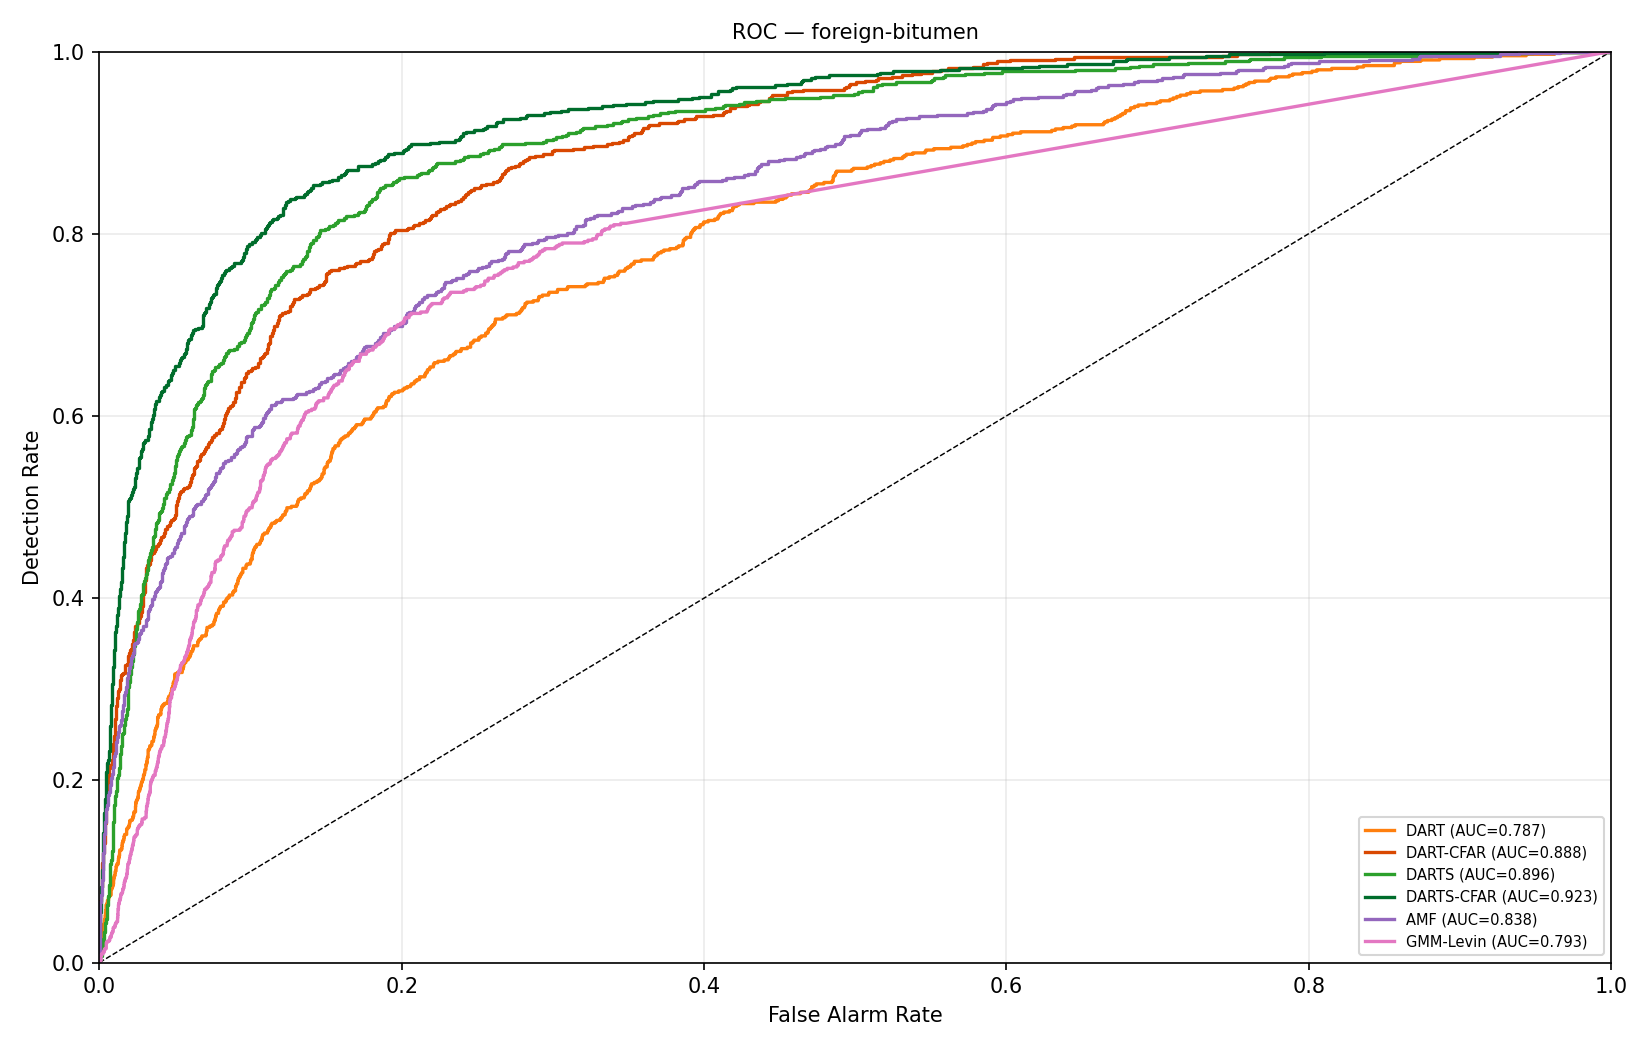

── pfa_per_class.png ──


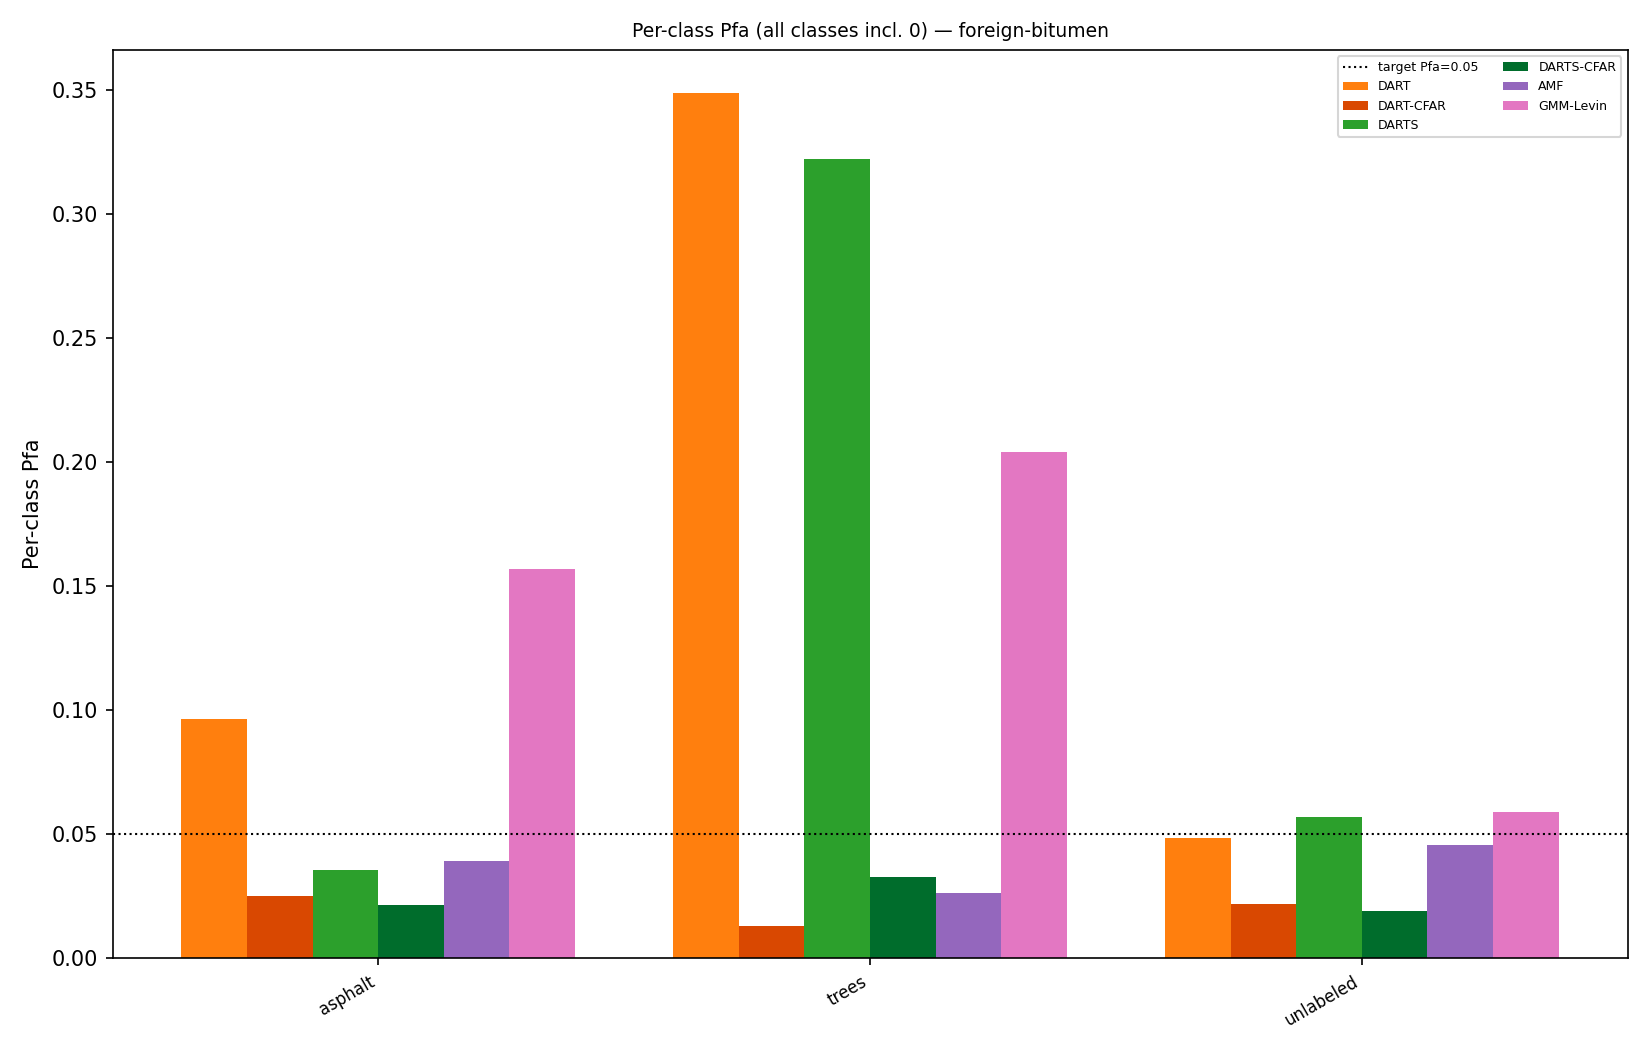

── false_alarms_falsecolor.png ──


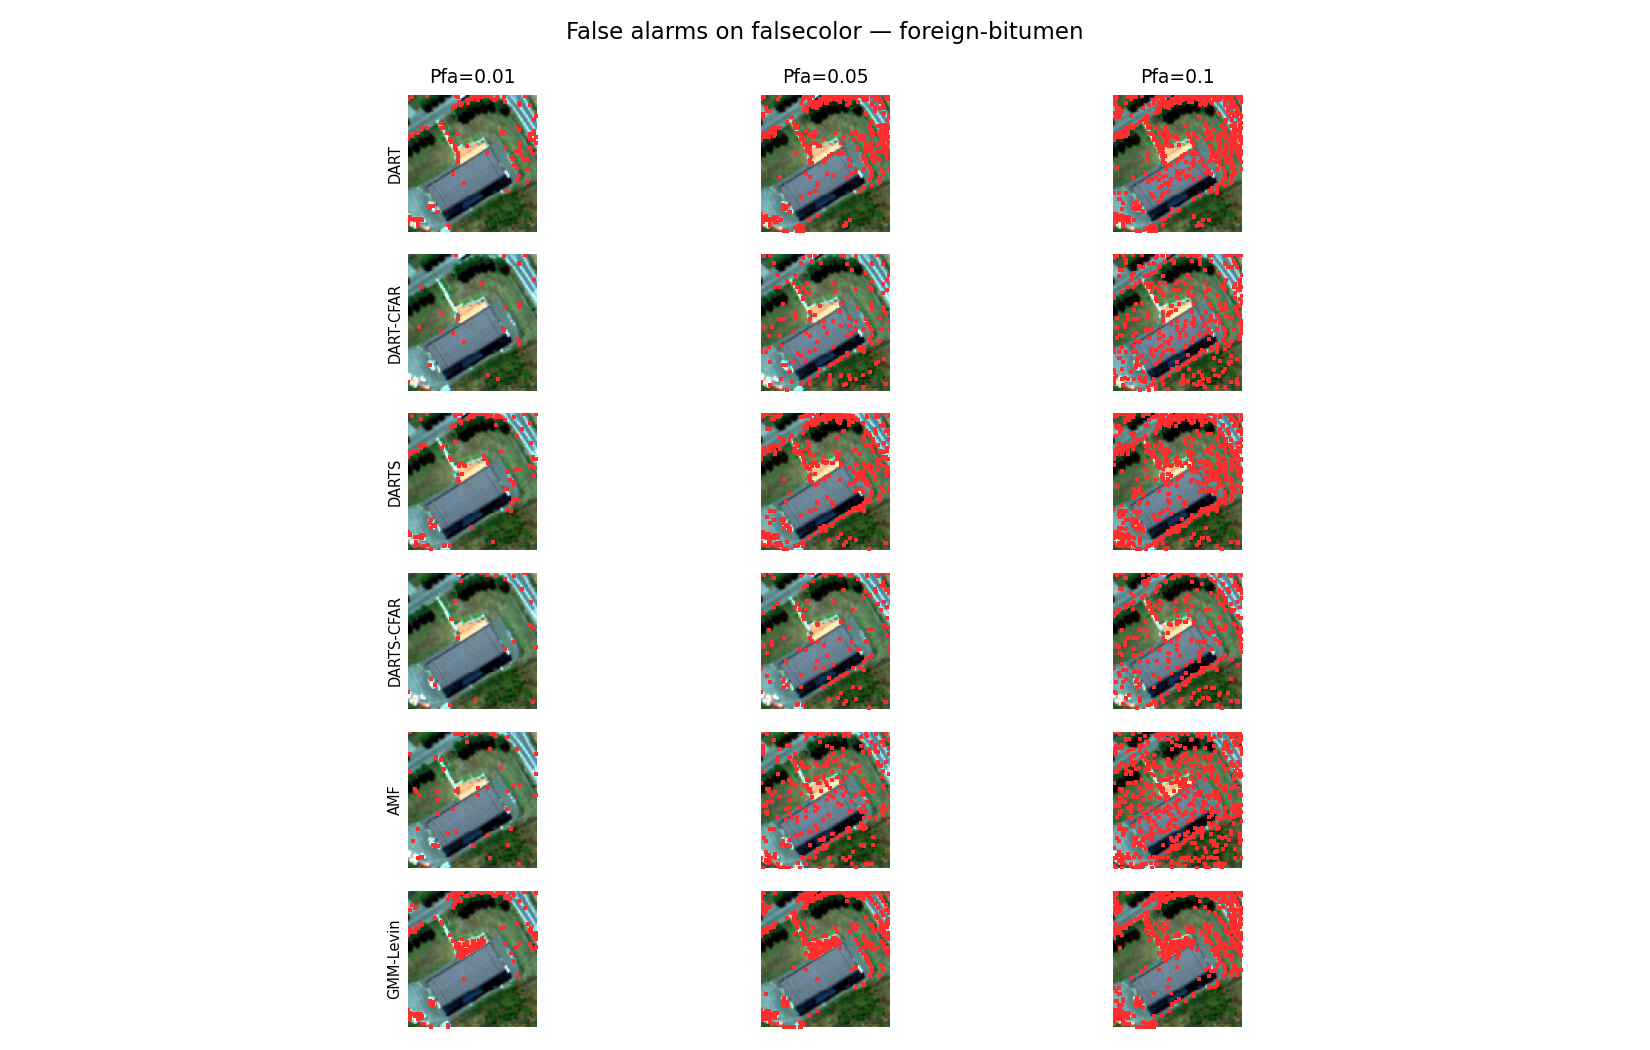

── false_alarms_labelmap.png ──


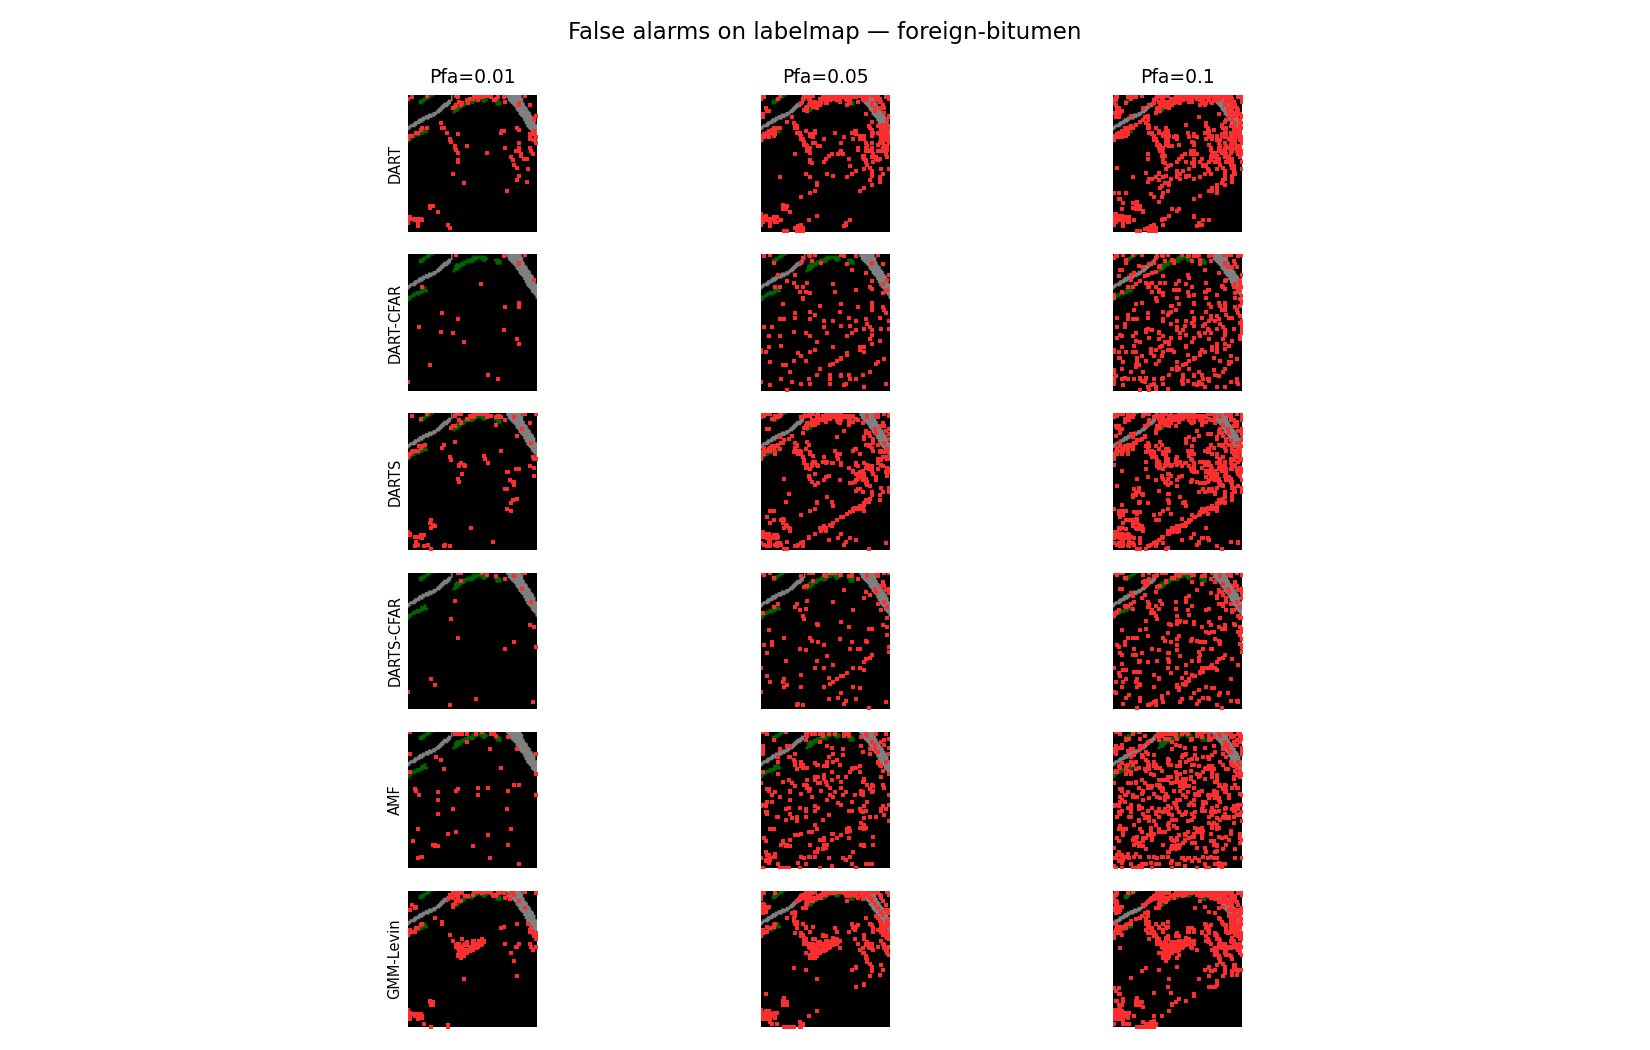


=== Summary Table ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[asphalt] | Pfa[trees] |
|---|---|---|---|---|---|---|---|---|---|
| DART | 0.179 | 0.787 | 0.317 | 0.331 | 0.165 | 0.349 | 0.049 | 0.096 | 0.349 |
| DART-CFAR | 0.354 | 0.888 | 0.491 | 0.352 | 0.020 | 0.025 | 0.022 | 0.025 | 0.013 |
| DARTS | 0.329 | 0.896 | 0.541 | 0.594 | 0.138 | 0.322 | 0.057 | 0.036 | 0.322 |
| DARTS-CFAR | 0.480 | 0.923 | 0.655 | 0.507 | 0.025 | 0.033 | 0.019 | 0.021 | 0.033 |
| AMF | 0.323 | 0.838 | 0.456 | 0.442 | 0.037 | 0.046 | 0.046 | 0.039 | 0.026 |
| GMM-Levin | 0.140 | 0.793 | 0.303 | 0.393 | 0.140 | 0.204 | 0.059 | 0.157 | 0.204 |


########## MULTI-SEED  seeds=[42, 43, 44, 45, 46]  -> results/spatial/multiseed_20260617_083506

===== seed 42  (1/5) =====
Device: cuda
Loading data ...
Image 610×340×103
Scenario 4: train_box=[85, 193, 207, 306]  test_box=[419, 508, 250, 334]
train=4026 px  (box [106, 172, 226, 287])
test=7476 px  (89×84)
AM

DART:   0%|          | 0/1000 [00:00<?, ?it/s, loss=1031.3433]

    [DSM] epoch 1/1000  loss=1031.3433  best=1031.3433


DART:  10%|▉         | 97/1000 [00:03<00:30, 30.04it/s, loss=807.3580]

    [DSM] epoch 100/1000  loss=807.3580  best=806.2043


...

    [NeighborMLP] epoch 900/1000  loss=788.1914  best=783.5277


DARTS: 100%|█████████▉| 999/1000 [00:35<00:00, 29.41it/s, loss=790.8054]

    [NeighborMLP] epoch 1000/1000  loss=790.8054  best=783.5277


  NeighborMLP done (36s)  best loss=783.5277
  saved models -> results/spatial/multiseed_20260617_083506/seeds/compare_20260617_084318/models.pt

########## DETECTION RUN: foreign-bitumen ##########
[foreign-bitumen] planted 647 targets  ||s||=1.436e+04
Scoring detectors (test) ...


Scoring detectors (train, for CFAR thresholds) ...
Active detectors: ['DART', 'DART-CFAR', 'DARTS', 'DARTS-CFAR', 'AMF', 'GMM-Levin']

=== Summary [foreign-bitumen] ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[asphalt] | Pfa[trees] |
|---|---|---|---|---|---|---|---|---|---|
| DART | 0.161 | 0.796 | 0.275 | 0.287 | 0.131 | 0.247 | 0.044 | 0.104 | 0.247 |
| DART-CFAR | 0.295 | 0.879 | 0.465 | 0.247 | 0.023 | 0.039 | 0.017 | 0.014 | 0.039 |
| DARTS | 0.337 | 0.907 | 0.564 | 0.631 | 0.117 | 0.240 | 0.061 | 0.050 | 0.240 |
| DARTS-CFAR | 0.381 | 0.923 | 0.612 | 0.357 | 0.034 | 0.071 | 0.019 | 0.011 | 0.071 |
| AMF | 0.326 | 0.845 | 0.459 | 0.447 | 0.043 | 0.046 | 0.046 | 0.043 | 0.039 |
| GMM-Levin | 0.156 | 0.803 | 0.323 | 0.406 | 0.134 | 0.195 | 0.058 | 0.150 | 0.195 |

Saving figures ...
  [fig] results/spatial/multiseed_20260617_083506/seeds/compare_20260617_084318/foreign/false_color.pdf
  [fig] results/spatial/multiseed_20260617_

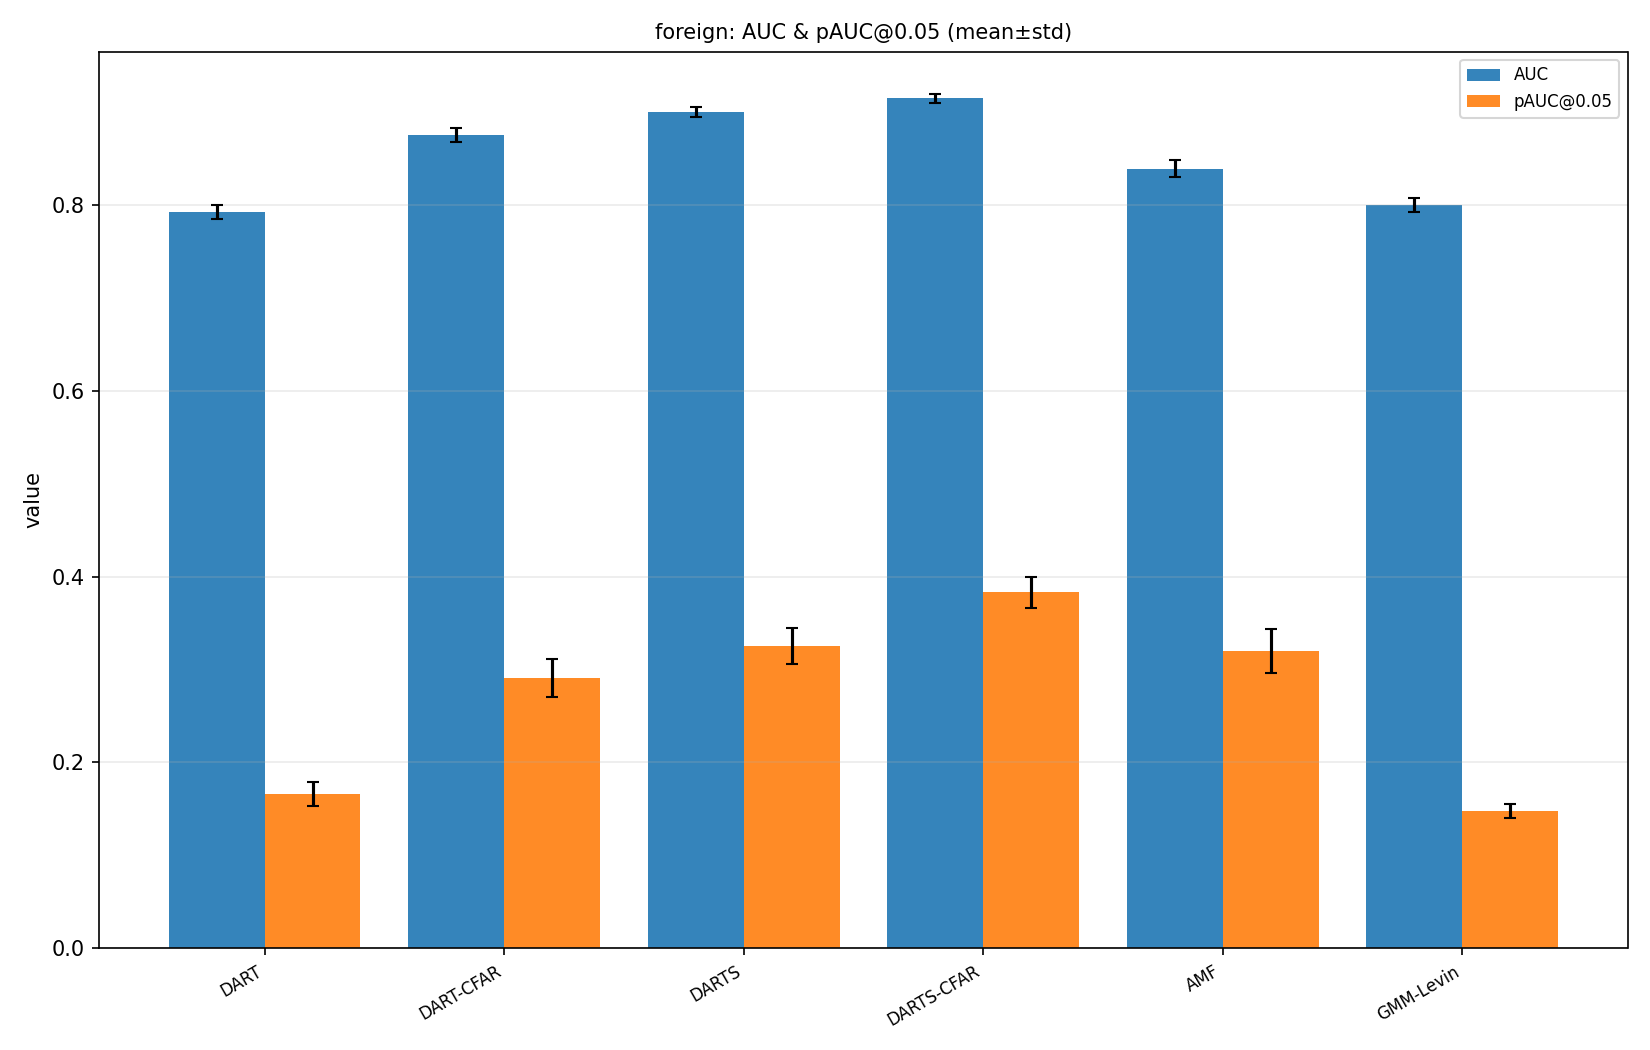

── foreign_pd_bar.png ──


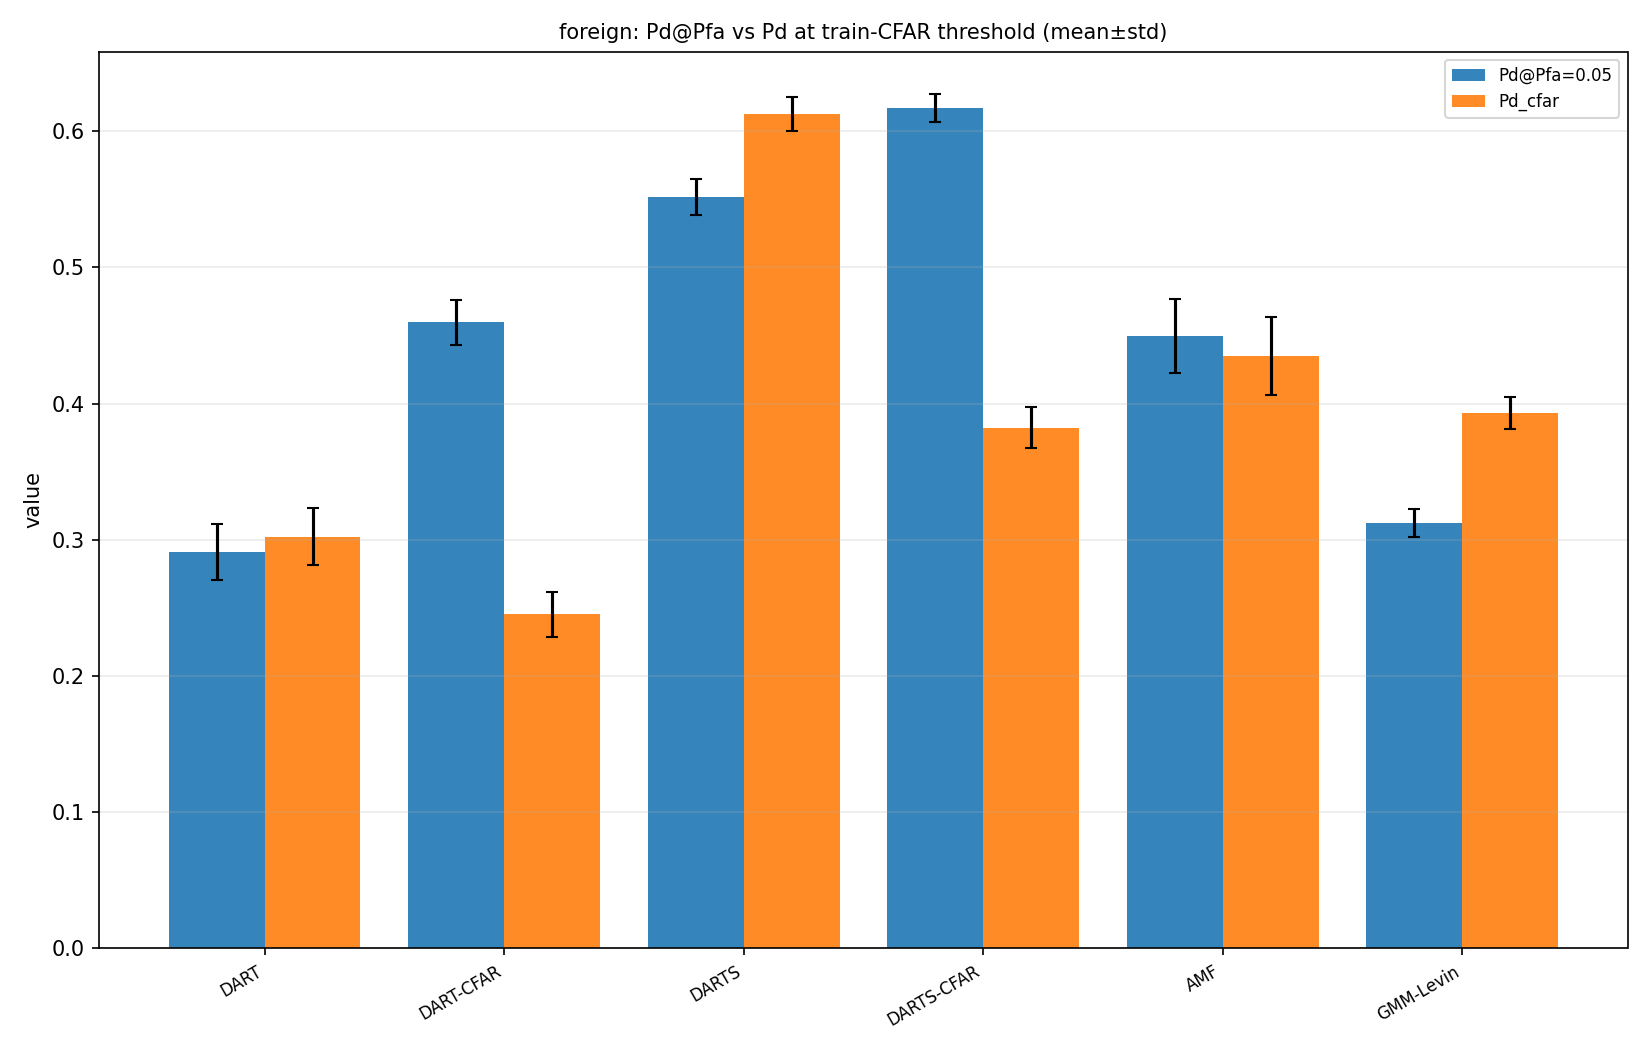

── foreign_pfa_bar.png ──


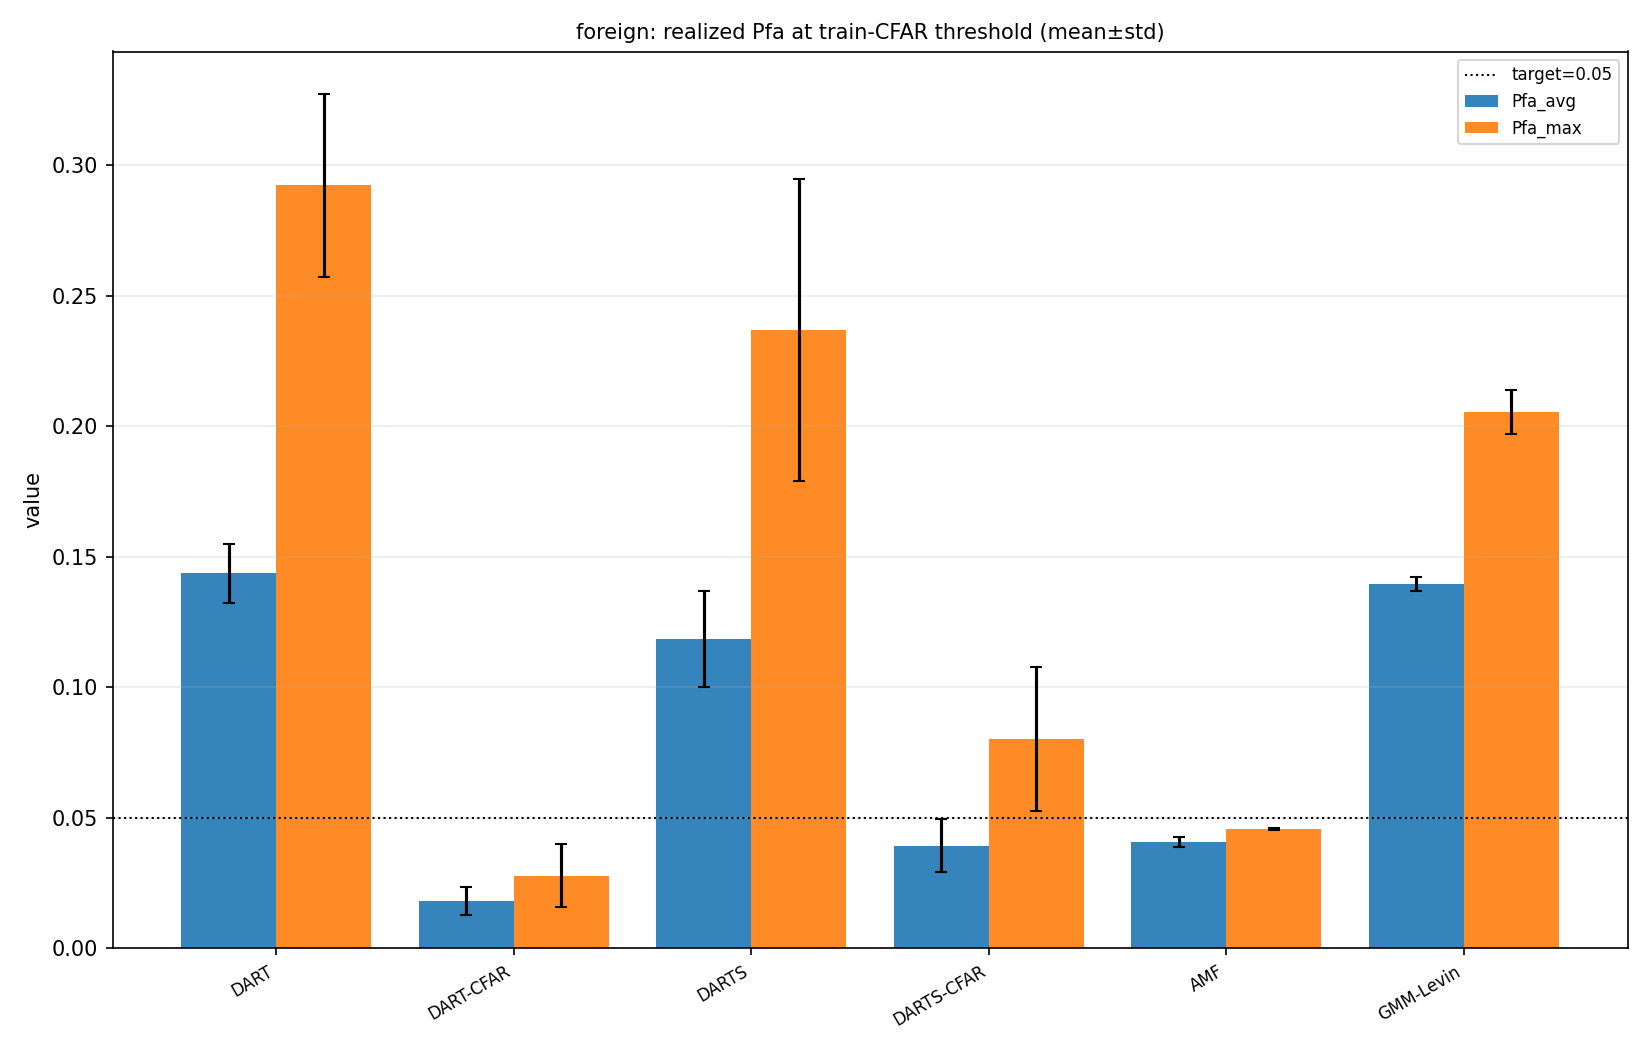


=== Representative qualitative figures (seed 42) ===
── false_color.png ──


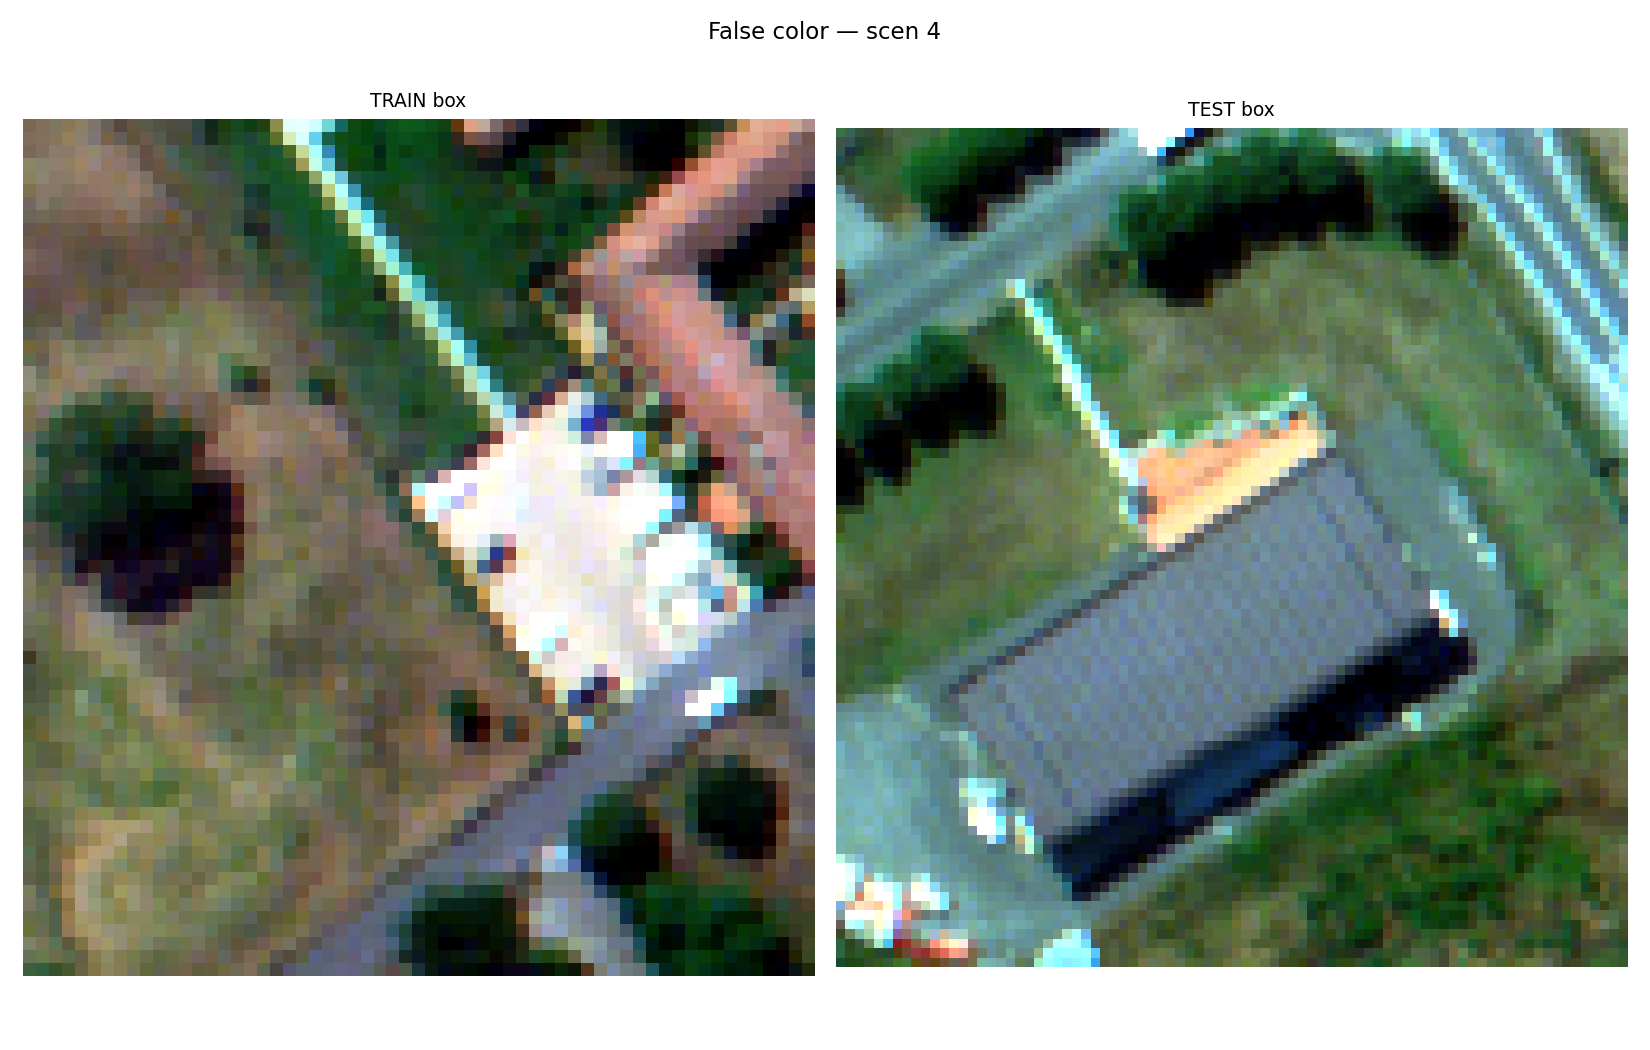

── label_map_targets.png ──


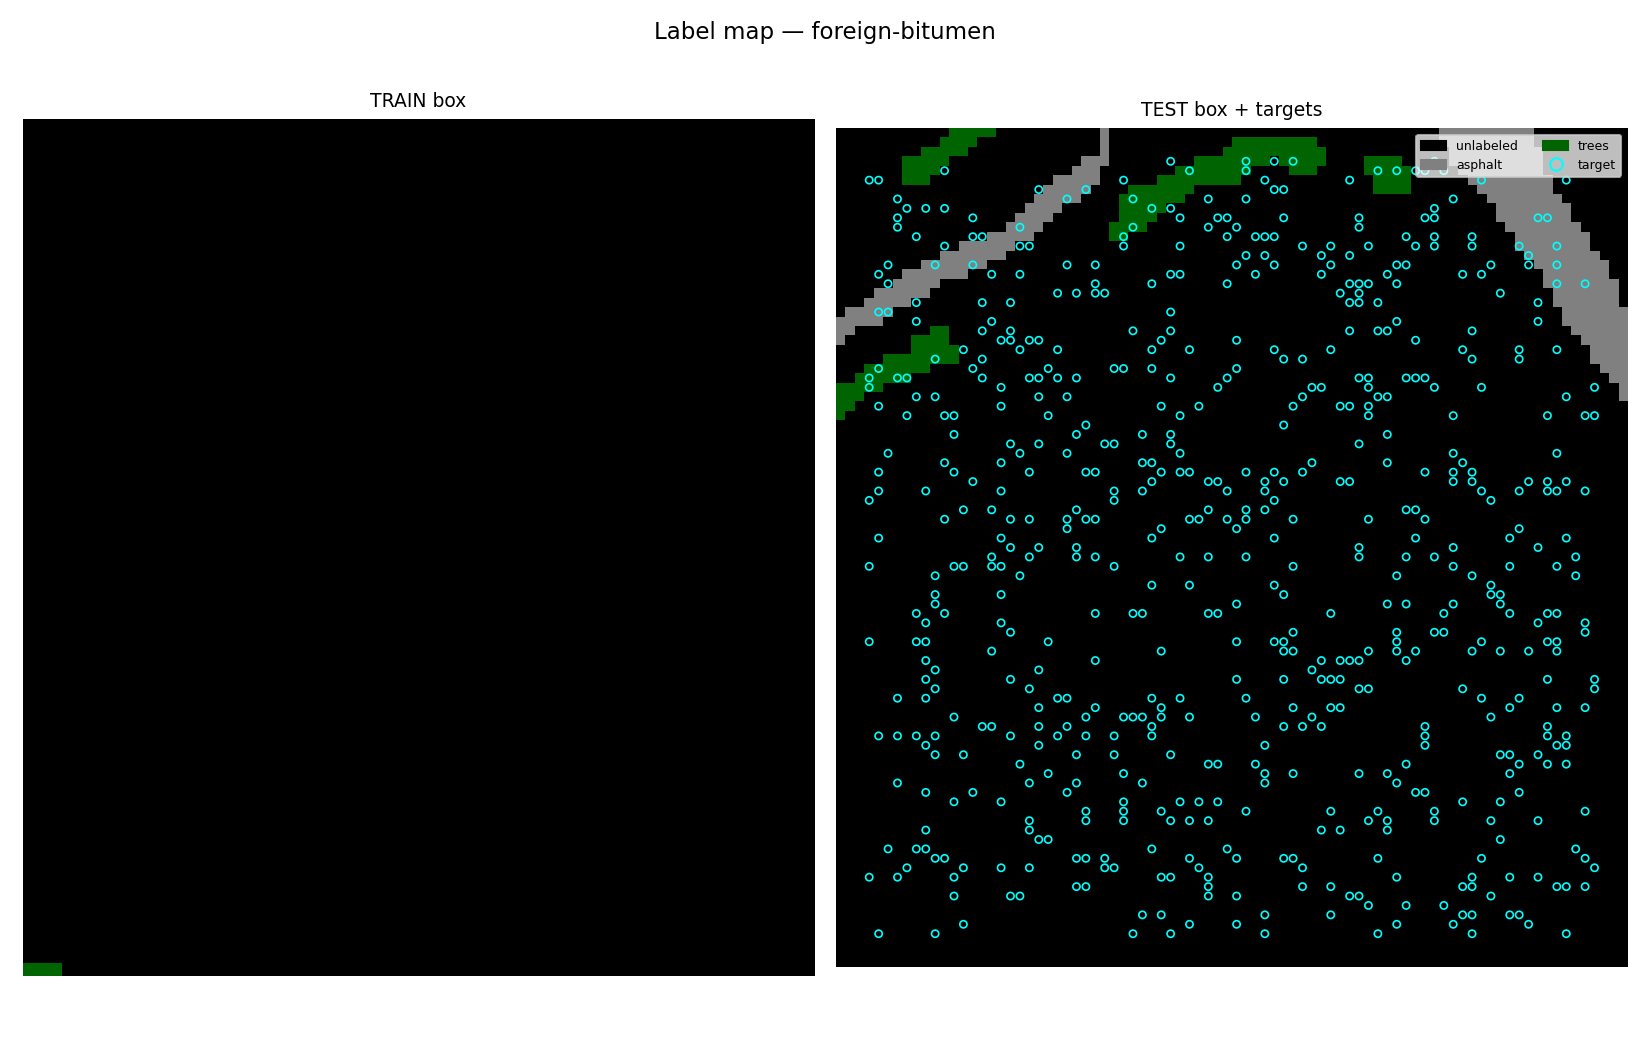

── signatures.png ──


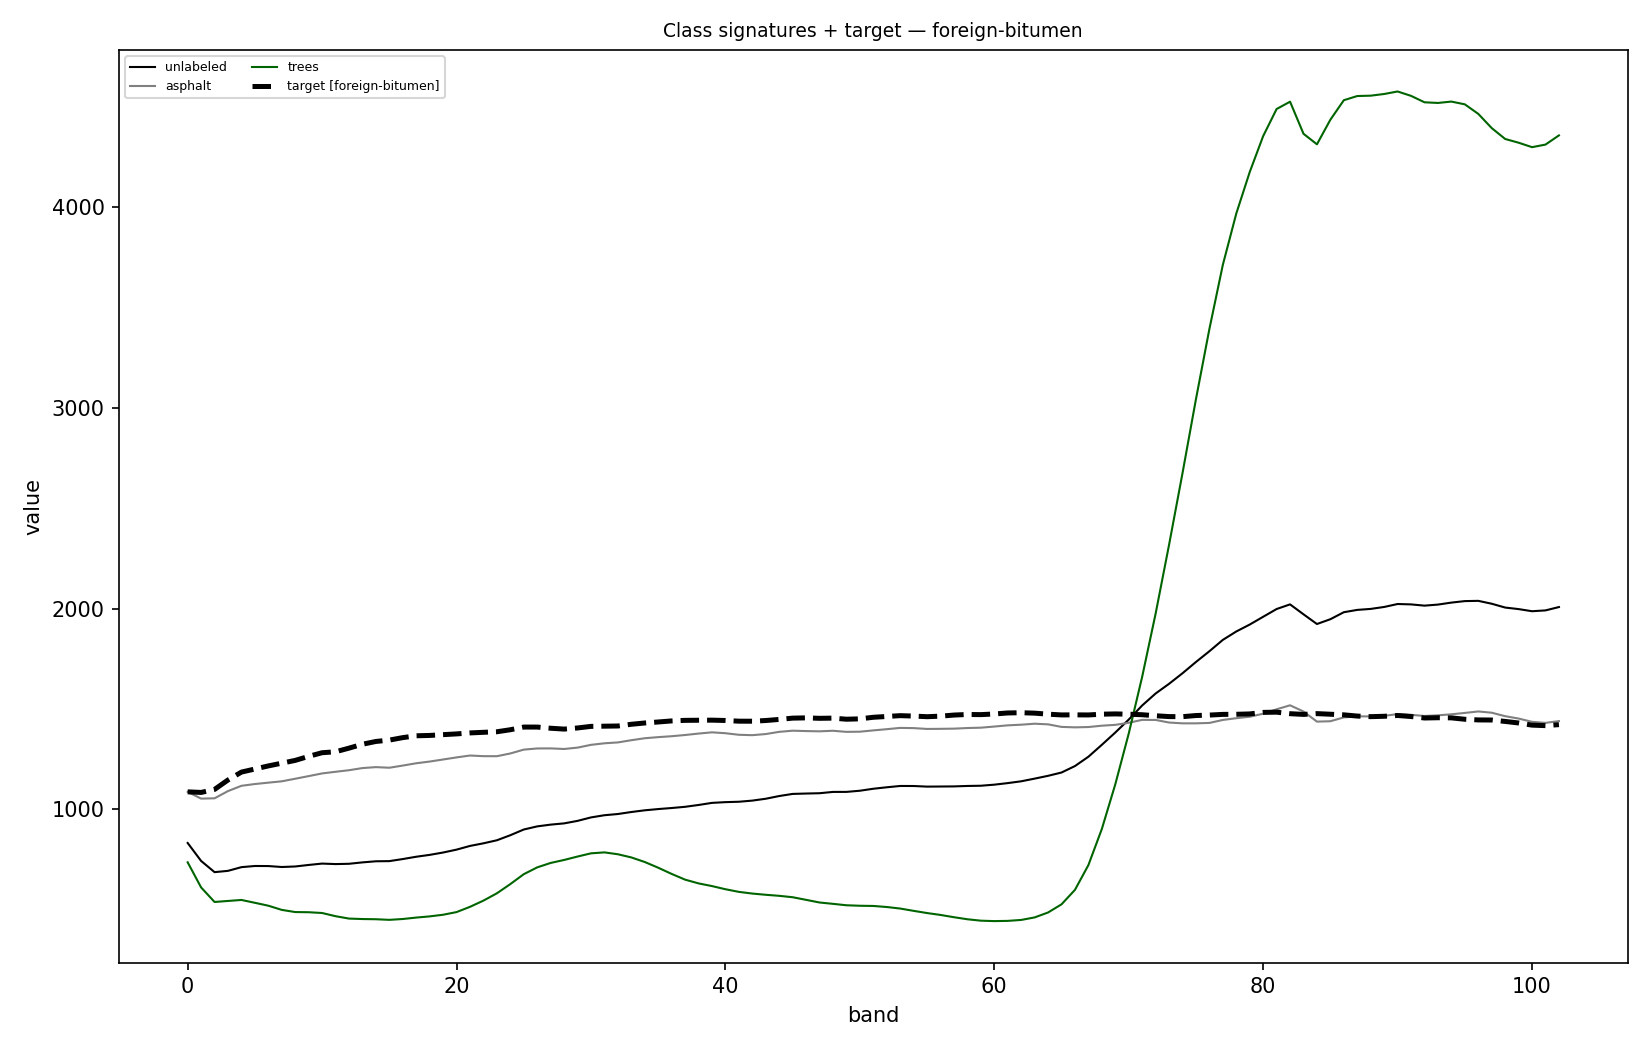

── detection_maps.png ──


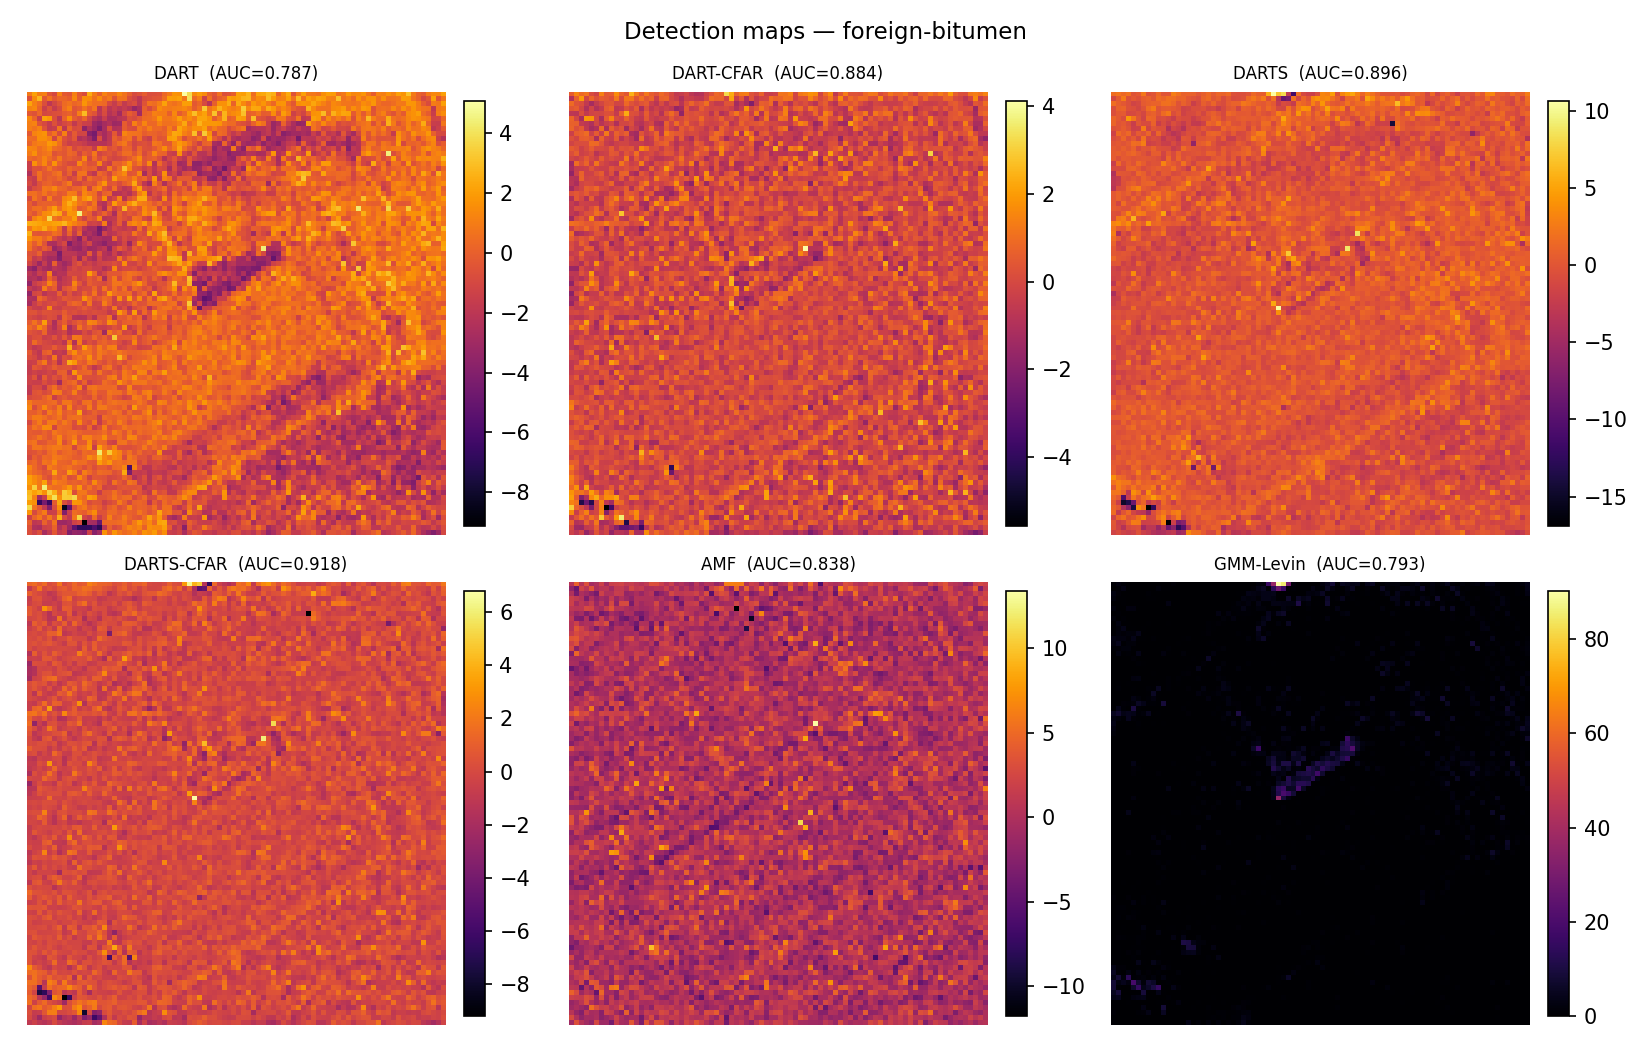

── detected_pfa.png ──


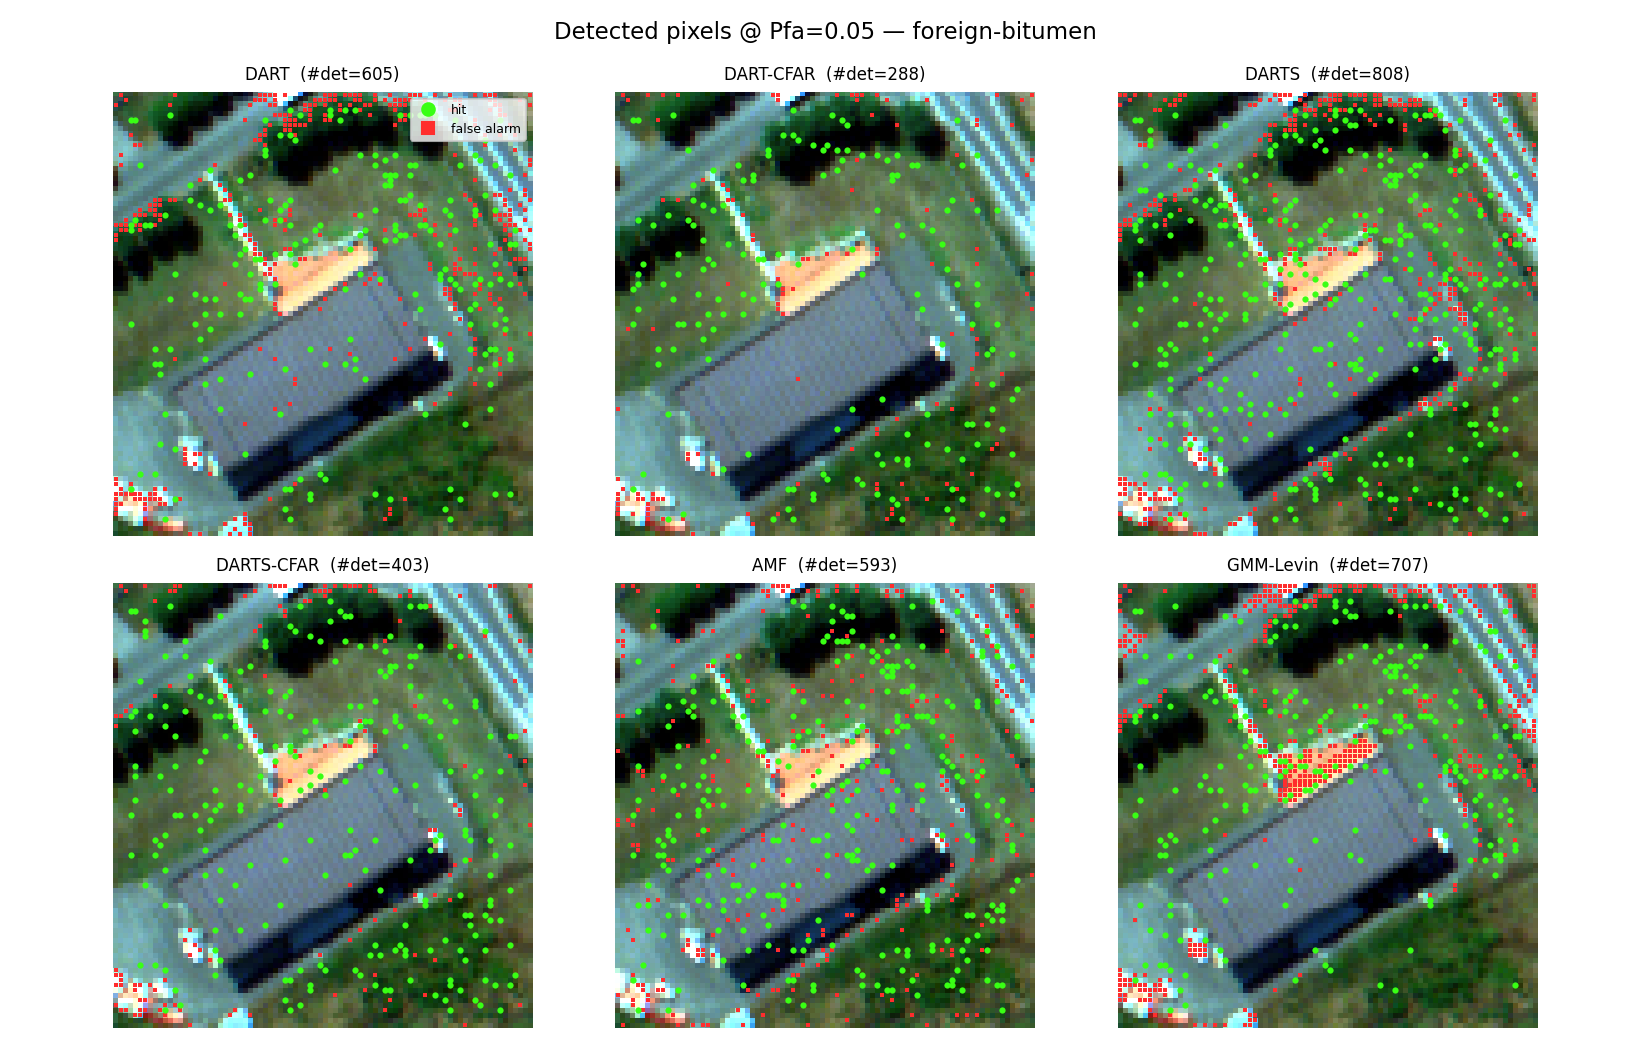

── roc.png ──


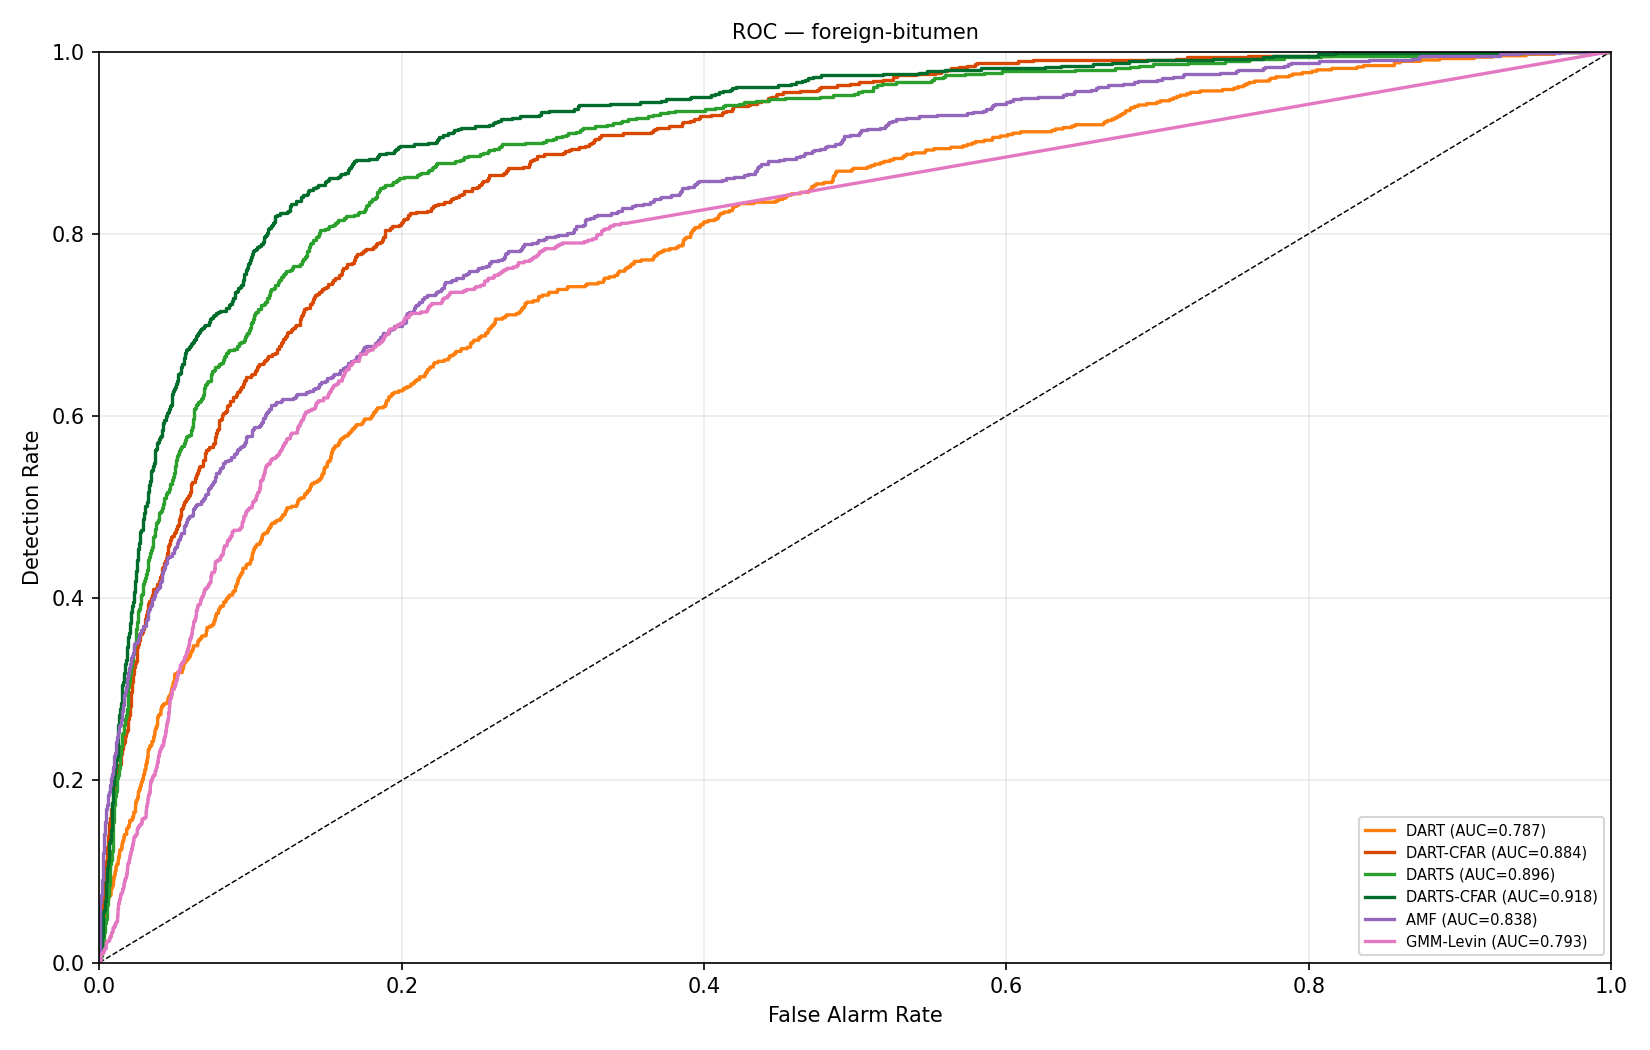

── pfa_per_class.png ──


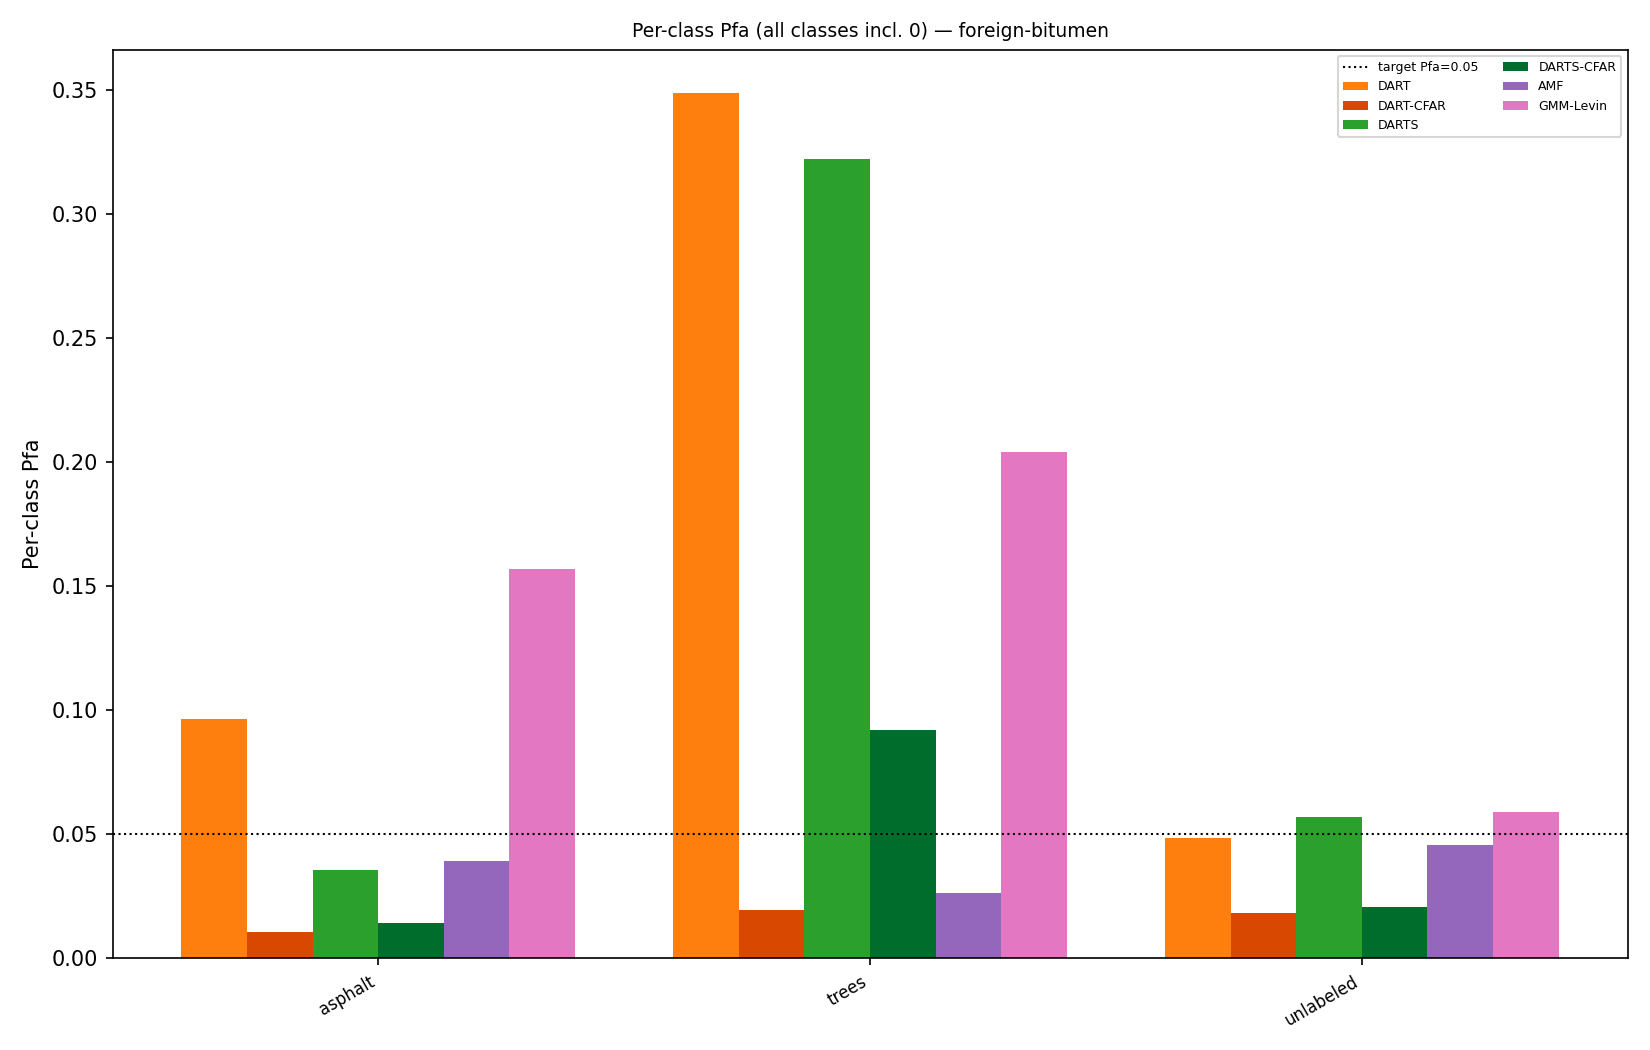

── false_alarms_falsecolor.png ──


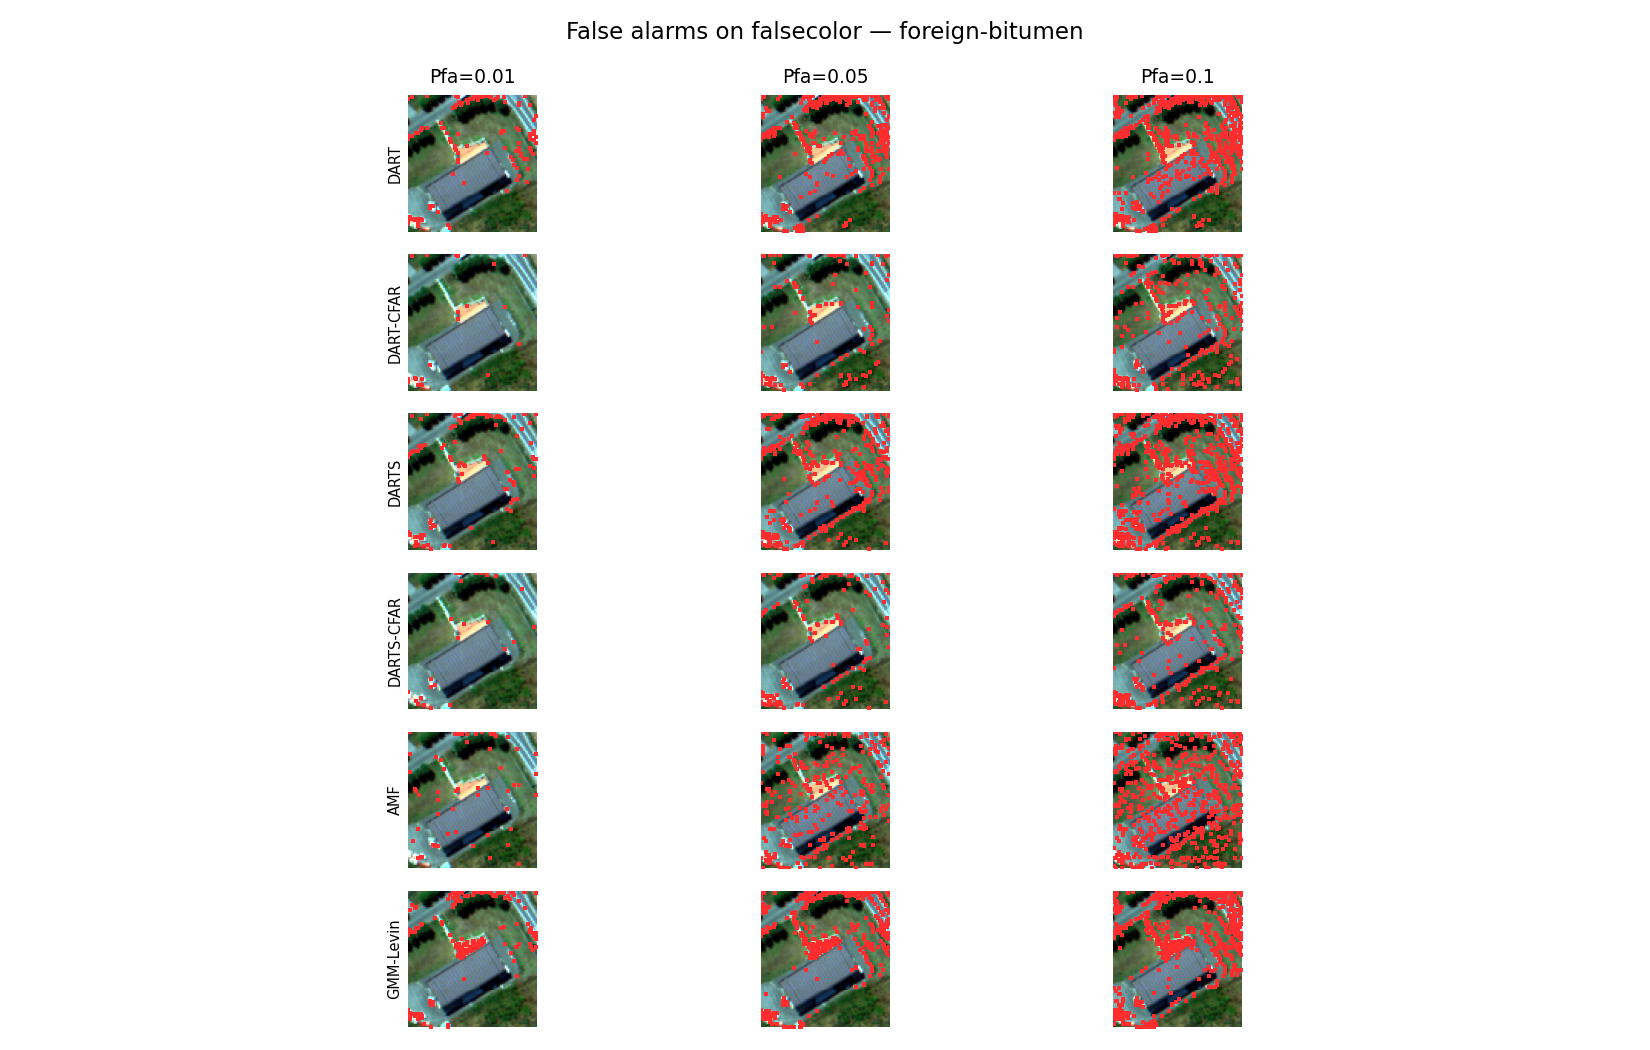

── false_alarms_labelmap.png ──


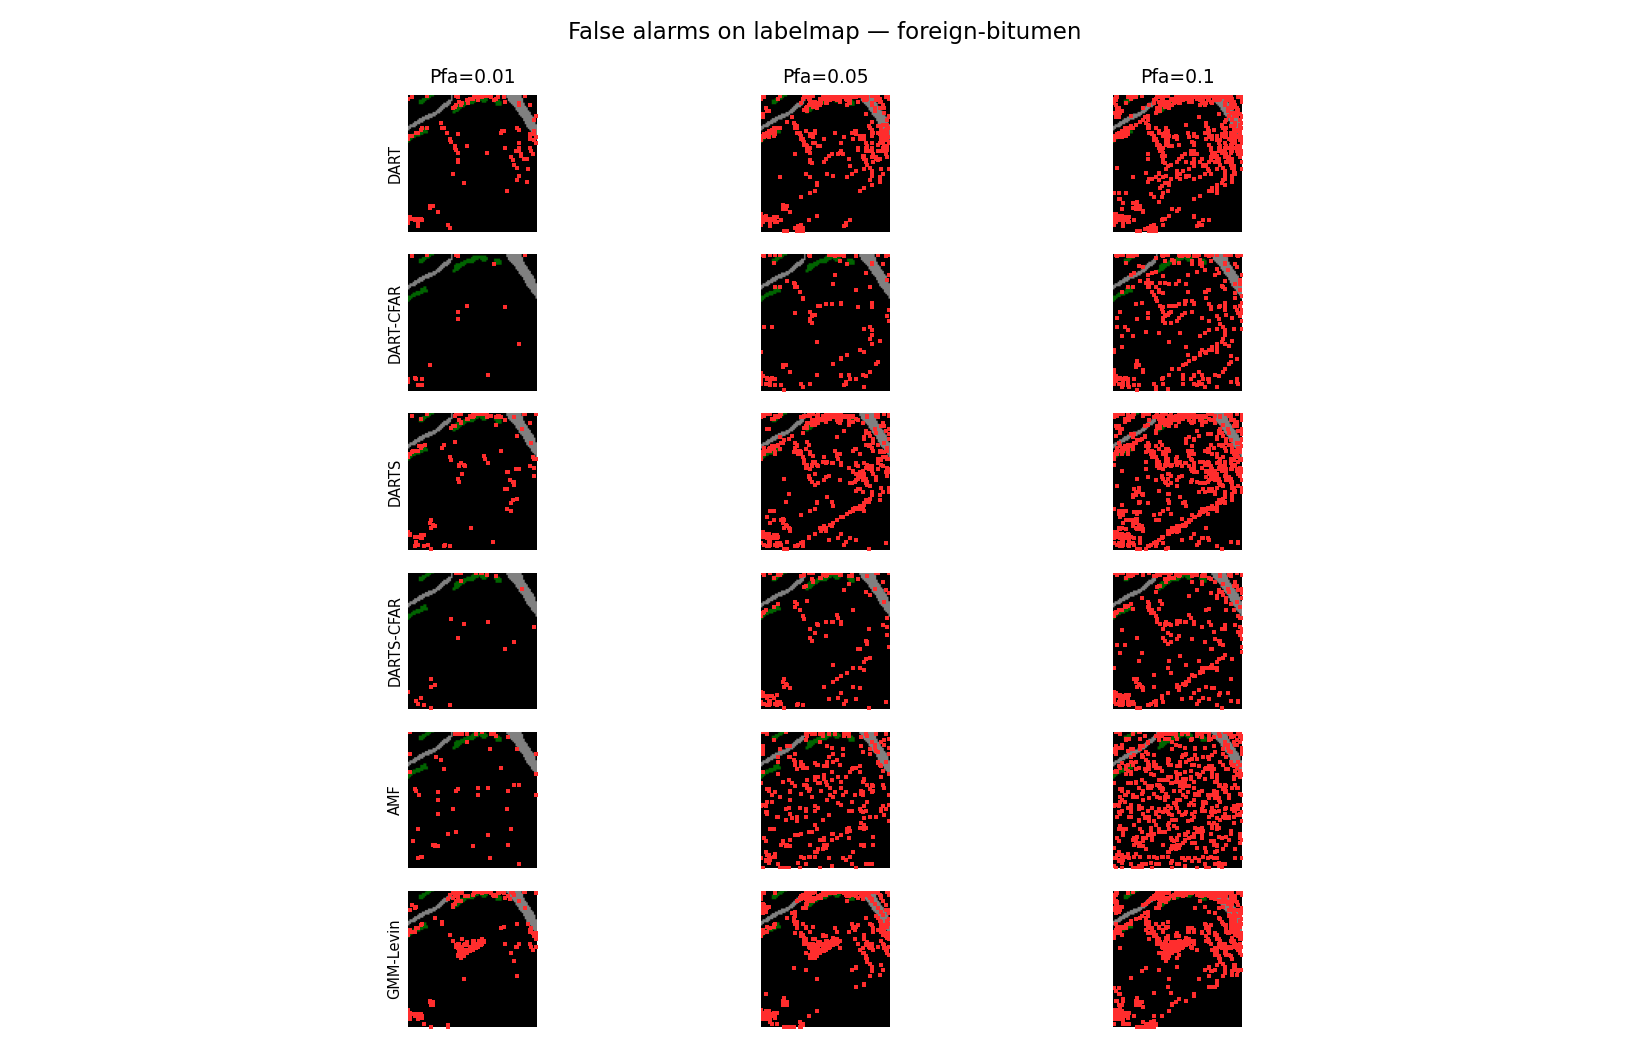


=== Summary Table ===
| Detector | pAUC@0.05 | AUC | Pd@Pfa=0.05 | Pd_cfar | Pfa_avg | Pfa_max | Pfa[unlabeled] | Pfa[asphalt] | Pfa[trees] |
|---|---|---|---|---|---|---|---|---|---|
| DART | 0.179 | 0.787 | 0.317 | 0.331 | 0.165 | 0.349 | 0.049 | 0.096 | 0.349 |
| DART-CFAR | 0.306 | 0.884 | 0.473 | 0.255 | 0.016 | 0.020 | 0.018 | 0.011 | 0.020 |
| DARTS | 0.329 | 0.896 | 0.541 | 0.594 | 0.138 | 0.322 | 0.057 | 0.036 | 0.322 |
| DARTS-CFAR | 0.392 | 0.918 | 0.629 | 0.391 | 0.042 | 0.092 | 0.021 | 0.014 | 0.092 |
| AMF | 0.323 | 0.838 | 0.456 | 0.442 | 0.037 | 0.046 | 0.046 | 0.039 | 0.026 |
| GMM-Levin | 0.140 | 0.793 | 0.303 | 0.393 | 0.140 | 0.204 | 0.059 | 0.157 | 0.204 |



In [10]:
for lam in (0.1, 0.9):
    c = dict(cfg, cfar_lam=lam)
    p = spatial.run_multiseed(c, seeds=(42,43,44,45,46))
    print(f'\n===== cfar_lam = {lam} =====')
    spatial.show_multiseed(p, inline=True)